## Importing The Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.display import HTML
import warnings
import os
warnings.filterwarnings("ignore")

INPUT_DIR = 'datasets/ieee dataset/'
COLS_TO_SHOW = 150

def h(content):
    display(HTML(content))

def timehist1(col):
    N = 8000 if col in ['TransactionAmt'] else 9999999999999999 # clip trans amount for better view
    tr[tr['isFraud'] == 0].set_index('TransactionDT')[col].clip(0, N).plot(style='.', title='Hist ' + col, figsize=(15, 3))
    tr[tr['isFraud'] == 1].set_index('TransactionDT')[col].clip(0, N).plot(style='.', title='Hist ' + col, figsize=(15, 3))
    te.set_index('TransactionDT')[col].clip(0, N).plot(style='.', title=col + ' values over time (blue=no-fraud, orange=fraud, green=test)', figsize=(15, 3))
    plt.show()
    
def _desc(data, col, label):
    d0 = data.describe().reset_index()
    d0.columns = [col, label]
    # Build list of DataFrames to concatenate
    rows_to_add = [
        pd.DataFrame([{col:'unique values', label:data.unique().shape[0]}]),
        pd.DataFrame([{col:'NaNs', label:data.isnull().sum()}]),
        pd.DataFrame([{col:'NaNs share', label:np.round(data.isnull().sum() / data.shape[0], 4)}])
    ]
    return pd.concat([d0] + rows_to_add, ignore_index=True)
    
def desc1(col):
    d0 = _desc(tr[col], col, 'Train')
    d1 = _desc(tr.loc[tr['isFraud'] == 1, col], col, 'Train fraud')
    d2 = _desc(tr.loc[tr['isFraud'] == 0, col], col, 'Train Not fraud')
    d3 = _desc(te[col], col, 'Test')
    n_public = int(te.shape[0] * 0.2)
    d4 = _desc(te.loc[:n_public, col], col, 'Test public')
    d5 = _desc(te.loc[n_public:, col], col, 'Test private')
    dd = d0.merge(d1).merge(d2).merge(d3).merge(d4).merge(d5)
    display(dd)
    
    if col not in ['TransactionID']:
        h('<b>Most popular values (NaN = -999):</b>')
        N = 10
        d0 = tr[['isFraud',col]].fillna(-999).groupby(col)['isFraud'].agg(['size','mean','sum']).reset_index().sort_values('size', ascending=False).reset_index(drop=True)
        d1 = te[['TransactionID',col]].fillna(-999).groupby(col)['TransactionID'].count().reset_index()
        dd = d0.merge(d1, how='left', on=col).head(N)
        dd = dd.rename({'size':'Count in train (desc)','mean':'Mean target','sum':'Sum target','TransactionID':'Count in test'}, axis=1)
        display(dd)

        h('<b>Biggest fraud sum values in train (NaN = -999):</b>')
        dd = d0.sort_values('sum', ascending=False).reset_index(drop=True).head(N).merge(d1, how='left', on=col)
        dd = dd.rename({'size':'Count in train','mean':'Mean target','sum':'Sum target (desc)','TransactionID':'Count in test'}, axis=1)
        display(dd)

def hist1(col):
    plt.figure(figsize=(15, 3))
    plt.subplot(121)
    plt.hist(tr[col], bins=70);
    plt.title('Train histogram: ' + col);
    plt.subplot(122)
    plt.hist(te[col], bins=70);
    plt.title('Test histogram: ' + col);
    plt.show()

def corr1(col):
    N = None #10000
    num_vars = [f for f in tr.columns if tr[f].dtype != 'object']
    trx = tr.head(N) if N is not None else tr.copy()
    corrs = trx[num_vars].corrwith(trx[col]).reset_index().sort_values(0, ascending=False).reset_index(drop=True).rename({'index':'Column',0:'Correlation with ' + col}, axis=1)
    h('<b>Most correlated values with ' + col + ':</b>')
    trx = pd.concat([corrs.head(6), corrs.dropna().tail(5)])
    def linkx(val):
        return '<a href="#c_{}">{}</a>'.format(val, val) if val in included_cols else val
    trx['Column'] = trx['Column'].apply(linkx)
    h(trx.to_html(escape=False))
    
def numeric(col):
    timehist1(col)
    hist1(col)
    desc1(col)
    corr1(col) 
    
def categorical(col):
    desc1(col)

def proc(col):
    if col not in ['isFraud','TransactionDT']:
        h('<h3 id="c_' + col + '">' + col + '</h3>' + '<a style="font-size:11px" href="#home">(Jump to top)</a>')
        categorical(col) if tr[col].dtype == 'object' else numeric(col)
        
tr = pd.read_csv(INPUT_DIR + 'train_transaction.csv')
te = pd.read_csv(INPUT_DIR + 'test_transaction.csv')
trid = pd.read_csv(INPUT_DIR + 'train_identity.csv')
teid = pd.read_csv(INPUT_DIR + 'test_identity.csv')

included_cols = list(tr.columns.values[:COLS_TO_SHOW])
split_on = ['TransactionID','card1','addr1','C1','D1','M1','V1']
h('<b>Links to column info:</b> ' + ', '.join([('<li>' if col in split_on else '') + '<a href="#c_' + col + '">' + col + '</a>' for col in included_cols]))
h('Train transactions shape: <b>' + str(tr.shape) + '</b>, identity <b>' + str(trid.shape) + '</b>' + 
  '<br>Test transactions shape: <b>' + str(te.shape) + '</b>, identity <b>' + str(teid.shape) + '</b>')
h('Train transactions preview:')
display(tr.head(10))

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## EDA & Pre-Processing

In [177]:
import numpy as np
import pandas as pd
import scipy as sp
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Standard plotly imports
#import plotly.plotly as py
import plotly.graph_objs as go
import plotly.tools as tls
from plotly.offline import iplot, init_notebook_mode
#import cufflinks
#import cufflinks as cf
import plotly.figure_factory as ff

# Using plotly + cufflinks in offline mode
init_notebook_mode(connected=True)
#cufflinks.go_offline(connected=True)

# Preprocessing, modelling and evaluating
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, KFold
from xgboost import XGBClassifier
import xgboost as xgb

## Hyperopt modules
from hyperopt import fmin, hp, tpe, Trials, space_eval, STATUS_OK, STATUS_RUNNING
from functools import partial

import os
import gc

In [173]:
df_id = pd.read_csv("datasets/ieee dataset/train_identity.csv")
df_trans = pd.read_csv("datasets/ieee dataset/train_transaction.csv")

In [179]:
def resumetable(df):
    print(f"Dataset Shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes,columns=['dtypes'])
    summary = summary.reset_index()
    summary['Name'] = summary['index']
    summary = summary[['Name','dtypes']]
    summary['Missing'] = df.isnull().sum().values    
    summary['Uniques'] = df.nunique().values
    summary['First Value'] = df.loc[0].values
    summary['Second Value'] = df.loc[1].values
    summary['Third Value'] = df.loc[2].values

    for name in summary['Name'].value_counts().index:
        summary.loc[summary['Name'] == name, 'Entropy'] = round(stats.entropy(df[name].value_counts(normalize=True), base=2),2) 

    return summary

## Function to reduce the DF size
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

def CalcOutliers(df_num): 

    # calculating mean and std of the array
    data_mean, data_std = np.mean(df_num), np.std(df_num)

    # seting the cut line to both higher and lower values
    # You can change this value
    cut = data_std * 3

    #Calculating the higher and lower cut values
    lower, upper = data_mean - cut, data_mean + cut

    # creating an array of lower, higher and total outlier values 
    outliers_lower = [x for x in df_num if x < lower]
    outliers_higher = [x for x in df_num if x > upper]
    outliers_total = [x for x in df_num if x < lower or x > upper]

    # array without outlier values
    outliers_removed = [x for x in df_num if x > lower and x < upper]
    
    print('Identified lowest outliers: %d' % len(outliers_lower)) # printing total number of values in lower cut of outliers
    print('Identified upper outliers: %d' % len(outliers_higher)) # printing total number of values in higher cut of outliers
    print('Total outlier observations: %d' % len(outliers_total)) # printing total number of values outliers of both sides
    print('Non-outlier observations: %d' % len(outliers_removed)) # printing total number of non outlier values
    print("Total percentual of Outliers: ", round((len(outliers_total) / len(outliers_removed) )*100, 4)) # Percentual of outliers in points
    
    return

In [180]:
## REducing memory
df_trans = reduce_mem_usage(df_trans)
df_id = reduce_mem_usage(df_id)

Mem. usage decreased to 542.35 Mb (69.4% reduction)
Mem. usage decreased to 25.86 Mb (42.7% reduction)


In [181]:
resumetable(df_trans)[:25]


Dataset Shape: (590540, 394)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,TransactionID,int32,0,590540,2987000,2987001,2987002,19.17
1,isFraud,int8,0,2,0,0,0,0.22
2,TransactionDT,int32,0,573349,86400,86401,86469,19.11
3,TransactionAmt,float16,0,8195,68.5,29.0,59.0,8.10
4,ProductCD,object,0,5,W,W,W,1.28
5,card1,int16,0,13553,13926,2755,4663,9.97
6,card2,float16,8933,500,NaN,404.0,490.0,6.32
7,card3,float16,1565,114,150.0,150.0,150.0,0.68
8,card4,object,1577,4,discover,mastercard,visa,1.09
9,card5,float16,4259,119,142.0,102.0,166.0,2.66


In [182]:
df_trans['TransactionAmt'] = df_trans['TransactionAmt'].astype(float)
total = len(df_trans)
total_amt = df_trans.groupby(['isFraud'])['TransactionAmt'].sum().sum()
plt.figure(figsize=(16,6))

plt.subplot(121)
g = sns.countplot(x='isFraud', data=df_trans, )
g.set_title("Fraud Transactions Distribution \n# 0: No Fraud | 1: Fraud #", fontsize=22)
g.set_xlabel("Is fraud?", fontsize=18)
g.set_ylabel('Count', fontsize=18)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=15) 

perc_amt = (df_trans.groupby(['isFraud'])['TransactionAmt'].sum())
perc_amt = perc_amt.reset_index()
plt.subplot(122)
g1 = sns.barplot(x='isFraud', y='TransactionAmt',  dodge=True, data=perc_amt)
g1.set_title("% Total Amount in Transaction Amt \n# 0: No Fraud | 1: Fraud #", fontsize=22)
g1.set_xlabel("Is fraud?", fontsize=18)
g1.set_ylabel('Total Transaction Amount Scalar', fontsize=18)
for p in g1.patches:
    height = p.get_height()
    g1.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total_amt * 100),
            ha="center", fontsize=15) 
    
plt.show()


<Figure size 1600x600 with 2 Axes>

In [183]:
df_trans['TransactionAmt'] = df_trans['TransactionAmt'].astype(float)
print("Transaction Amounts Quantiles:")
print(df_trans['TransactionAmt'].quantile([.01, .025, .1, .25, .5, .75, .9, .975, .99]))

Transaction Amounts Quantiles:
0.010       9.242188
0.025      14.500000
0.100      25.953125
0.250      43.312500
0.500      68.750000
0.750     125.000000
0.900     275.250000
0.975     648.262500
0.990    1104.000000
Name: TransactionAmt, dtype: float64


In [184]:
plt.figure(figsize=(16,12))
plt.suptitle('Transaction Values Distribution', fontsize=22)
plt.subplot(221)
g = sns.distplot(df_trans[df_trans['TransactionAmt'] <= 1000]['TransactionAmt'])
g.set_title("Transaction Amount Distribuition <= 1000", fontsize=18)
g.set_xlabel("")
g.set_ylabel("Probability", fontsize=15)

plt.subplot(222)
g1 = sns.distplot(np.log(df_trans['TransactionAmt']))
g1.set_title("Transaction Amount (Log) Distribuition", fontsize=18)
g1.set_xlabel("")
g1.set_ylabel("Probability", fontsize=15)

plt.figure(figsize=(16,12))


plt.subplot(212)
g4 = plt.scatter(range(df_trans[df_trans['isFraud'] == 0].shape[0]),
                 np.sort(df_trans[df_trans['isFraud'] == 0]['TransactionAmt'].values), 
                 label='NoFraud', alpha=.2)
g4 = plt.scatter(range(df_trans[df_trans['isFraud'] == 1].shape[0]),
                 np.sort(df_trans[df_trans['isFraud'] == 1]['TransactionAmt'].values), 
                 label='Fraud', alpha=.2)
g4= plt.title("ECDF \nFRAUD and NO FRAUD Transaction Amount Distribution", fontsize=18)
g4 = plt.xlabel("Index")
g4 = plt.ylabel("Amount Distribution", fontsize=15)
g4 = plt.legend()

plt.figure(figsize=(16,12))

plt.subplot(321)
g = plt.scatter(range(df_trans[df_trans['isFraud'] == 1].shape[0]), 
                 np.sort(df_trans[df_trans['isFraud'] == 1]['TransactionAmt'].values), 
                label='isFraud', alpha=.4)
plt.title("FRAUD - Transaction Amount ECDF", fontsize=18)
plt.xlabel("Index")
plt.ylabel("Amount Distribution", fontsize=12)

plt.subplot(322)
g1 = plt.scatter(range(df_trans[df_trans['isFraud'] == 0].shape[0]),
                 np.sort(df_trans[df_trans['isFraud'] == 0]['TransactionAmt'].values), 
                 label='NoFraud', alpha=.2)
g1= plt.title("NO FRAUD - Transaction Amount ECDF", fontsize=18)
g1 = plt.xlabel("Index")
g1 = plt.ylabel("Amount Distribution", fontsize=15)

plt.suptitle('Individual ECDF Distribution', fontsize=22)

plt.show()

<Figure size 1600x1200 with 2 Axes>

<Figure size 1600x1200 with 1 Axes>

<Figure size 1600x1200 with 2 Axes>

In [185]:
print(pd.concat([df_trans[df_trans['isFraud'] == 1]['TransactionAmt']\
                 .quantile([.01, .1, .25, .5, .75, .9, .99])\
                 .reset_index(), 
                 df_trans[df_trans['isFraud'] == 0]['TransactionAmt']\
                 .quantile([.01, .1, .25, .5, .75, .9, .99])\
                 .reset_index()],
                axis=1, keys=['Fraud', "No Fraud"]))

  Fraud                No Fraud               
  index TransactionAmt    index TransactionAmt
0  0.01       6.739453     0.01       9.511875
1  0.10      18.937500     0.10      26.312500
2  0.25      35.031250     0.25      43.968750
3  0.50      75.000000     0.50      68.500000
4  0.75     161.000000     0.75     120.000000
5  0.90     335.000000     0.90     267.100000
6  0.99     994.000000     0.99    1104.000000


In [186]:
CalcOutliers(df_trans['TransactionAmt'])

Identified lowest outliers: 0
Identified upper outliers: 10097
Total outlier observations: 10097
Non-outlier observations: 580443
Total percentual of Outliers:  1.7395


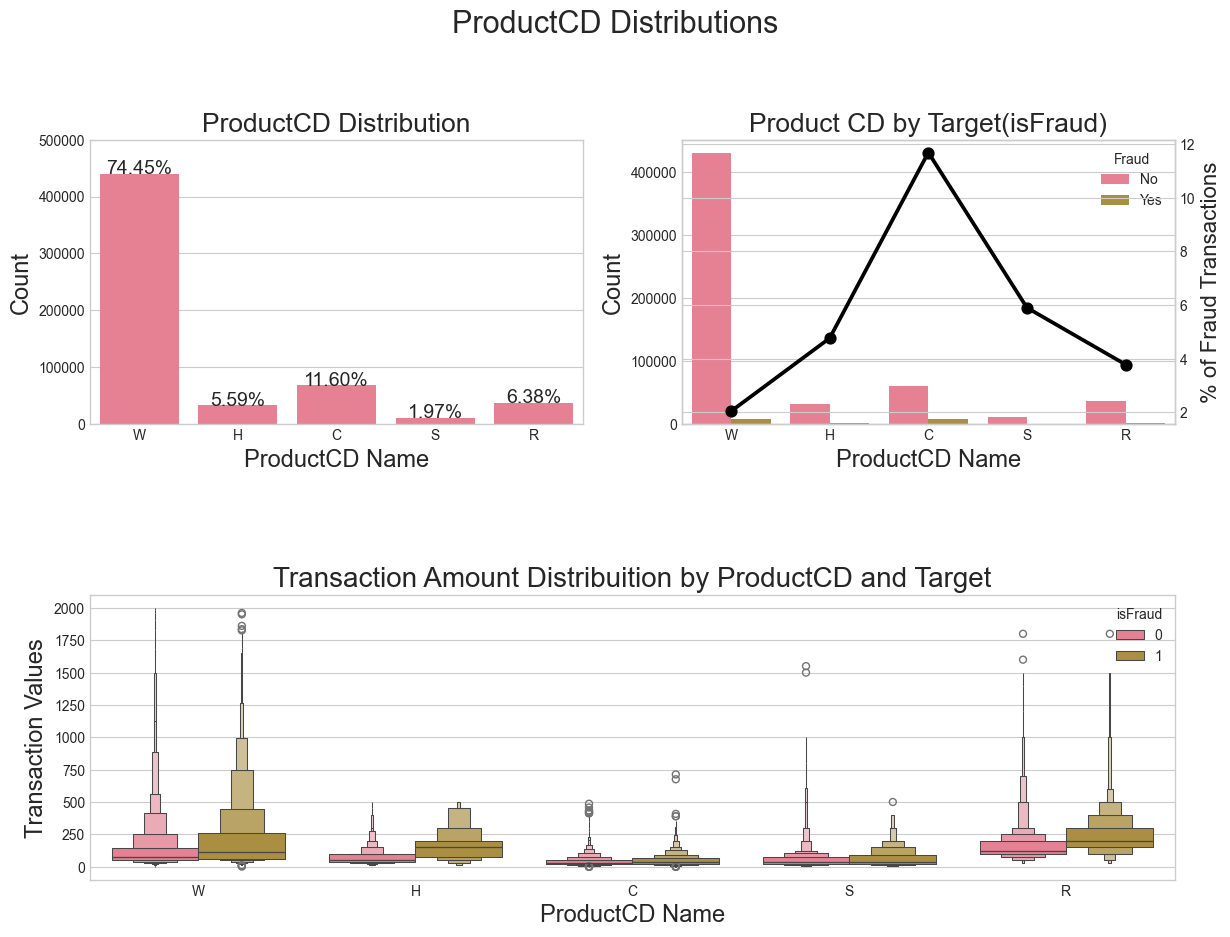

In [187]:
tmp = pd.crosstab(df_trans['ProductCD'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('ProductCD Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='ProductCD', data=df_trans)

g.set_title("ProductCD Distribution", fontsize=19)
g.set_xlabel("ProductCD Name", fontsize=17)
g.set_ylabel("Count", fontsize=17)
g.set_ylim(0,500000)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=14) 

plt.subplot(222)
g1 = sns.countplot(x='ProductCD', hue='isFraud', data=df_trans)
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='ProductCD', y='Fraud', data=tmp, color='black', order=['W', 'H',"C", "S", "R"], legend=False)
gt.set_ylabel("% of Fraud Transactions", fontsize=16)

g1.set_title("Product CD by Target(isFraud)", fontsize=19)
g1.set_xlabel("ProductCD Name", fontsize=17)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='ProductCD', y='TransactionAmt', hue='isFraud', 
              data=df_trans[df_trans['TransactionAmt'] <= 2000] )
g3.set_title("Transaction Amount Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("ProductCD Name", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)

plt.show()

In [188]:
resumetable(df_trans[['card1', 'card2', 'card3','card4', 'card5', 'card6']])

Dataset Shape: (590540, 6)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,card1,int16,0,13553,13926,2755,4663,9.97
1,card2,float16,8933,500,NaN,404.0,490.0,6.32
2,card3,float16,1565,114,150.0,150.0,150.0,0.68
3,card4,object,1577,4,discover,mastercard,visa,1.09
4,card5,float16,4259,119,142.0,102.0,166.0,2.66
5,card6,object,1571,4,credit,credit,debit,0.82


In [189]:
print("Card Features Quantiles: ")
print(df_trans[['card1', 'card2', 'card3', 'card5']].quantile([0.01, .025, .1, .25, .5, .75, .975, .99]))

Card Features Quantiles: 
         card1  card2  card3  card5
0.010   1338.0  100.0  144.0  102.0
0.025   1675.0  111.0  150.0  102.0
0.100   2803.0  111.0  150.0  126.0
0.250   6019.0  214.0  150.0  166.0
0.500   9678.0  361.0  150.0  226.0
0.750  14184.0  512.0  150.0  226.0
0.975  18018.0  583.0  185.0  226.0
0.990  18238.0  583.0  185.0  226.0


In [190]:
df_trans.loc[df_trans.card3.isin(df_trans.card3.value_counts()[df_trans.card3.value_counts() < 200].index), 'card3'] = "Others"
df_trans.loc[df_trans.card5.isin(df_trans.card5.value_counts()[df_trans.card5.value_counts() < 300].index), 'card5'] = "Others"

In [191]:
tmp = pd.crosstab(df_trans['card3'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

tmp2 = pd.crosstab(df_trans['card5'], df_trans['isFraud'], normalize='index') * 100
tmp2 = tmp2.reset_index()
tmp2.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,22))

plt.subplot(411)
g = sns.distplot(df_trans[df_trans['isFraud'] == 1]['card1'], label='Fraud')
g = sns.distplot(df_trans[df_trans['isFraud'] == 0]['card1'], label='NoFraud')
g.legend()
g.set_title("Card 1 Values Distribution by Target", fontsize=20)
g.set_xlabel("Card 1 Values", fontsize=18)
g.set_ylabel("Probability", fontsize=18)

plt.subplot(412)
g1 = sns.distplot(df_trans[df_trans['isFraud'] == 1]['card2'].dropna(), label='Fraud')
g1 = sns.distplot(df_trans[df_trans['isFraud'] == 0]['card2'].dropna(), label='NoFraud')
g1.legend()
g1.set_title("Card 2 Values Distribution by Target", fontsize=20)
g1.set_xlabel("Card 2 Values", fontsize=18)
g1.set_ylabel("Probability", fontsize=18)

plt.subplot(413)
g2 = sns.countplot(x='card3', data=df_trans, order=list(tmp.card3.values))
g22 = g2.twinx()
gg2 = sns.pointplot(x='card3', y='Fraud', data=tmp, 
                    color='black', order=list(tmp.card3.values))
gg2.set_ylabel("% of Fraud Transactions", fontsize=16)
g2.set_title("Card 3 Values Distribution and % of Transaction Frauds", fontsize=20)
g2.set_xlabel("Card 3 Values", fontsize=18)
g2.set_ylabel("Count", fontsize=18)
for p in g2.patches:
    height = p.get_height()
    g2.text(p.get_x()+p.get_width()/2.,
            height + 25,
            '{:1.2f}%'.format(height/total*100),
            ha="center") 

plt.subplot(414)
g3 = sns.countplot(x='card5', data=df_trans, order=list(tmp2.card5.values))
g3t = g3.twinx()
g3t = sns.pointplot(x='card5', y='Fraud', data=tmp2, 
                    color='black', order=list(tmp2.card5.values))
g3t.set_ylabel("% of Fraud Transactions", fontsize=16)
g3.set_title("Card 5 Values Distribution and % of Transaction Frauds", fontsize=20)
g3.set_xticklabels(g3.get_xticklabels(),rotation=90)
g3.set_xlabel("Card 5 Values", fontsize=18)
g3.set_ylabel("Count", fontsize=18)
for p in g3.patches:
    height = p.get_height()
    g3.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=11) 
    
plt.subplots_adjust(hspace = 0.6, top = 0.85)


plt.show()

<Figure size 1400x2200 with 6 Axes>

In [192]:
tmp = pd.crosstab(df_trans['card4'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 4 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card4', data=df_trans)
g.set_title("Card4 Distribution", fontsize=19)
g.set_ylim(0,420000)
g.set_xlabel("Card4 Category Names", fontsize=17)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14) 


plt.subplot(222)
g1 = sns.countplot(x='card4', hue='isFraud', data=df_trans)
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card4', y='Fraud', data=tmp, 
                   color='black', legend=False, 
                   order=['discover', 'mastercard', 'visa', 'american express'])
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card4 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card4 Category Names", fontsize=17)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card4', y='TransactionAmt', hue='isFraud', 
              data=df_trans[df_trans['TransactionAmt'] <= 2000] )
g3.set_title("Card 4 Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("Card4 Category Names", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)

plt.show()

<Figure size 1400x1000 with 4 Axes>

In [193]:
tmp = pd.crosstab(df_trans['card6'], df_trans['isFraud'], normalize='index') * 100
tmp = tmp.reset_index()
tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

plt.figure(figsize=(14,10))
plt.suptitle('Card 6 Distributions', fontsize=22)

plt.subplot(221)
g = sns.countplot(x='card6', data=df_trans, order=list(tmp.card6.values))
g.set_title("Card6 Distribution", fontsize=19)
g.set_ylim(0,480000)
g.set_xlabel("Card6 Category Names", fontsize=17)
g.set_ylabel("Count", fontsize=17)
for p in g.patches:
    height = p.get_height()
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center",fontsize=14) 

plt.subplot(222)
g1 = sns.countplot(x='card6', hue='isFraud', data=df_trans, order=list(tmp.card6.values))
plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
gt = g1.twinx()
gt = sns.pointplot(x='card6', y='Fraud', data=tmp, order=list(tmp.card6.values),
                   color='black', legend=False, )
gt.set_ylim(0,20)
gt.set_ylabel("% of Fraud Transactions", fontsize=16)
g1.set_title("Card6 by Target(isFraud)", fontsize=19)
g1.set_xlabel("Card6 Category Names", fontsize=17)
g1.set_ylabel("Count", fontsize=17)

plt.subplot(212)
g3 = sns.boxenplot(x='card6', y='TransactionAmt', hue='isFraud', order=list(tmp.card6.values),
              data=df_trans[df_trans['TransactionAmt'] <= 2000] )
g3.set_title("Card 6 Distribuition by ProductCD and Target", fontsize=20)
g3.set_xlabel("Card6 Category Names", fontsize=17)
g3.set_ylabel("Transaction Values", fontsize=17)

plt.subplots_adjust(hspace = 0.6, top = 0.85)

plt.show()

<Figure size 1400x1000 with 4 Axes>

In [195]:
for col in ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']:
    df_trans[col] = df_trans[col].fillna("Miss")
    
def ploting_dist_ratio(df, col, lim=2000):
    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    plt.figure(figsize=(20,5))
    plt.suptitle(f'{col} Distributions ', fontsize=22)

    plt.subplot(121)
    g = sns.countplot(x=col, data=df, order=list(tmp[col].values))
    g.set_title(f"{col} Distribution\nCound and %Fraud by each category", fontsize=18)
    g.set_ylim(0,400000)
    gt = g.twinx()
    gt = sns.pointplot(x=col, y='Fraud', data=tmp, order=list(tmp[col].values),
                       color='black', legend=False, )
    gt.set_ylim(0,20)
    gt.set_ylabel("% of Fraud Transactions", fontsize=16)
    g.set_xlabel(f"{col} Category Names", fontsize=16)
    g.set_ylabel("Count", fontsize=17)
    for p in gt.patches:
        height = p.get_height()
        gt.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total*100),
                ha="center",fontsize=14) 
        
    perc_amt = (df_trans.groupby(['isFraud',col])['TransactionAmt'].sum() / total_amt * 100).unstack('isFraud')
    perc_amt = perc_amt.reset_index()
    perc_amt.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    plt.subplot(122)
    g1 = sns.boxplot(x=col, y='TransactionAmt', hue='isFraud', 
                     data=df[df['TransactionAmt'] <= lim], order=list(tmp[col].values))
    g1t = g1.twinx()
    g1t = sns.pointplot(x=col, y='Fraud', data=perc_amt, order=list(tmp[col].values),
                       color='black', legend=False, )
    g1t.set_ylim(0,5)
    g1t.set_ylabel("%Fraud Total Amount", fontsize=16)
    g1.set_title(f"{col} by Transactions dist", fontsize=18)
    g1.set_xlabel(f"{col} Category Names", fontsize=16)
    g1.set_ylabel("Transaction Amount(U$)", fontsize=16)
        
    plt.subplots_adjust(hspace=.4, wspace = 0.35, top = 0.80)
    
    plt.show()

In [196]:
for col in ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']:
    ploting_dist_ratio(df_trans, col, lim=2500)

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

<Figure size 2000x500 with 4 Axes>

In [197]:
print("Card Features Quantiles: ")
print(df_trans[['addr1', 'addr2']].quantile([0.01, .025, .1, .25, .5, .75, .90,.975, .99]))

Card Features Quantiles: 
       addr1  addr2
0.010  123.0   87.0
0.025  123.0   87.0
0.100  177.0   87.0
0.250  204.0   87.0
0.500  299.0   87.0
0.750  330.0   87.0
0.900  441.0   87.0
0.975  498.0   87.0
0.990  512.0   87.0


In [198]:
df_trans.loc[df_trans.addr1.isin(df_trans.addr1.value_counts()[df_trans.addr1.value_counts() <= 5000 ].index), 'addr1'] = "Others"
df_trans.loc[df_trans.addr2.isin(df_trans.addr2.value_counts()[df_trans.addr2.value_counts() <= 50 ].index), 'addr2'] = "Others"

In [199]:
def ploting_cnt_amt(df, col, lim=2000):
    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
    
    plt.figure(figsize=(16,14))    
    plt.suptitle(f'{col} Distributions ', fontsize=24)
    
    plt.subplot(211)
    g = sns.countplot( x=col,  data=df, order=list(tmp[col].values))
    gt = g.twinx()
    gt = sns.pointplot(x=col, y='Fraud', data=tmp, order=list(tmp[col].values),
                       color='black', legend=False, )
    gt.set_ylim(0,tmp['Fraud'].max()*1.1)
    gt.set_ylabel("%Fraud Transactions", fontsize=16)
    g.set_title(f"Most Frequent {col} values and % Fraud Transactions", fontsize=20)
    g.set_xlabel(f"{col} Category Names", fontsize=16)
    g.set_ylabel("Count", fontsize=17)
    g.set_xticklabels(g.get_xticklabels(),rotation=45)
    sizes = []
    for p in g.patches:
        height = p.get_height()
        sizes.append(height)
        g.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total*100),
                ha="center",fontsize=12) 
        
    g.set_ylim(0,max(sizes)*1.15)
    
    #########################################################################
    perc_amt = (df.groupby(['isFraud',col])['TransactionAmt'].sum() \
                / df.groupby([col])['TransactionAmt'].sum() * 100).unstack('isFraud')
    perc_amt = perc_amt.reset_index()
    perc_amt.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)
    amt = df.groupby([col])['TransactionAmt'].sum().reset_index()
    perc_amt = perc_amt.fillna(0)
    plt.subplot(212)
    g1 = sns.barplot(x=col, y='TransactionAmt', 
                       data=amt, 
                       order=list(tmp[col].values))
    g1t = g1.twinx()
    g1t = sns.pointplot(x=col, y='Fraud', data=perc_amt, 
                        order=list(tmp[col].values),
                       color='black', legend=False, )
    g1t.set_ylim(0,perc_amt['Fraud'].max()*1.1)
    g1t.set_ylabel("%Fraud Total Amount", fontsize=16)
    g.set_xticklabels(g.get_xticklabels(),rotation=45)
    g1.set_title(f"{col} by Transactions Total + %of total and %Fraud Transactions", fontsize=20)
    g1.set_xlabel(f"{col} Category Names", fontsize=16)
    g1.set_ylabel("Transaction Total Amount(U$)", fontsize=16)
    g1.set_xticklabels(g.get_xticklabels(),rotation=45)    
    
    for p in g1.patches:
        height = p.get_height()
        g1.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total_amt*100),
                ha="center",fontsize=12) 
        
    plt.subplots_adjust(hspace=.4, top = 0.9)
    plt.show()
    
ploting_cnt_amt(df_trans, 'addr1')

<Figure size 1600x1400 with 4 Axes>

In [200]:
ploting_cnt_amt(df_trans, 'addr2')

<Figure size 1600x1400 with 4 Axes>

In [201]:
df_trans.loc[df_trans['P_emaildomain'].isin(['gmail.com', 'gmail']),'P_emaildomain'] = 'Google'

df_trans.loc[df_trans['P_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                         'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                         'yahoo.es']), 'P_emaildomain'] = 'Yahoo Mail'
df_trans.loc[df_trans['P_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx', 
                                         'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                         'outlook.es', 'live.com', 'live.fr',
                                         'hotmail.fr']), 'P_emaildomain'] = 'Microsoft'
df_trans.loc[df_trans.P_emaildomain.isin(df_trans.P_emaildomain\
                                         .value_counts()[df_trans.P_emaildomain.value_counts() <= 500 ]\
                                         .index), 'P_emaildomain'] = "Others"
df_trans.P_emaildomain.fillna("NoInf", inplace=True)

In [202]:
ploting_cnt_amt(df_trans, 'P_emaildomain')

<Figure size 1600x1400 with 4 Axes>

In [203]:
df_trans.loc[df_trans['R_emaildomain'].isin(['gmail.com', 'gmail']),'R_emaildomain'] = 'Google'

df_trans.loc[df_trans['R_emaildomain'].isin(['yahoo.com', 'yahoo.com.mx',  'yahoo.co.uk',
                                             'yahoo.co.jp', 'yahoo.de', 'yahoo.fr',
                                             'yahoo.es']), 'R_emaildomain'] = 'Yahoo Mail'
df_trans.loc[df_trans['R_emaildomain'].isin(['hotmail.com','outlook.com','msn.com', 'live.com.mx', 
                                             'hotmail.es','hotmail.co.uk', 'hotmail.de',
                                             'outlook.es', 'live.com', 'live.fr',
                                             'hotmail.fr']), 'R_emaildomain'] = 'Microsoft'
df_trans.loc[df_trans.R_emaildomain.isin(df_trans.R_emaildomain\
                                         .value_counts()[df_trans.R_emaildomain.value_counts() <= 300 ]\
                                         .index), 'R_emaildomain'] = "Others"
df_trans.R_emaildomain.fillna("NoInf", inplace=True)

In [204]:
ploting_cnt_amt(df_trans, 'R_emaildomain')


<Figure size 1600x1400 with 4 Axes>

In [205]:
resumetable(df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']])

Dataset Shape: (590540, 14)


,Name,dtypes,Missing,Uniques,First Value,Second Value,Third Value,Entropy
0,C1,float16,0,1495,1.0,1.0,1.0,2.72
1,C2,float16,0,1167,1.0,1.0,1.0,2.75
2,C3,float16,0,27,0.0,0.0,0.0,0.04
3,C4,float16,0,1223,0.0,0.0,0.0,1.12
4,C5,float16,0,319,0.0,0.0,0.0,2.06
5,C6,float16,0,1291,1.0,1.0,1.0,2.52
6,C7,float16,0,1069,0.0,0.0,0.0,0.71
7,C8,float16,0,1130,0.0,0.0,0.0,1.25
8,C9,float16,0,205,1.0,0.0,1.0,2.62
9,C10,float16,0,1122,0.0,0.0,0.0,1.23


In [206]:
df_trans[['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8',
                      'C9', 'C10', 'C11', 'C12', 'C13', 'C14']].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0,590540.0
mean,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
50%,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,1.0
75%,3.0,3.0,0.0,0.0,1.0,2.0,0.0,0.0,2.0,0.0,2.0,0.0,12.0,2.0
max,4684.0,5692.0,26.0,2252.0,349.0,2252.0,2256.0,3332.0,210.0,3256.0,3188.0,3188.0,2918.0,1429.0


In [207]:
df_trans.loc[df_trans.C1.isin(df_trans.C1\
                              .value_counts()[df_trans.C1.value_counts() <= 400 ]\
                              .index), 'C1'] = "Others"

In [208]:
ploting_cnt_amt(df_trans, 'C1')

<Figure size 1600x1400 with 4 Axes>

In [209]:
df_trans.loc[df_trans.C2.isin(df_trans.C2\
                              .value_counts()[df_trans.C2.value_counts() <= 350 ]\
                              .index), 'C2'] = "Others"

In [210]:
ploting_cnt_amt(df_trans, 'C2')


<Figure size 1600x1400 with 4 Axes>

In [211]:
import datetime

START_DATE = '2017-12-01'
startdate = datetime.datetime.strptime(START_DATE, "%Y-%m-%d")
df_trans["Date"] = df_trans['TransactionDT'].apply(lambda x: (startdate + datetime.timedelta(seconds=x)))

df_trans['_Weekdays'] = df_trans['Date'].dt.dayofweek
df_trans['_Hours'] = df_trans['Date'].dt.hour
df_trans['_Days'] = df_trans['Date'].dt.day

In [212]:
ploting_cnt_amt(df_trans, '_Days')

<Figure size 1600x1400 with 4 Axes>

In [213]:
ploting_cnt_amt(df_trans, '_Weekdays')


<Figure size 1600x1400 with 4 Axes>

In [214]:
ploting_cnt_amt(df_trans, '_Hours')


<Figure size 1600x1400 with 4 Axes>

In [215]:
# Calling the function to transform the date column in datetime pandas object

#seting some static color options
color_op = ['#5527A0', '#BB93D7', '#834CF7', '#6C941E', '#93EAEA', '#7425FF', '#F2098A', '#7E87AC', 
            '#EBE36F', '#7FD394', '#49C35D', '#3058EE', '#44FDCF', '#A38F85', '#C4CEE0', '#B63A05', 
            '#4856BF', '#F0DB1B', '#9FDBD9', '#B123AC']


dates_temp = df_trans.groupby(df_trans.Date.dt.date)['TransactionAmt'].count().reset_index()
# renaming the columns to apropriate names

# creating the first trace with the necessary parameters
trace = go.Scatter(x=dates_temp['Date'], y=dates_temp.TransactionAmt,
                    opacity = 0.8, line = dict(color = color_op[7]), name= 'Total Transactions')

# Below we will get the total amount sold
dates_temp_sum = df_trans.groupby(df_trans.Date.dt.date)['TransactionAmt'].sum().reset_index()

# using the new dates_temp_sum we will create the second trace
trace1 = go.Scatter(x=dates_temp_sum.Date, line = dict(color = color_op[1]), name="Total Amount",
                        y=dates_temp_sum['TransactionAmt'], opacity = 0.8, yaxis='y2')

#creating the layout the will allow us to give an title and 
# give us some interesting options to handle with the outputs of graphs
layout = dict(
    title= "Total Transactions and Fraud Informations by Date",
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label='1m', step='month', stepmode='backward'),
                dict(count=3, label='3m', step='month', stepmode='backward'),
                dict(count=6, label='6m', step='month', stepmode='backward'),
                dict(step='all')
            ])
        ),
        rangeslider=dict(visible = True),
        type='date' ),
    yaxis=dict(title='Total Transactions'),
    yaxis2=dict(overlaying='y',
                anchor='x', side='right',
                zeroline=False, showgrid=False,
                title='Total Transaction Amount')
)

# creating figure with the both traces and layout
fig = dict(data= [trace, trace1,], layout=layout)

#rendering the graphs
iplot(fig) #it's an equivalent to plt.show()

In [216]:
# Calling the function to transform the date column in datetime pandas object

#seting some static color options
color_op = ['#5527A0', '#BB93D7', '#834CF7', '#6C941E', '#93EAEA', '#7425FF', '#F2098A', '#7E87AC', 
            '#EBE36F', '#7FD394', '#49C35D', '#3058EE', '#44FDCF', '#A38F85', '#C4CEE0', '#B63A05', 
            '#4856BF', '#F0DB1B', '#9FDBD9', '#B123AC']

tmp_amt = df_trans.groupby([df_trans.Date.dt.date, 'isFraud'])['TransactionAmt'].sum().reset_index()
tmp_trans = df_trans.groupby([df_trans.Date.dt.date, 'isFraud'])['TransactionAmt'].count().reset_index()

tmp_trans_fraud = tmp_trans[tmp_trans['isFraud'] == 1]
tmp_amt_fraud = tmp_amt[tmp_amt['isFraud'] == 1]

dates_temp = df_trans.groupby(df_trans.Date.dt.date)['TransactionAmt'].count().reset_index()
# renaming the columns to apropriate names

# creating the first trace with the necessary parameters
trace = go.Scatter(x=tmp_trans_fraud['Date'], y=tmp_trans_fraud.TransactionAmt,
                    opacity = 0.8, line = dict(color = color_op[1]), name= 'Fraud Transactions')

# using the new dates_temp_sum we will create the second trace
trace1 = go.Scatter(x=tmp_amt_fraud.Date, line = dict(color = color_op[7]), name="Fraud Amount",
                    y=tmp_amt_fraud['TransactionAmt'], opacity = 0.8, yaxis='y2')

#creating the layout the will allow us to give an title and 
# give us some interesting options to handle with the outputs of graphs
layout = dict(
    title= "FRAUD TRANSACTIONS - Total Transactions and Fraud Informations by Date",
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label='1m', step='month', stepmode='backward'),
                dict(count=3, label='3m', step='month', stepmode='backward'),
                dict(count=6, label='6m', step='month', stepmode='backward'),
                dict(step='all')
            ])
        ),
        rangeslider=dict(visible = True),
        type='date' ),
    yaxis=dict(title='Total Transactions'),
    yaxis2=dict(overlaying='y',
                anchor='x', side='right',
                zeroline=False, showgrid=False,
                title='Total Transaction Amount')
)

# creating figure with the both traces and layout
fig = dict(data= [trace, trace1], layout=layout)

#rendering the graphs
iplot(fig) #it's an equivalent to plt.show()

In [217]:
df_id[['id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18',
       'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25',
       'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32',
       'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']].describe(include='all')

,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38
count,144233,127320.0,80044.0,140985,129340,139369.0,4.511300e+04,139318.0,139261.0,5159.00,5169.000000,5169,4747.000000,5132.0000,5163.00000,5169,140978,140978,77565,140282,77586.0,73289,77805,140985,140985,140985,140985
unique,2,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,2,2,2,75,130,NaN,260,4,2,2,2,2
top,NotFound,NaN,NaN,Found,Found,NaN,NaN,NaN,NaN,NaN,NaN,IP_PROXY:TRANSPARENT,NaN,NaN,NaN,Found,Found,Found,Windows 10,chrome 63.0,NaN,1920x1080,match_status:2,T,F,T,F
freq,123025,NaN,NaN,67728,66324,NaN,NaN,NaN,NaN,NaN,NaN,3489,NaN,NaN,NaN,5155,76232,74926,21155,22000,NaN,16874,60011,77814,134066,110452,73922
mean,NaN,NaN,NaN,NaN,NaN,NaN,inf,NaN,NaN,inf,inf,NaN,12.789062,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.0,0.0,NaN,NaN,0.0,1.561523e+00,0.0,0.0,198.75,6.898438,NaN,2.371094,97.4375,32.09375,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,10.0,-660.0,NaN,NaN,100.0,1.000000e+01,100.0,100.0,100.00,10.000000,NaN,11.000000,100.0000,100.00000,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,49.0,-360.0,NaN,NaN,166.0,1.300000e+01,266.0,256.0,252.00,14.000000,NaN,11.000000,321.0000,119.00000,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,52.0,-300.0,NaN,NaN,166.0,1.500000e+01,341.0,472.0,252.00,14.000000,NaN,11.000000,321.0000,149.00000,NaN,NaN,NaN,NaN,NaN,24.0,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,52.0,-300.0,NaN,NaN,225.0,1.500000e+01,427.0,533.0,486.50,14.000000,NaN,15.000000,371.0000,169.00000,NaN,NaN,NaN,NaN,NaN,32.0,NaN,NaN,NaN,NaN,NaN,NaN


In [218]:
df_train = df_trans.merge(df_id, how='left', left_index=True, right_index=True)

In [219]:
def cat_feat_ploting(df, col):
    tmp = pd.crosstab(df[col], df['isFraud'], normalize='index') * 100
    tmp = tmp.reset_index()
    tmp.rename(columns={0:'NoFraud', 1:'Fraud'}, inplace=True)

    plt.figure(figsize=(14,10))
    plt.suptitle(f'{col} Distributions', fontsize=22)

    plt.subplot(221)
    g = sns.countplot(x=col, data=df, order=tmp[col].values)

    g.set_title(f"{col} Distribution", fontsize=19)
    g.set_xlabel(f"{col} Name", fontsize=17)
    g.set_ylabel("Count", fontsize=17)
    for p in g.patches:
        height = p.get_height()
        g.text(p.get_x()+p.get_width()/2.,
                height + 3,
                '{:1.2f}%'.format(height/total*100),
                ha="center", fontsize=14) 

    plt.subplot(222)
    g1 = sns.countplot(x=col, hue='isFraud', data=df, order=tmp[col].values)
    plt.legend(title='Fraud', loc='best', labels=['No', 'Yes'])
    gt = g1.twinx()
    gt = sns.pointplot(x=col, y='Fraud', data=tmp, color='black', order=tmp[col].values, legend=False)
    gt.set_ylabel("% of Fraud Transactions", fontsize=16)

    g1.set_title(f"{col} by Target(isFraud)", fontsize=19)
    g1.set_xlabel(f"{col} Name", fontsize=17)
    g1.set_ylabel("Count", fontsize=17)

    plt.subplot(212)
    g3 = sns.boxenplot(x=col, y='TransactionAmt', hue='isFraud', 
                       data=df[df['TransactionAmt'] <= 2000], order=tmp[col].values )
    g3.set_title("Transaction Amount Distribuition by ProductCD and Target", fontsize=20)
    g3.set_xlabel("ProductCD Name", fontsize=17)
    g3.set_ylabel("Transaction Values", fontsize=17)

    plt.subplots_adjust(hspace = 0.4, top = 0.85)

    plt.show()

In [220]:
for col in ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29']:
    df_train[col] = df_train[col].fillna('NaN')
    cat_feat_ploting(df_train, col)

<Figure size 1400x1000 with 4 Axes>

<Figure size 1400x1000 with 4 Axes>

<Figure size 1400x1000 with 4 Axes>

<Figure size 1400x1000 with 4 Axes>

<Figure size 1400x1000 with 4 Axes>

<Figure size 1400x1000 with 4 Axes>

<Figure size 1400x1000 with 4 Axes>

In [221]:
df_train.loc[df_train['id_30'].str.contains('Windows', na=False), 'id_30'] = 'Windows'
df_train.loc[df_train['id_30'].str.contains('iOS', na=False), 'id_30'] = 'iOS'
df_train.loc[df_train['id_30'].str.contains('Mac OS', na=False), 'id_30'] = 'Mac'
df_train.loc[df_train['id_30'].str.contains('Android', na=False), 'id_30'] = 'Android'
df_train['id_30'].fillna("NAN", inplace=True)

In [222]:
ploting_cnt_amt(df_train, 'id_30')

<Figure size 1600x1400 with 4 Axes>

In [223]:
df_train.loc[df_train['id_31'].str.contains('chrome', na=False), 'id_31'] = 'Chrome'
df_train.loc[df_train['id_31'].str.contains('firefox', na=False), 'id_31'] = 'Firefox'
df_train.loc[df_train['id_31'].str.contains('safari', na=False), 'id_31'] = 'Safari'
df_train.loc[df_train['id_31'].str.contains('edge', na=False), 'id_31'] = 'Edge'
df_train.loc[df_train['id_31'].str.contains('ie', na=False), 'id_31'] = 'IE'
df_train.loc[df_train['id_31'].str.contains('samsung', na=False), 'id_31'] = 'Samsung'
df_train.loc[df_train['id_31'].str.contains('opera', na=False), 'id_31'] = 'Opera'
df_train['id_31'].fillna("NAN", inplace=True)
df_train.loc[df_train.id_31.isin(df_train.id_31.value_counts()[df_train.id_31.value_counts() < 200].index), 'id_31'] = "Others"

In [224]:
ploting_cnt_amt(df_train, 'id_31')

<Figure size 1600x1400 with 4 Axes>

In [4]:
COL = 'TransactionDT'
h('<h2 id="c_' + COL + '">' + COL + '</h2>' + '<a style="font-size:11px" href="#home">(Jump to top)</a>')

te['TransactionDT'].plot(kind='hist', figsize=(15, 5), label='test', bins=200, title='Train and Test TransactionDT distribution')
tr['TransactionDT'].plot(kind='hist', label='train', bins=200)
plt.legend()
plt.show()
tr['TransactionDT'].plot(kind='hist', figsize=(15, 5), label='train', bins=200, title='Train and Test public/private TransactionDT distribution')
n_public = int(te.shape[0] * 0.2)
te.loc[:n_public, 'TransactionDT'].plot(kind='hist', label='test public', bins=40)
te.loc[n_public:, 'TransactionDT'].plot(kind='hist', label='test private', bins=160)
plt.legend()
plt.show()
corr1(COL)

<Figure size 1500x500 with 1 Axes>

<Figure size 1500x500 with 1 Axes>

,Column,Correlation with TransactionDT
0,TransactionDT,1.000000
1,TransactionID,0.998280
2,V330,0.258603
3,V326,0.257295
4,V329,0.252599
5,V327,0.248494
375,V145,-0.252731
376,V160,-0.265566
377,V159,-0.279138
378,V151,-0.280576


In [5]:
COL = 'isFraud'
h('<h2 id="c_' + COL + '">' + COL + '</h2>' + '<a style="font-size:11px" href="#home">(Jump to top)</a>')
h('This is target column.')
trx = tr['isFraud'].value_counts().reset_index().rename({'index':'Value','isFraud':'Count'}, axis=1)
trx['Share'] = np.round(trx['Count'] / trx['Count'].sum(), 6)
display(trx)
corr1(COL)

,Count,count,Share
0,0,569877,0.0
1,1,20663,1.0


,Column,Correlation with isFraud
0,isFraud,1.000000
1,V257,0.383060
2,V246,0.366878
3,V244,0.364129
4,V242,0.360590
5,V201,0.328005
375,V90,-0.110168
376,V49,-0.110920
377,V48,-0.115786
378,D7,-0.127199


In [6]:
for col in list(tr.columns.values[:COLS_TO_SHOW]):
    proc(col)

<Figure size 1500x300 with 1 Axes>

<Figure size 1500x300 with 2 Axes>

,TransactionID,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,5.905400e+05,2.066300e+04,5.698770e+05,5.066910e+05,1.013390e+05,4.053530e+05
1,mean,3.282270e+06,3.294952e+06,3.281810e+06,3.916894e+06,3.714218e+06,3.967563e+06
2,std,1.704744e+05,1.620403e+05,1.707548e+05,1.462692e+05,2.925419e+04,1.170155e+05
3,min,2.987000e+06,2.987203e+06,2.987000e+06,3.663549e+06,3.663549e+06,3.764887e+06
4,25%,3.134635e+06,3.167366e+06,3.133317e+06,3.790222e+06,3.688884e+06,3.866225e+06
5,50%,3.282270e+06,3.291934e+06,3.281808e+06,3.916894e+06,3.714218e+06,3.967563e+06
6,75%,3.429904e+06,3.428646e+06,3.429974e+06,4.043566e+06,3.739552e+06,4.068901e+06
7,max,3.577539e+06,3.577526e+06,3.577539e+06,4.170239e+06,3.764887e+06,4.170239e+06
8,unique values,5.905400e+05,2.066300e+04,5.698770e+05,5.066910e+05,1.013390e+05,4.053530e+05
9,NaNs,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


,Column,Correlation with TransactionID
0,TransactionID,1.000000
1,TransactionDT,0.998280
2,V326,0.251746
3,V330,0.250831
4,V329,0.244867
5,V327,0.242576
375,V145,-0.273548
376,V160,-0.282572
377,V159,-0.302742
378,V151,-0.303988


<Figure size 1500x300 with 1 Axes>

...

<Figure size 1500x300 with 2 Axes>

,V95,Train,Train fraud,Train Not fraud,Test,Test public,Test private
0,count,590226.000000,20646.000000,569580.000000,506691.000000,101339.000000,405353.000000
1,mean,1.038019,0.582873,1.054517,0.231695,0.270952,0.221881
2,std,21.034304,1.239608,21.410652,0.859311,1.210804,0.745671
3,min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,75%,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
7,max,880.000000,13.000000,880.000000,60.000000,60.000000,27.000000
8,unique values,882.000000,15.000000,882.000000,61.000000,61.000000,28.000000
9,NaNs,314.000000,17.000000,297.000000,0.000000,0.000000,0.000000


,V95,Count in train (desc),Mean target,Sum target,Count in test
0,0.0,510542,0.028568,14585,436511.0
1,1.0,52008,0.063740,3315,46915.0
2,2.0,14804,0.089976,1332,13276.0
3,3.0,5758,0.112365,647,4986.0
4,4.0,2646,0.125472,332,2330.0
5,5.0,1281,0.135831,174,1116.0
6,6.0,684,0.141813,97,578.0
7,7.0,411,0.163017,67,322.0
8,-999.0,314,0.054140,17,NaN
9,8.0,239,0.184100,44,196.0


,V95,Count in train,Mean target,Sum target (desc),Count in test
0,0.0,510542,0.028568,14585,436511
1,1.0,52008,0.063740,3315,46915
2,2.0,14804,0.089976,1332,13276
3,3.0,5758,0.112365,647,4986
4,4.0,2646,0.125472,332,2330
5,5.0,1281,0.135831,174,1116
6,6.0,684,0.141813,97,578
7,7.0,411,0.163017,67,322
8,8.0,239,0.184100,44,196
9,9.0,167,0.191617,32,119


,Column,Correlation with V95
0,V95,1.000000
1,V322,0.999949
2,V101,0.999594
3,V279,0.998710
4,V293,0.998475
5,V132,0.995258
375,V155,-0.132920
376,V148,-0.137331
377,V154,-0.144542
378,V153,-0.147642


## EDA for Columns V and ID

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np,gc
import pandas as pd
pd.set_option('display.max_columns', 500)


import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Assignment.ipynb
oof_xgb_95.csv
TabNetesing.ipynb
test_identity.csv
test_transaction.csv
train_identity.csv
train_transaction.csv


In [8]:
cols_t = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']
cols_v = ['V'+str(x) for x in range(1,340)]; types_v = {}
for c in cols_v: types_v[c] = 'float32'
train = pd.read_csv(
    r'datasets/ieee dataset/train_transaction.csv',
    usecols=cols_t + ['isFraud'] + cols_v,
    dtype=types_v
)

## NAN search

In [9]:
nans_df = train.isna()
nans_groups={}
i_cols = ['V'+str(i) for i in range(1,340)]
for col in train.columns:
    cur_group = nans_df[col].sum()
    try:
        nans_groups[cur_group].append(col)
    except:
        nans_groups[cur_group]=[col]
del nans_df; x=gc.collect()

for k,v in nans_groups.items():
    print('####### NAN count =',k)
    print(v)

####### NAN count = 0
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14']
####### NAN count = 8933
['card2']
####### NAN count = 1565
['card3']
####### NAN count = 1577
['card4']
####### NAN count = 4259
['card5']
####### NAN count = 1571
['card6']
####### NAN count = 65706
['addr1', 'addr2']
####### NAN count = 352271
['dist1']
####### NAN count = 552913
['dist2']
####### NAN count = 94456
['P_emaildomain']
####### NAN count = 453249
['R_emaildomain']
####### NAN count = 1269
['D1', 'V281', 'V282', 'V283', 'V288', 'V289', 'V296', 'V300', 'V301', 'V313', 'V314', 'V315']
####### NAN count = 280797
['D2']
####### NAN count = 262878
['D3']
####### NAN count = 168922
['D4']
####### NAN count = 309841
['D5']
####### NAN count = 517353
['D6']
####### NAN count = 551623
['D7']
####### NAN count = 515614
['D8', 'D9']
####### NAN count = 76022
['D10']
####### NAN count = 27

## V1-V11, D11

In [10]:
Vc = ['dayr','isFraud','TransactionAmt','card1','addr1','D1n','D11n']
Vs = nans_groups[279287]
Vtitle = 'V1 - V11, D11'

In [11]:
def make_plots(Vs):
    col = 4
    row = len(Vs)//4+1
    plt.figure(figsize=(20,row*5))
    idx = train[~train[Vs[0]].isna()].index
    for i,v in enumerate(Vs):
        plt.subplot(row,col,i+1)
        n = train[v].nunique()
        x = np.sum(train.loc[idx,v]!=train.loc[idx,v].astype(int))
        y = np.round(100*np.sum(train[v].isna())/len(train),2)
        t = 'int'
        if x!=0: t = 'float'
        plt.title(v+' has '+str(n)+' '+t+' and '+str(y)+'% nan')
        plt.yticks([])
        h = plt.hist(train.loc[idx,v],bins=100)
        if len(h[0])>1: plt.ylim((0,np.sort(h[0])[-2]))
    plt.show()
make_plots(Vs)

<Figure size 2000x2000 with 12 Axes>

In [12]:
def make_corr(Vs,Vtitle=''):
    cols = ['TransactionDT'] + Vs
    plt.figure(figsize=(15,15))
    sns.heatmap(train[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
    if Vtitle!='': plt.title(Vtitle,fontsize=14)
    else: plt.title(Vs[0]+' - '+Vs[-1],fontsize=14)
    plt.show()
make_corr(Vs,Vtitle)

<Figure size 1500x1500 with 2 Axes>

In [13]:
grps = [[1],[2,3],[4,5],[6,7],[8,9],[10,11]]
def reduce_group(grps,c='V'):
    use = []
    for g in grps:
        mx = 0; vx = g[0]
        for gg in g:
            n = train[c+str(gg)].nunique()
            if n>mx:
                mx = n
                vx = gg
            #print(str(gg)+'-'+str(n),', ',end='')
        use.append(vx)
        #print()
    print('Use these',use)
reduce_group(grps)

Use these [1, 3, 4, 6, 8, 11]


## V12 - V34

In [14]:
Vs = nans_groups[76073]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x3000 with 23 Axes>

<Figure size 1500x1500 with 2 Axes>

In [15]:
grps = [[12,13],[14],[15,16,17,18,21,22,31,32,33,34],[19,20],[23,24],[25,26],[27,28],[29,30]]
reduce_group(grps)

Use these [13, 14, 17, 20, 23, 26, 27, 30]


## V35 - V52

In [16]:
Vs = nans_groups[168969]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 18 Axes>

<Figure size 1500x1500 with 2 Axes>

In [17]:
grps = [[35,36],[37,38],[39,40,42,43,50,51,52],[41],[44,45],[46,47],[48,49]]
reduce_group(grps)

Use these [36, 37, 40, 41, 44, 47, 48]


## V53 - V74

In [18]:
Vs = nans_groups[77096]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x3000 with 22 Axes>

<Figure size 1500x1500 with 2 Axes>

In [19]:
grps = [[53,54],[55,56],[57,58,59,60,63,64,71,72,73,74],[61,62],[65],[66,67],[68],[69,70]]
reduce_group(grps)

Use these [54, 56, 59, 62, 65, 67, 68, 70]


## V75 - V94

In [20]:
Vs = nans_groups[89164]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x3000 with 20 Axes>

<Figure size 1500x1500 with 2 Axes>

In [21]:
grps = [[75,76],[77,78],[79,80,81,84,85,92,93,94],[82,83],[86,87],[88],[89],[90,91]]
reduce_group(grps)

Use these [76, 78, 80, 82, 86, 88, 89, 91]


## V95 - V137

In [22]:
Vs = nans_groups[314]
make_corr(Vs)

<Figure size 1500x1500 with 2 Axes>

In [23]:
Vs = ['V'+str(x) for x in range(95,107)]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2000 with 12 Axes>

<Figure size 1500x1500 with 2 Axes>

In [24]:
grps = [[95,96,97,101,102,103,105,106],[98],[99,100],[104]]
reduce_group(grps)

Use these [96, 98, 99, 104]


In [25]:
Vs = ['V'+str(x) for x in range(107,124)]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 17 Axes>

<Figure size 1500x1500 with 2 Axes>

In [26]:
grps = [[107],[108,109,110,114],[111,112,113],[115,116],[117,118,119],[120,122],[121],[123]]
reduce_group(grps)

Use these [107, 108, 111, 115, 117, 120, 121, 123]


In [27]:
Vs = ['V'+str(x) for x in range(124,138)]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2000 with 14 Axes>

<Figure size 1500x1500 with 2 Axes>

In [28]:
grps = [[124,125],[126,127,128,132,133,134],[129],[130,131],[135,136,137]]
reduce_group(grps)

Use these [124, 127, 129, 130, 136]


## V138 ~ V163

In [29]:
Vs = nans_groups[508595]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 18 Axes>

<Figure size 1500x1500 with 2 Axes>

In [30]:
grps = [[138],[139,140],[141,142],[146,147],[148,149,153,154,156,157,158],[161,162,163]]
reduce_group(grps)

Use these [138, 139, 142, 147, 156, 162]


## V143 ~ V166

In [31]:
Vs = nans_groups[508589]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x1500 with 11 Axes>

<Figure size 1500x1500 with 2 Axes>

In [32]:
grps = [[143,164,165],[144,145,150,151,152,159,160],[166]]
reduce_group(grps)

Use these [165, 160, 166]


## V167 ~ V216

In [33]:
Vs = [x for x in nans_groups[450909]]
make_corr(Vs)

<Figure size 1500x1500 with 2 Axes>

In [34]:
Vs = [x for x in nans_groups[450909] if int(x[1:])<186]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x1500 with 11 Axes>

<Figure size 1500x1500 with 2 Axes>

In [35]:
grps = [[167,168,177,178,179],[172,176],[173],[181,182,183]]
reduce_group(grps)

Use these [178, 176, 173, 182]


In [36]:
Vs = [x for x in nans_groups[450909] if (int(x[1:])>183)]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x3000 with 20 Axes>

<Figure size 1500x1500 with 2 Axes>

In [37]:
grps = [[186,187,190,191,192,193,196,199],[202,203,204,211,212,213],[205,206],[207],[214,215,216]]
reduce_group(grps)

Use these [187, 203, 205, 207, 215]


## V169 ~ V210

In [38]:
Vs = nans_groups[450721]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 19 Axes>

<Figure size 1500x1500 with 2 Axes>

In [39]:
grps = [[169],[170,171,200,201],[174,175],[180],[184,185],[188,189],[194,195,197,198],[208,210],[209]]
reduce_group(grps)

Use these [169, 171, 175, 180, 185, 188, 198, 210, 209]


## V217 ~ V278

In [40]:
Vs = [x for x in nans_groups[460110]]
make_corr(Vs)

<Figure size 1500x1500 with 2 Axes>

In [41]:
Vs = [x for x in nans_groups[460110] if int(x[1:])<240]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 16 Axes>

<Figure size 1500x1500 with 2 Axes>

In [42]:
grps = [[217,218,219,231,232,233,236,237],[223],[224,225],[226],[228],[229,230],[235]]
reduce_group(grps)

Use these [218, 223, 224, 226, 228, 229, 235]


In [43]:
Vs = [x for x in nans_groups[460110] if (int(x[1:])>237)&(int(x[1:])<263)]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 17 Axes>

<Figure size 1500x1500 with 2 Axes>

In [44]:
grps = [[240,241],[242,243,244,258],[246,257],[247,248,249,253,254],[252],[260],[261,262]]
reduce_group(grps)

Use these [240, 258, 257, 253, 252, 260, 261]


In [45]:
Vs = [x for x in nans_groups[460110] if (int(x[1:])>262)]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2000 with 13 Axes>

<Figure size 1500x1500 with 2 Axes>

In [46]:
grps = [[263,265,264],[266,269],[267,268],[273,274,275],[276,277,278]]
reduce_group(grps)

Use these [264, 266, 267, 274, 277]


## V220 ~ V272

In [47]:
Vs = nans_groups[449124]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 16 Axes>

<Figure size 1500x1500 with 2 Axes>

In [48]:
grps = [[220],[221,222,227,245,255,256,259],[234],[238,239],[250,251],[270,271,272]]
reduce_group(grps)

Use these [220, 221, 234, 238, 250, 271]


## V279 ~ V321

In [49]:
Vs = [x for x in nans_groups[12]]
make_corr(Vs)

<Figure size 1500x1500 with 2 Axes>

In [50]:
Vs = [x for x in nans_groups[12] if int(x[1:])<302]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2000 with 15 Axes>

<Figure size 1500x1500 with 2 Axes>

In [51]:
grps = [[279,280,293,294,295,298,299],[284],[285,287],[286],[290,291,292],[297]]
reduce_group(grps)

Use these [294, 284, 285, 286, 291, 297]


In [52]:
Vs = [x for x in nans_groups[12] if int(x[1:])>299]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 17 Axes>

<Figure size 1500x1500 with 2 Axes>

In [53]:
grps = [[302,303,304],[305],[306,307,308,316,317,318],[309,311],[310,312],[319,320,321]]
reduce_group(grps)

Use these [303, 305, 307, 309, 310, 320]


## V281 ~ V315, D1

In [54]:
Vs = nans_groups[1269]
make_plots(Vs)
Vtitle = 'V281 - V315, D1'
make_corr(Vs,Vtitle)

<Figure size 2000x2000 with 12 Axes>

<Figure size 1500x1500 with 2 Axes>

In [55]:
grps = [[281],[282,283],[288,289],[296],[300,301],[313,314,315]]
reduce_group(grps)

Use these [281, 283, 289, 296, 301, 314]


## V322 - V339

In [56]:
Vs = nans_groups[508189]
make_plots(Vs)
make_corr(Vs)

<Figure size 2000x2500 with 18 Axes>

<Figure size 1500x1500 with 2 Axes>

In [57]:
grps = [[322,323,324,326,327,328,329,330,331,332,333],[325],[334,335,336],[337,338,339]]
reduce_group(grps)

Use these [332, 325, 335, 338]


## V Reduced

In [58]:
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]
v += [96, 98, 99, 104]
v += [107, 108, 111, 115, 117, 120, 121, 123]
v += [124, 127, 129, 130, 136]
v += [138, 139, 142, 147, 156, 162]
v += [165, 160, 166]
v += [178, 176, 173, 182]
v += [187, 203, 205, 207, 215]
v += [169, 171, 175, 180, 185, 188, 198, 210, 209]
v += [218, 223, 224, 226, 228, 229, 235]
v += [240, 258, 257, 253, 252, 260, 261]
v += [264, 266, 267, 274, 277]
v += [220, 221, 234, 238, 250, 271]
v += [294, 284, 285, 286, 291, 297]
v += [303, 305, 307, 309, 310, 320]
v += [281, 283, 289, 296, 301, 314]
v += [332, 325, 335, 338]

In [59]:
print('Reduced set has',len(v),'columns')

Reduced set has 128 columns


In [60]:
cols = ['TransactionDT'] + ['V'+str(x) for x in v]
train2 = train[cols].sample(frac=0.2)
plt.figure(figsize=(15,15))
sns.heatmap(train2[cols].corr(), cmap='RdBu_r', annot=False, center=0.0)
plt.title('V1-V339 REDUCED',fontsize=14)
plt.show()

<Figure size 1500x1500 with 2 Axes>

## V All

In [61]:
cols = ['TransactionDT'] + ['V'+str(x) for x in range(1,340)]
train2 = train[cols].sample(frac=0.2)
plt.figure(figsize=(15,15))
sns.heatmap(train2[cols].corr(), cmap='RdBu_r', annot=False, center=0.0)
plt.title('V1-V339 ALL',fontsize=14)
plt.show()

<Figure size 1500x1500 with 2 Axes>

## C Columns

In [62]:
def make_plots2(Vs):
    col = 4
    row = len(Vs)//4+1
    plt.figure(figsize=(20,row*5))
    for i,v in enumerate(Vs):
        plt.subplot(row,col,i+1)
        idx = train[~train[v].isna()].index
        n = train[v].nunique()
        x = np.sum(train.loc[idx,v]!=train.loc[idx,v].astype(int))
        y = np.round(100*np.sum(train[v].isna())/len(train),2)
        t = 'int'
        if x!=0: t = 'float'
        plt.title(v+' has '+str(n)+' '+t+' and '+str(y)+'% nan')
        plt.yticks([])
        h = plt.hist(train.loc[idx,v],bins=100)
        if len(h[0])>1: plt.ylim((0,np.sort(h[0])[-2]))
    plt.show()
make_plots2(['C'+str(x) for x in range(1,15)])

<Figure size 2000x2000 with 14 Axes>

In [63]:
cols = ['TransactionDT'] + ['C'+str(x) for x in range(1,15)]
plt.figure(figsize=(15,15))
sns.heatmap(train[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('C1-C15')
plt.show()

<Figure size 1500x1500 with 2 Axes>

## D Columns

In [64]:
cols = ['TransactionDT'] + ['D'+str(x) for x in range(1,16)]
plt.figure(figsize=(15,15))
sns.heatmap(train[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('D1-D15')
plt.show()

<Figure size 1500x1500 with 2 Axes>

## M Columns

In [65]:
Ms = ['M'+str(x) for x in range(1,10)]
mp = {'F':0,'T':1,'M0':0,'M1':1,'M2':2}
for c in Ms: train[c] = train[c].map(mp)

In [66]:
cols = ['TransactionDT'] + Ms
plt.figure(figsize=(15,15))
sns.heatmap(train[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('M1-M9')
plt.show()

<Figure size 1500x1500 with 2 Axes>

## ID Columns

In [67]:
train_id = pd.read_csv(r'datasets/ieee dataset/train_identity.csv')
train_id = pd.merge(train_id,train[['TransactionID','TransactionDT']],on='TransactionID',how='left')
ids = ['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,39)]
for c in ids: print (c,train_id[c].unique()[:10])

id_01 [  0.  -5. -15. -10. -20. -40. -30. -25. -55. -45.]
id_02 [ 70787.  98945. 191631. 221832.   7460.  61141.     nan  31964. 116098.
 257037.]
id_03 [nan  0.  3.  2.  5.  1.  6.  9.  4. -5.]
id_04 [ nan   0. -11.  -5.  -8.  -1.  -6.  -9.  -3. -13.]
id_05 [nan  0.  1.  3.  2.  9. 12.  6.  4. 21.]
id_06 [ nan  -5.   0.  -6. -10. -11.  -1.  -4. -43.  -9.]
id_07 [nan 22.  6. -1.  4.  2. 17. 12. 27.  5.]
id_08 [  nan  -34.  -55. -100.  -15.  -33.  -13.  -36.  -44.  -26.]
id_09 [nan  0.  3.  2.  1.  5. -8.  7.  4.  6.]
id_10 [ nan   0.  -9. -42.  -6. -29.  -8.  -1.  -5. -11.]
id_11 [100.                  nan  93.75        95.08000183  95.65000153
  94.29000092  96.19000244  90.56999969  97.54000092  96.43000031]
id_12 ['NotFound' 'Found']
id_13 [nan 49. 52. 14. 20. 55. 43. 18. 41. 63.]
id_14 [-480. -300.   nan -360. -420. -540. -600.  480. -240.  300.]
id_15 ['New' 'Found' nan 'Unknown']
id_16 ['NotFound' 'Found' nan]
id_17 [166. 121. 225.  nan 102. 148. 199. 146. 144. 133.]
id_18 [nan 1

In [68]:
booln = ['id_12','id_15','id_16','id_27','id_28','id_29','id_35','id_36','id_37','id_38']
cats = ['id_23','id_30','id_31','id_33','id_34']
mp = {'Unknown':0,'NotFound':1,'Found':2,'New':3,'F':0,'T':1}
for c in booln: train_id[c] = train_id[c].map(mp)

In [69]:
def make_plots2(Vs):
    col = 4
    row = len(Vs)//4+1
    plt.figure(figsize=(20,row*5))
    for i,v in enumerate(Vs):
        plt.subplot(row,col,i+1)
        idx = train_id[~train_id[v].isna()].index
        n = train_id[v].nunique()
        x = np.sum(train_id.loc[idx,v]!=train_id.loc[idx,v].astype(int))
        y = np.round(100*np.sum(train_id[v].isna())/len(train_id),2)
        t = 'int'
        if x!=0: t = 'float'
        plt.title(v+' has '+str(n)+' '+t+' and '+str(y)+'% nan')
        plt.yticks([])
        h = plt.hist(train_id.loc[idx,v],bins=100)
        if len(h[0])>1: plt.ylim((0,np.sort(h[0])[-2]))
    plt.show()
make_plots2([x for x in ids if x not in cats])

<Figure size 2000x4500 with 33 Axes>

In [70]:
cols = ['TransactionDT'] + [x for x in ids if x not in cats]
plt.figure(figsize=(15,15))
sns.heatmap(train_id[cols].corr(), cmap='RdBu_r', annot=True, center=0.0)
plt.title('ID1-ID38')
plt.show()

<Figure size 1500x1500 with 2 Axes>

## Class Imbalance Issue 

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score,precision_recall_curve,roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import time
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix

In [71]:
%%time 
train_transactions=pd.read_csv('datasets/ieee dataset/train_transaction.csv')
train_identity=pd.read_csv('datasets/ieee dataset/train_identity.csv')
print('Train data set is loaded !')

Train data set is loaded !
CPU times: total: 25.8 s
Wall time: 28.6 s


In [101]:
train_transactions.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [103]:
train_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 1.7+ GB


In [104]:
train_identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [108]:
x = train_transactions['isFraud'].value_counts().values
sns.barplot(x=[0, 1], y=x)
plt.title('Target variable count')

Text(0.5, 1.0, 'Target variable count')

<Figure size 640x480 with 1 Axes>

In [109]:
print('Train shape',train.shape)

Train shape (590540, 394)


In [110]:
%%time
# From kernel https://www.kaggle.com/gemartin/load-data-reduce-memory-usage
# WARNING! THIS CAN DAMAGE THE DATA 
def reduce_mem_usage2(df):
    """ iterate through all the columns of a dataframe and modify the data type
        to reduce memory usage.        
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

CPU times: total: 0 ns
Wall time: 0 ns


In [112]:
%%time
train = reduce_mem_usage2(train)

Memory usage of dataframe is 1011.48 MB
Memory usage after optimization is: 492.23 MB
Decreased by 51.3%
CPU times: total: 6.27 s
Wall time: 6.68 s


In [113]:
X_train,X_test,y_train,y_test=train_test_split(train.drop('isFraud',axis=1),y_train,test_size=.2,random_state=1)

## SMOTE

In [ ]:
!pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
## Time to balance the dataset with SMOTE might take a lot of time but these are the options to be implemented

##from imblearn.over_sampling import SMOTE

# Option 1: Balance to 50-50 (may create large dataset)
##smote = SMOTE(sampling_strategy=1.0, random_state=42)

# Option 2: Balance to 10% fraud (less aggressive)
##smote = SMOTE(sampling_strategy=0.1, random_state=42)

# Option 3: Balance to specific number of samples
##smote = SMOTE(sampling_strategy={1: 50000}, random_state=42)  # Create 50k fraud samples


##X_sm, y_sm = smote.fit_resample(X_train, y_train)

##print("Before SMOTE - Train:")
##print(y_train.value_counts())
##print("\nAfter SMOTE - Train:")
##print(pd.Series(y_sm).value_counts())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Note: need clf from last fold; feature_importances_ is averaged per model
fi = clf.feature_importances_
fi_df = pd.DataFrame({'feature': features, 'importance': fi})
fi_df = fi_df.sort_values('importance', ascending=False).head(40)

plt.figure(figsize=(8,12))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title("TabNet Feature Importance (last fold)")
plt.tight_layout()
plt.show()

## Install TabNe

In [ ]:

try:
    from pytorch_tabnet.tab_model import TabNetClassifier
except ImportError:
    !pip install pytorch-tabnet

## Imports and utility metrics

In [83]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
from sklearn.preprocessing import StandardScaler
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# Set device (TabNet uses PyTorch)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

Using device: cuda


## Prepare data for TabNet

In [96]:
# Choose features from your current list `cols`
features = cols.copy()

X_train_tab = X_train[features].copy()
X_test_tab  = X_test[features].copy()

# Strictly numeric columns (exclude category/object)
num_cols = X_train_tab.select_dtypes(include=['number']).columns.tolist()
cat_cols = [c for c in features if c not in num_cols]

# Fill numeric with median
for c in num_cols:
    med = X_train_tab[c].median()
    X_train_tab[c] = X_train_tab[c].fillna(med)
    X_test_tab[c]  = X_test_tab[c].fillna(med)

# Encode categorical to integers (factorize) and fill missing
for c in cat_cols:
    combined = pd.concat([X_train_tab[c], X_test_tab[c]], axis=0)
    labels, uniques = pd.factorize(combined, sort=True)
    X_train_tab[c] = labels[:len(X_train_tab)]
    X_test_tab[c]  = labels[len(X_train_tab):]
    # After factorize, missing becomes -1; keep as int
    X_train_tab[c] = X_train_tab[c].astype('int32')
    X_test_tab[c]  = X_test_tab[c].astype('int32')

# Scale numerics for stability
do_scale = True
if do_scale and num_cols:
    scaler = StandardScaler()
    X_train_tab[num_cols] = scaler.fit_transform(X_train_tab[num_cols])
    X_test_tab[num_cols]  = scaler.transform(X_test_tab[num_cols])

# Convert to numpy
X_tr_np = X_train_tab.values.astype(np.float32)
X_te_np = X_test_tab.values.astype(np.float32)
y_tr_np = y_train.values.astype(int)

print("Shapes:", X_tr_np.shape, X_te_np.shape, y_tr_np.shape)
print("Any NaNs left?", np.isnan(X_tr_np).sum(), np.isnan(X_te_np).sum())

Shapes: (590540, 216) (506691, 216) (590540,)
Any NaNs left? 0 0


## TabNet baseline with stratified CV

In [97]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")
else:
    print("WARNING: Running on CPU - will be very slow")

CUDA available: True
GPU: NVIDIA GeForce GTX 1050
GPU memory: 4.294836224 GB


In [98]:
import subprocess
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        print("NVIDIA GPU detected!")
        print(result.stdout)
    else:
        print("nvidia-smi not found - no NVIDIA GPU or drivers not installed")
except FileNotFoundError:
    print("nvidia-smi command not found - likely no NVIDIA GPU")

NVIDIA GPU detected!
Wed Jan 21 19:51:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.52                 Driver Version: 576.52         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1050      WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   55C    P8            N/A  / 5001W |    1122MiB /   4096MiB |     12%      Default |
|                                         |                        |                  N/A |
+--------------------------

In [123]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.5 MB 409.0 kB/s eta 0:00:13
   --- ------------------------------------ 0.5/5.5 MB 409.0 kB/s eta 0:00:13
   --- ------------------------------------ 0.5/5.5 MB 409.0 kB/s eta 0:00:13
   --- ------------------------------------ 0.5/5.5 MB 409.0 kB/s eta 0:00:13
   --- ------------------------------------ 0.5/5.5 MB 409.0 kB/s eta 0:00:13
   ----- ---------------------------------- 0.8/5.5 MB 345.8 kB/s et

  You can safely remove it manually.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import torch

# Check CUDA availability
print("=" * 50)
print("GPU VERIFICATION")
print("=" * 50)
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"PyTorch version: {torch.__version__}")

if torch.cuda.is_available():
    print(f"\nGPU Detected!")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    device = 'cuda'
else:
    print("\nWARNING: CUDA not available - will run on CPU")
    device = 'cpu'

print(f"\nUsing device: {device}")
print("=" * 50)

GPU VERIFICATION
CUDA available: True
CUDA version: 11.8
PyTorch version: 2.7.1+cu118

GPU Detected!
GPU Name: NVIDIA GeForce GTX 1050
GPU Memory: 4.00 GB

Using device: cuda


In [120]:
from sklearn.utils.class_weight import compute_class_weight
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

# Class weights from training labels (y_tr_np or y_train; both should match)
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr_np),
    y=y_tr_np
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", class_weight_dict)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cpu':
    print("WARNING: Running on CPU - training will be slow!")
else:
    print(f"GPU Ready: {torch.cuda.get_device_name(0)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X_tr_np), dtype=np.float32)
test_preds = np.zeros(len(X_te_np), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_np, y_tr_np), 1):
    print(f"\n{'='*50}\nFold {fold}/5\n{'='*50}")
    X_tr, X_val = X_tr_np[tr_idx], X_tr_np[val_idx]
    y_tr_f, y_val = y_tr_np[tr_idx], y_tr_np[val_idx]

    clf = TabNetClassifier(
        n_d=24, n_a=24, n_steps=5,
        gamma=1.5, n_independent=2, n_shared=2,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-3),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='sparsemax',
        verbose=20,
        device_name=device
    )

    clf.fit(
        X_tr, y_tr_f,
        eval_set=[(X_val, y_val)],
        eval_name=['valid'],
        eval_metric=['auc'],
        max_epochs=50,
        patience=10,
        batch_size=1024,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False,
        weights=class_weight_dict
    )

    oof[val_idx] = clf.predict_proba(X_val)[:,1]
    test_preds += clf.predict_proba(X_te_np)[:,1] / skf.n_splits

# Metrics
roc = roc_auc_score(y_tr_np, oof)
pr  = average_precision_score(y_tr_np, oof)
print(f"\n{'='*50}\nFINAL RESULTS\n{'='*50}")
print(f"OOF ROC-AUC: {roc:.5f}")
print(f"OOF PR-AUC:  {pr:.5f}")
print(f"{'='*50}")

Class Weights: {0: np.float64(0.5181293507195412), 1: np.float64(14.289793350433142)}
Using device: cuda
GPU Ready: NVIDIA GeForce GTX 1050

Fold 1/5
epoch 0  | loss: 0.67549 | valid_auc: 0.75619 |  0:01:12s
epoch 20 | loss: 0.35495 | valid_auc: 0.90602 |  0:28:49s
epoch 40 | loss: 0.19967 | valid_auc: 0.92423 |  0:57:14s
Stop training because you reached max_epochs = 50 with best_epoch = 49 and best_valid_auc = 0.92728

Fold 2/5
epoch 0  | loss: 0.67572 | valid_auc: 0.76454 |  0:01:17s
epoch 20 | loss: 0.3411  | valid_auc: 0.91457 |  0:28:43s
epoch 40 | loss: 0.19752 | valid_auc: 0.92974 |  0:54:09s
Stop training because you reached max_epochs = 50 with best_epoch = 44 and best_valid_auc = 0.93334

Fold 3/5
epoch 0  | loss: 0.6815  | valid_auc: 0.73592 |  0:01:12s
epoch 20 | loss: 0.38869 | valid_auc: 0.89491 |  0:27:04s
epoch 40 | loss: 0.23704 | valid_auc: 0.92942 |  0:52:50s
Stop training because you reached max_epochs = 50 with best_epoch = 47 and best_valid_auc = 0.93435

Fold 4/

## visualisation 

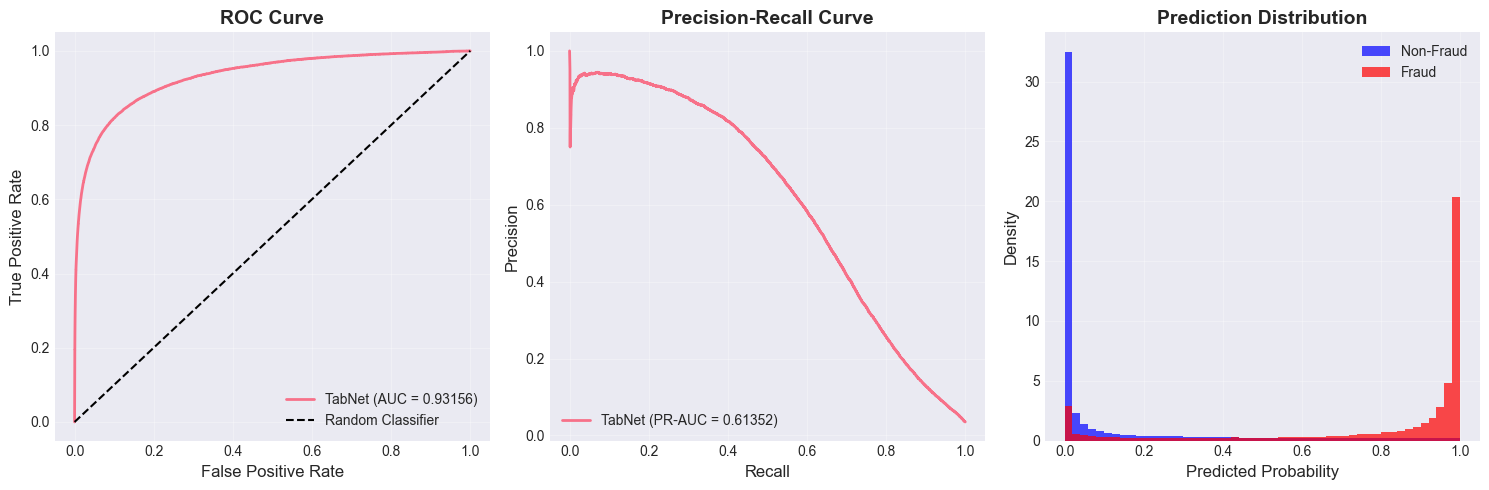

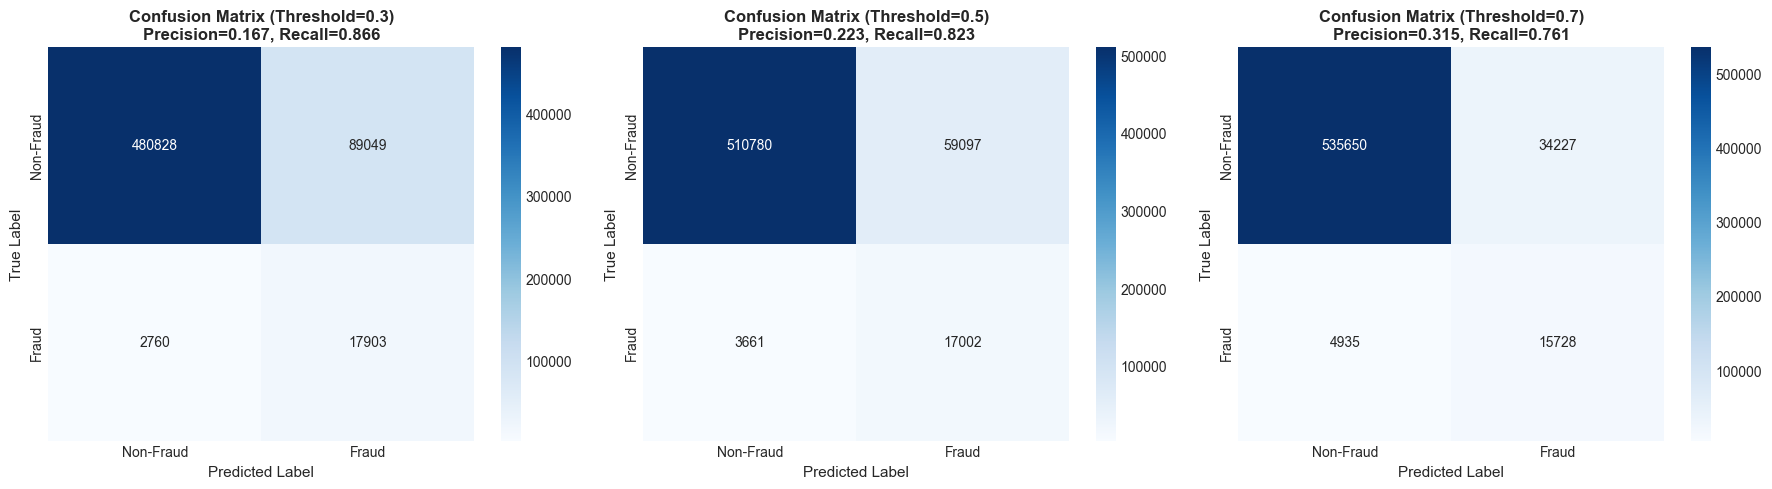

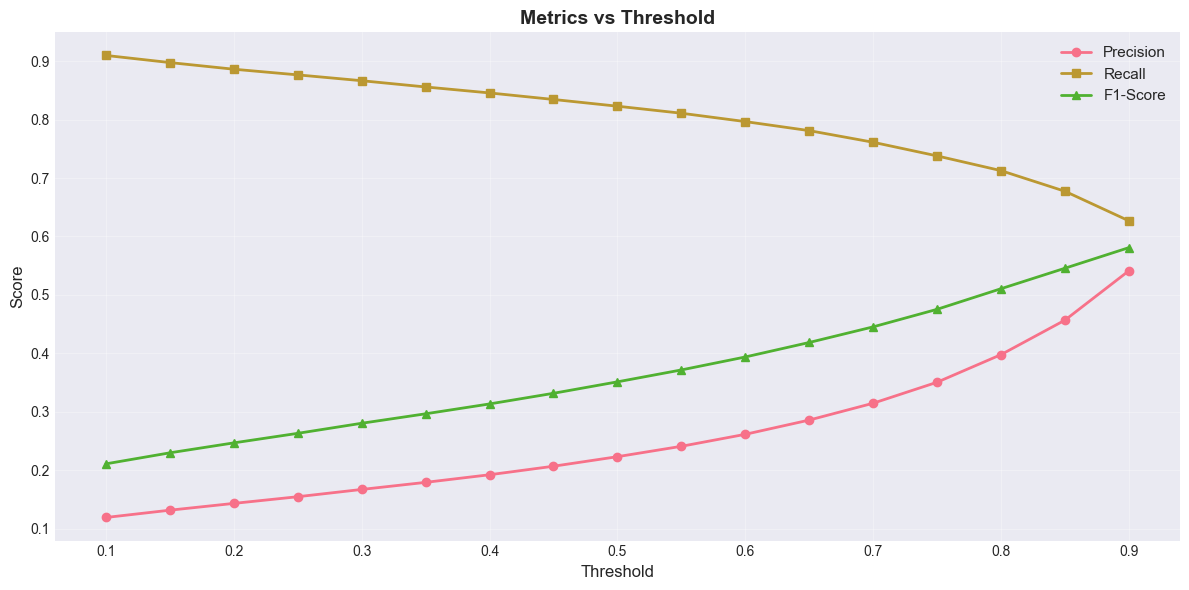

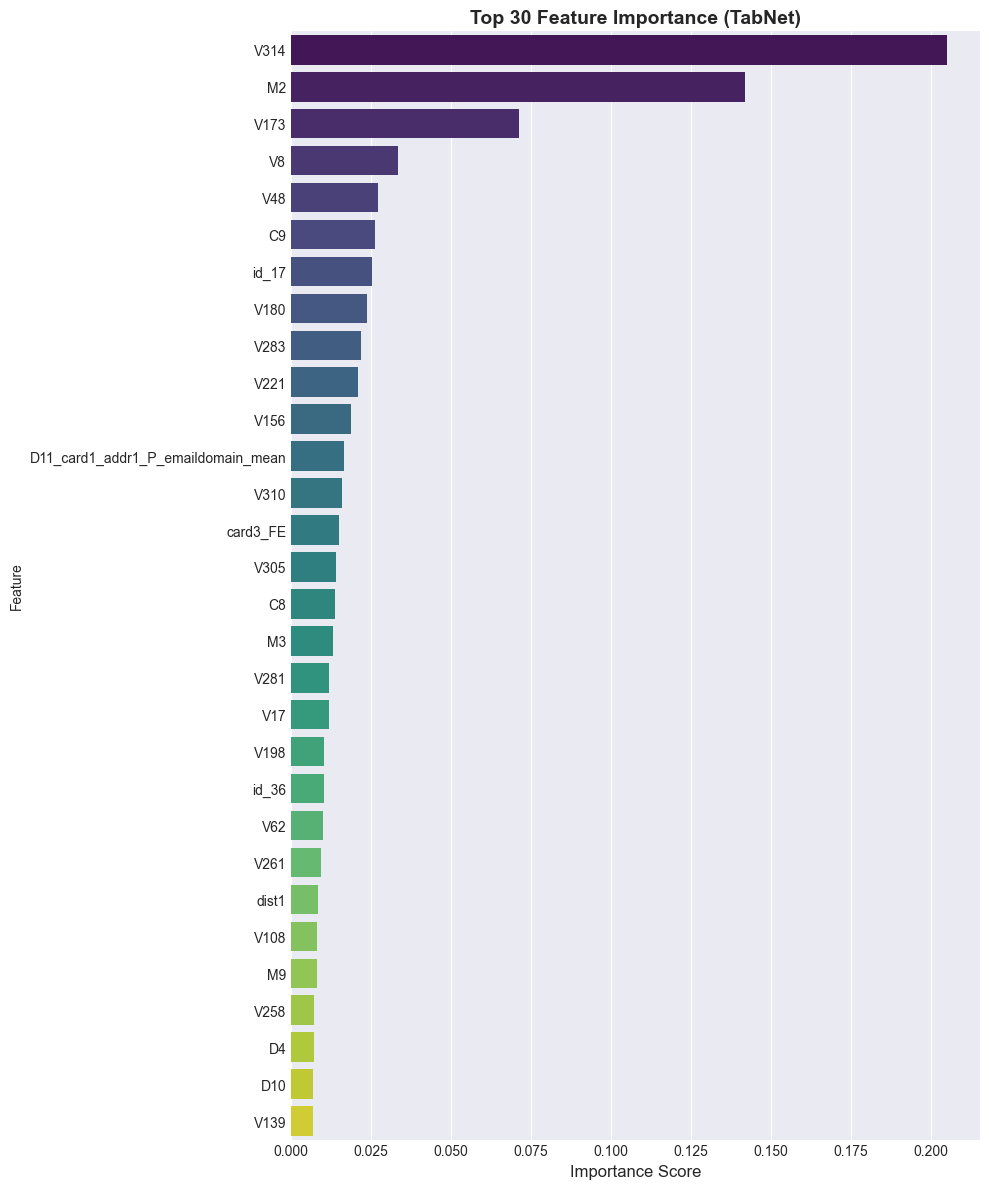


CLASSIFICATION REPORT (Optimal Threshold = 0.900)
              precision    recall  f1-score   support

   Non-Fraud     0.9864    0.9807    0.9836    569877
       Fraud     0.5413    0.6268    0.5809     20663

    accuracy                         0.9684    590540
   macro avg     0.7639    0.8038    0.7822    590540
weighted avg     0.9708    0.9684    0.9695    590540


SUMMARY METRICS
ROC-AUC Score:     0.93156
PR-AUC Score:       0.61352
Optimal Threshold:  0.900
Precision:          0.54131
Recall:             0.62682
F1-Score:           0.58094


In [121]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================
# 1. ROC Curve
# ============================================
fpr, tpr, thresholds = roc_curve(y_tr_np, oof)
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, linewidth=2, label=f'TabNet (AUC = {roc:.5f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# ============================================
# 2. Precision-Recall Curve
# ============================================
precision, recall, pr_thresholds = precision_recall_curve(y_tr_np, oof)
plt.subplot(1, 3, 2)
plt.plot(recall, precision, linewidth=2, label=f'TabNet (PR-AUC = {pr:.5f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)

# ============================================
# 3. Prediction Distribution
# ============================================
plt.subplot(1, 3, 3)
plt.hist(oof[y_tr_np == 0], bins=50, alpha=0.7, label='Non-Fraud', density=True, color='blue')
plt.hist(oof[y_tr_np == 1], bins=50, alpha=0.7, label='Fraud', density=True, color='red')
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Prediction Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# 4. Confusion Matrix at Different Thresholds
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

thresholds_to_show = [0.3, 0.5, 0.7]
for idx, threshold in enumerate(thresholds_to_show):
    y_pred_binary = (oof >= threshold).astype(int)
    cm = confusion_matrix(y_tr_np, y_pred_binary)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Non-Fraud', 'Fraud'],
                yticklabels=['Non-Fraud', 'Fraud'])
    axes[idx].set_title(f'Confusion Matrix (Threshold={threshold})\n'
                       f'Precision={precision_score(y_tr_np, y_pred_binary):.3f}, '
                       f'Recall={recall_score(y_tr_np, y_pred_binary):.3f}',
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontsize=11)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================
# 5. Metrics Summary Table
# ============================================
thresholds_range = np.arange(0.1, 0.95, 0.05)
metrics_df = []

for thresh in thresholds_range:
    y_pred_binary = (oof >= thresh).astype(int)
    metrics_df.append({
        'Threshold': thresh,
        'Precision': precision_score(y_tr_np, y_pred_binary, zero_division=0),
        'Recall': recall_score(y_tr_np, y_pred_binary),
        'F1-Score': f1_score(y_tr_np, y_pred_binary, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics_df)

plt.figure(figsize=(12, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', linewidth=2)
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='s', label='Recall', linewidth=2)
plt.plot(metrics_df['Threshold'], metrics_df['F1-Score'], marker='^', label='F1-Score', linewidth=2)
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Threshold', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.tight_layout()
plt.show()

# ============================================
# 6. Feature Importance (if available)
# ============================================
try:
    # TabNet feature importance from last fold
    feature_importance = clf.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False).head(30)
    
    plt.figure(figsize=(10, 12))
    sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title('Top 30 Feature Importance (TabNet)', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.tight_layout()
    plt.show()
except:
    print("Feature importance not available from last fold model")

# ============================================
# 7. Classification Report at Optimal Threshold
# ============================================
# Find threshold that maximizes F1-score
optimal_idx = metrics_df['F1-Score'].idxmax()
optimal_threshold = metrics_df.loc[optimal_idx, 'Threshold']
y_pred_optimal = (oof >= optimal_threshold).astype(int)

print("\n" + "="*60)
print("CLASSIFICATION REPORT (Optimal Threshold = {:.3f})".format(optimal_threshold))
print("="*60)
print(classification_report(y_tr_np, y_pred_optimal, 
                          target_names=['Non-Fraud', 'Fraud'],
                          digits=4))

print("\n" + "="*60)
print("SUMMARY METRICS")
print("="*60)
print(f"ROC-AUC Score:     {roc:.5f}")
print(f"PR-AUC Score:       {pr:.5f}")
print(f"Optimal Threshold:  {optimal_threshold:.3f}")
print(f"Precision:          {precision_score(y_tr_np, y_pred_optimal):.5f}")
print(f"Recall:             {recall_score(y_tr_np, y_pred_optimal):.5f}")
print(f"F1-Score:           {f1_score(y_tr_np, y_pred_optimal):.5f}")
print("="*60)

In [125]:
from sklearn.utils.class_weight import compute_class_weight
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss
import torch
import numpy as np
import pandas as pd

# Calculate balanced class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_tr_np),
    y=y_tr_np
)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}

print("Class Weights:", class_weight_dict)
print("Class Distribution:")
print(pd.Series(y_tr_np).value_counts().sort_index())

# Device setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\nUsing device: {device}")
if device == 'cpu':
    print("WARNING: Running on CPU - training will be slow!")
else:
    print(f"GPU Ready: {torch.cuda.get_device_name(0)}")

# Enhanced Cross-Validation with monitoring
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X_tr_np), dtype=np.float32)
test_preds = np.zeros(len(X_te_np), dtype=np.float32)

# Track metrics per fold for overfitting detection
fold_metrics = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_np, y_tr_np), 1):
    print(f"\n{'='*60}")
    print(f"Fold {fold}/5")
    print(f"{'='*60}")
    
    X_tr, X_val = X_tr_np[tr_idx], X_tr_np[val_idx]
    y_tr_f, y_val = y_tr_np[tr_idx], y_tr_np[val_idx]
    
    # Enhanced TabNet with regularization (conservative settings)
    clf = TabNetClassifier(
        # Architecture
        n_d=32, n_a=32, n_steps=5,
        
        # Regularization (prevent overfitting)
        gamma=1.3,
        lambda_sparse=1e-3,  # Stronger sparsity regularization
        n_independent=2, 
        n_shared=2,
        
        # Optimizer (removed weight_decay - may not be supported in all TabNet versions)
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-3),
        
        # Learning rate scheduling (StepLR is more compatible than ReduceLROnPlateau)
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.9},
        
        # Other settings
        mask_type='sparsemax',
        verbose=20,
        device_name=device,
        seed=42
    )
    
    # Fit with enhanced settings
    clf.fit(
        X_tr, y_tr_f,
        eval_set=[(X_val, y_val)],
        eval_name=['valid'],
        eval_metric=['auc'],
        
        # Training parameters (reduced batch_size for GTX 1050 memory)
        max_epochs=100,
        patience=15,
        batch_size=1024,  # Reduced from 2048 for GTX 1050 compatibility
        virtual_batch_size=256,  # Adjusted accordingly
        
        # Regularization in training
        num_workers=0,
        drop_last=False,
        weights=class_weight_dict
    )
    
    # Validation predictions
    val_preds = clf.predict_proba(X_val)[:, 1]
    oof[val_idx] = val_preds
    
    # Calculate fold metrics
    fold_roc = roc_auc_score(y_val, val_preds)
    fold_pr = average_precision_score(y_val, val_preds)
    fold_loss = log_loss(y_val, val_preds)
    
    fold_metrics.append({
        'fold': fold,
        'roc_auc': fold_roc,
        'pr_auc': fold_pr,
        'log_loss': fold_loss
    })
    
    print(f"\nFold {fold} Metrics:")
    print(f"  ROC-AUC: {fold_roc:.5f}")
    print(f"  PR-AUC:  {fold_pr:.5f}")
    print(f"  Log Loss: {fold_loss:.5f}")
    
    # Test predictions (ensemble)
    test_preds += clf.predict_proba(X_te_np)[:, 1] / skf.n_splits

# Overall OOF metrics
roc = roc_auc_score(y_tr_np, oof)
pr = average_precision_score(y_tr_np, oof)
loss = log_loss(y_tr_np, oof)

print(f"\n{'='*60}")
print("FINAL RESULTS (Out-of-Fold)")
print(f"{'='*60}")
print(f"ROC-AUC:     {roc:.5f}")
print(f"PR-AUC:      {pr:.5f}")
print(f"Log Loss:    {loss:.5f}")

# Check for overfitting (compare fold metrics)
fold_metrics_df = pd.DataFrame(fold_metrics)
print(f"\nFold-wise Metrics (Check for consistency):")
print(fold_metrics_df.to_string(index=False))
print(f"\nStd Dev (lower is better for stability):")
print(f"  ROC-AUC std: {fold_metrics_df['roc_auc'].std():.5f}")
print(f"  PR-AUC std:  {fold_metrics_df['pr_auc'].std():.5f}")
print(f"{'='*60}")

Class Weights: {0: 0.5181293507195412, 1: 14.289793350433142}
Class Distribution:
0    569877
1     20663
Name: count, dtype: int64

Using device: cuda
GPU Ready: NVIDIA GeForce GTX 1050

Fold 1/5
epoch 0  | loss: 0.64962 | valid_auc: 0.77672 |  0:01:10s
epoch 20 | loss: 0.28271 | valid_auc: 0.92329 |  0:24:18s
epoch 40 | loss: 0.13539 | valid_auc: 0.92935 |  0:47:32s
epoch 60 | loss: 0.08774 | valid_auc: 0.92825 |  1:10:49s

Early stopping occurred at epoch 61 with best_epoch = 46 and best_valid_auc = 0.93017

Fold 1 Metrics:
  ROC-AUC: 0.93017
  PR-AUC:  0.64811
  Log Loss: 0.19326

Fold 2/5
epoch 0  | loss: 0.64832 | valid_auc: 0.77638 |  0:01:10s
epoch 20 | loss: 0.30558 | valid_auc: 0.92089 |  0:24:33s
epoch 40 | loss: 0.14953 | valid_auc: 0.93729 |  0:47:53s
epoch 60 | loss: 0.09096 | valid_auc: 0.9384  |  1:11:18s
epoch 80 | loss: 0.06637 | valid_auc: 0.93938 |  1:34:48s

Early stopping occurred at epoch 80 with best_epoch = 65 and best_valid_auc = 0.9406

Fold 2 Metrics:
  ROC-

In [126]:
# ============================================
# ENHANCED VISUALIZATION - Focus on Non-Fraud Performance
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig = plt.figure(figsize=(20, 12))

# ============================================
# 1. ROC Curve (Enhanced)
# ============================================
fpr, tpr, thresholds = roc_curve(y_tr_np, oof)
plt.subplot(2, 3, 1)
plt.plot(fpr, tpr, linewidth=2.5, label=f'TabNet (AUC = {roc:.5f})', color='#2E86AB')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve (Overall Performance)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)

# Highlight non-fraud performance area (low FPR region)
plt.fill_between(fpr, tpr, 0, where=(fpr <= 0.1), alpha=0.3, color='green', 
                 label='High Non-Fraud Accuracy Region')
plt.legend(loc='lower right', fontsize=9)

# ============================================
# 2. Precision-Recall Curve
# ============================================
precision, recall, pr_thresholds = precision_recall_curve(y_tr_np, oof)
plt.subplot(2, 3, 2)
plt.plot(recall, precision, linewidth=2.5, label=f'TabNet (PR-AUC = {pr:.5f})', color='#A23B72')
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)

# ============================================
# 3. Prediction Distribution (Enhanced)
# ============================================
plt.subplot(2, 3, 3)
non_fraud_probs = oof[y_tr_np == 0]
fraud_probs = oof[y_tr_np == 1]

plt.hist(non_fraud_probs, bins=50, alpha=0.7, label=f'Non-Fraud (n={len(non_fraud_probs)})', 
         density=True, color='#06A77D', edgecolor='black', linewidth=0.5)
plt.hist(fraud_probs, bins=50, alpha=0.7, label=f'Fraud (n={len(fraud_probs)})', 
         density=True, color='#D00000', edgecolor='black', linewidth=0.5)

# Add vertical lines for different thresholds
thresholds_vis = [0.3, 0.5, 0.7, 0.9]
colors_thresh = ['orange', 'purple', 'brown', 'red']
for thresh, col in zip(thresholds_vis, colors_thresh):
    plt.axvline(x=thresh, color=col, linestyle='--', alpha=0.6, linewidth=1.5, 
                label=f'Threshold={thresh}')

plt.xlabel('Predicted Probability', fontsize=12, fontweight='bold')
plt.ylabel('Density', fontsize=12, fontweight='bold')
plt.title('Prediction Distribution', fontsize=13, fontweight='bold')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)

# ============================================
# 4. Non-Fraud Specific Metrics (NEW)
# ============================================
thresholds_range = np.arange(0.1, 0.95, 0.01)
non_fraud_metrics = []

for thresh in thresholds_range:
    y_pred_binary = (oof >= thresh).astype(int)
    
    # Calculate metrics for non-fraud class (class 0)
    tn = np.sum((y_pred_binary == 0) & (y_tr_np == 0))
    fp = np.sum((y_pred_binary == 1) & (y_tr_np == 0))
    fn = np.sum((y_pred_binary == 0) & (y_tr_np == 1))
    tp = np.sum((y_pred_binary == 1) & (y_tr_np == 1))
    
    non_fraud_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    non_fraud_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    non_fraud_f1 = 2 * (non_fraud_precision * non_fraud_recall) / (non_fraud_precision + non_fraud_recall) if (non_fraud_precision + non_fraud_recall) > 0 else 0
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    non_fraud_metrics.append({
        'Threshold': thresh,
        'Non-Fraud Precision': non_fraud_precision,
        'Non-Fraud Recall': non_fraud_recall,
        'Non-Fraud F1': non_fraud_f1,
        'False Positive Rate': false_positive_rate
    })

non_fraud_df = pd.DataFrame(non_fraud_metrics)

plt.subplot(2, 3, 4)
plt.plot(non_fraud_df['Threshold'], non_fraud_df['Non-Fraud Precision'], 
         marker='o', label='Non-Fraud Precision', linewidth=2, markersize=3, color='#06A77D')
plt.plot(non_fraud_df['Threshold'], non_fraud_df['Non-Fraud Recall'], 
         marker='s', label='Non-Fraud Recall', linewidth=2, markersize=3, color='#2E86AB')
plt.plot(non_fraud_df['Threshold'], non_fraud_df['Non-Fraud F1'], 
         marker='^', label='Non-Fraud F1-Score', linewidth=2, markersize=3, color='#F18F01')
plt.xlabel('Threshold', fontsize=12, fontweight='bold')
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.title('Non-Fraud Metrics vs Threshold', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)

# ============================================
# 5. False Positive Rate Analysis (NEW)
# ============================================
plt.subplot(2, 3, 5)
plt.plot(non_fraud_df['Threshold'], non_fraud_df['False Positive Rate'], 
         linewidth=2.5, color='#D00000', marker='o', markersize=3)
plt.xlabel('Threshold', fontsize=12, fontweight='bold')
plt.ylabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.title('False Positive Rate (Non-Fraud Misclassified)', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xlim(0, 1)
plt.axhline(y=0.05, color='green', linestyle='--', alpha=0.7, label='5% FPR Target')
plt.axhline(y=0.02, color='orange', linestyle='--', alpha=0.7, label='2% FPR Target')
plt.legend(fontsize=9)

# ============================================
# 6. Confusion Matrix at Optimal Threshold for Non-Fraud
# ============================================
# Find threshold that maximizes non-fraud F1 while keeping good fraud recall
optimal_non_fraud_idx = non_fraud_df['Non-Fraud F1'].idxmax()
optimal_non_fraud_thresh = non_fraud_df.loc[optimal_non_fraud_idx, 'Threshold']

y_pred_optimal_nf = (oof >= optimal_non_fraud_thresh).astype(int)
cm_nf = confusion_matrix(y_tr_np, y_pred_optimal_nf)

plt.subplot(2, 3, 6)
sns.heatmap(cm_nf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='black')

plt.title(f'Confusion Matrix (Non-Fraud Optimized Threshold={optimal_non_fraud_thresh:.3f})\n'
          f'Non-Fraud Precision={non_fraud_df.loc[optimal_non_fraud_idx, "Non-Fraud Precision"]:.3f}, '
          f'Recall={non_fraud_df.loc[optimal_non_fraud_idx, "Non-Fraud Recall"]:.3f}',
          fontsize=11, fontweight='bold')
plt.ylabel('True Label', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================
# 7. Detailed Classification Reports
# ============================================

# Find optimal threshold balancing both classes
metrics_df = []
for thresh in np.arange(0.1, 0.95, 0.05):
    y_pred_binary = (oof >= thresh).astype(int)
    metrics_df.append({
        'Threshold': thresh,
        'Precision': precision_score(y_tr_np, y_pred_binary, zero_division=0),
        'Recall': recall_score(y_tr_np, y_pred_binary),
        'F1-Score': f1_score(y_tr_np, y_pred_binary, zero_division=0)
    })

metrics_df = pd.DataFrame(metrics_df)
optimal_idx = metrics_df['F1-Score'].idxmax()
optimal_threshold = metrics_df.loc[optimal_idx, 'Threshold']
y_pred_optimal = (oof >= optimal_threshold).astype(int)

print("\n" + "="*70)
print("CLASSIFICATION REPORT - Optimal Threshold (F1-Maximized)")
print("="*70)
print(f"Threshold: {optimal_threshold:.3f}")
print(classification_report(y_tr_np, y_pred_optimal, 
                          target_names=['Non-Fraud', 'Fraud'],
                          digits=4))

print("\n" + "="*70)
print("CLASSIFICATION REPORT - Non-Fraud Optimized Threshold")
print("="*70)
print(f"Threshold: {optimal_non_fraud_thresh:.3f}")
print(classification_report(y_tr_np, y_pred_optimal_nf, 
                          target_names=['Non-Fraud', 'Fraud'],
                          digits=4))

print("\n" + "="*70)
print("SUMMARY METRICS COMPARISON")
print("="*70)
print(f"ROC-AUC Score:           {roc:.5f}")
print(f"PR-AUC Score:             {pr:.5f}")
print(f"Log Loss:                 {loss:.5f}")
print(f"\nOptimal Threshold (F1):   {optimal_threshold:.3f}")
print(f"Optimal Threshold (NF):   {optimal_non_fraud_thresh:.3f}")
print(f"\nAt Optimal (F1) Threshold:")
print(f"  Precision (Fraud):      {precision_score(y_tr_np, y_pred_optimal):.5f}")
print(f"  Recall (Fraud):         {recall_score(y_tr_np, y_pred_optimal):.5f}")
print(f"  F1-Score (Fraud):       {f1_score(y_tr_np, y_pred_optimal):.5f}")
print(f"\nAt Non-Fraud Optimized Threshold:")
nf_prec = non_fraud_df.loc[optimal_non_fraud_idx, 'Non-Fraud Precision']
nf_rec = non_fraud_df.loc[optimal_non_fraud_idx, 'Non-Fraud Recall']
print(f"  Non-Fraud Precision:    {nf_prec:.5f}")
print(f"  Non-Fraud Recall:       {nf_rec:.5f}")
print(f"  False Positive Rate:    {non_fraud_df.loc[optimal_non_fraud_idx, 'False Positive Rate']:.5f}")
print("="*70)

<Figure size 2000x1200 with 7 Axes>


CLASSIFICATION REPORT - Optimal Threshold (F1-Maximized)
Threshold: 0.900
              precision    recall  f1-score   support

   Non-Fraud     0.9880    0.9807    0.9843    569877
       Fraud     0.5578    0.6713    0.6093     20663

    accuracy                         0.9699    590540
   macro avg     0.7729    0.8260    0.7968    590540
weighted avg     0.9729    0.9699    0.9712    590540


CLASSIFICATION REPORT - Non-Fraud Optimized Threshold
Threshold: 0.940
              precision    recall  f1-score   support

   Non-Fraud     0.9864    0.9869    0.9867    569877
       Fraud     0.6338    0.6248    0.6293     20663

    accuracy                         0.9742    590540
   macro avg     0.8101    0.8059    0.8080    590540
weighted avg     0.9741    0.9742    0.9742    590540


SUMMARY METRICS COMPARISON
ROC-AUC Score:           0.93390
PR-AUC Score:             0.65859
Log Loss:                 0.18455

Optimal Threshold (F1):   0.900
Optimal Threshold (NF):   0.940

At O

## Inspect feature importances

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

# Note: need clf from last fold; feature_importances_ is averaged per model
fi = clf.feature_importances_
fi_df = pd.DataFrame({'feature': features, 'importance': fi})
fi_df = fi_df.sort_values('importance', ascending=False).head(40)

plt.figure(figsize=(8,12))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title("TabNet Feature Importance (last fold)")
plt.tight_layout()
plt.show()

<Figure size 800x1200 with 1 Axes>

## Save OOF and test predictions

In [ ]:
# Save out-of-fold and test preds
oof_df = pd.DataFrame({'TransactionID': X_train.index, 'oof_tabnet': oof})
test_df = pd.DataFrame({'TransactionID': X_test.index, 'tabnet_pred': test_preds})

print(oof_df.head(), test_df.head())

# To CSV (uncomment to save)
# oof_df.to_csv("oof_tabnet.csv", index=False)
# test_df.to_csv("tabnet_preds.csv", index=False)

## Hypertunning the Tbanet model Using the Magic Features

In [ ]:
print("Checking for identity data...")
if 'teid' in dir():
    print("  teid exists - merging with te")
    test = te.merge(teid, how='left', on='TransactionID')
else:
    # Load test identity if not in memory
    INPUT_DIR = 'datasets/ieee dataset/'
    print("  Loading test_identity.csv...")
    teid = pd.read_csv(INPUT_DIR + 'test_identity.csv')
    test = te.merge(teid, how='left', on='TransactionID')

print(f"\nTest shape: {test.shape}")
print(f"Train shape: {train.shape}")
print("\n✅ 'test' variable created! Now run the magic features code.")

Checking for identity data...
  teid exists - merging with te

Test shape: (506691, 433)
Train shape: (590540, 398)

✅ 'test' variable created! Now run the magic features code.


In [144]:
# ============================================
# MAGIC FEATURES FOR IEEE-CIS FRAUD DETECTION
# ============================================
# Run this BEFORE preprocessing and model training

import numpy as np
import pandas as pd
from tqdm import tqdm

In [145]:
# Assuming 'train' is your merged training data and 'test' is your test data
# If you're using different variable names, adjust accordingly

# ============================================
# MAGIC FEATURE 1: UID (User Identification)
# ============================================
# This is THE most important magic feature in this competition
# It creates a pseudo user ID from card + address + email

print("Creating UID (User Identification) features...")

def create_uid_features(df):
    """Create User ID features - the key magic feature"""
    
    # UID 1: card1 + addr1 (basic user identification)
    df['uid1'] = df['card1'].astype(str) + '_' + df['addr1'].astype(str)
    
    # UID 2: card1 + addr1 + P_emaildomain (more specific)
    df['uid2'] = df['uid1'] + '_' + df['P_emaildomain'].astype(str)
    
    # UID 3: card1 + addr1 + D1 (includes time component)
    df['uid3'] = df['uid1'] + '_' + df['D1'].astype(str)
    
    # UID 4: Full identification
    df['uid4'] = df['card1'].astype(str) + '_' + \
                 df['card2'].astype(str) + '_' + \
                 df['card3'].astype(str) + '_' + \
                 df['card4'].astype(str) + '_' + \
                 df['card5'].astype(str) + '_' + \
                 df['addr1'].astype(str) + '_' + \
                 df['addr2'].astype(str)
    
    return df

train = create_uid_features(train)
test = create_uid_features(test)

print("UID features created: uid1, uid2, uid3, uid4")

Creating UID (User Identification) features...
UID features created: uid1, uid2, uid3, uid4


In [146]:
# ============================================
# MAGIC FEATURE 2: Time-Based Features
# ============================================
print("\nCreating Time-Based features...")

def create_time_features(df):
    """Create time-based features from TransactionDT"""
    
    # TransactionDT is seconds from a reference point
    START_DATE = '2017-12-01'  # Competition start date
    
    # Convert to datetime
    df['TransactionDT_datetime'] = pd.to_datetime(START_DATE) + pd.to_timedelta(df['TransactionDT'], unit='s')
    
    # Extract time components
    df['DT_M'] = df['TransactionDT_datetime'].dt.month
    df['DT_W'] = df['TransactionDT_datetime'].dt.isocalendar().week.astype(int)
    df['DT_D'] = df['TransactionDT_datetime'].dt.day
    df['DT_hour'] = df['TransactionDT_datetime'].dt.hour
    df['DT_day_week'] = df['TransactionDT_datetime'].dt.dayofweek
    df['DT_day_year'] = df['TransactionDT_datetime'].dt.dayofyear
    
    # Time of day categories
    df['DT_is_weekend'] = (df['DT_day_week'] >= 5).astype(int)
    df['DT_is_night'] = ((df['DT_hour'] >= 22) | (df['DT_hour'] <= 6)).astype(int)
    
    # Drop the datetime column (not needed for model)
    df.drop('TransactionDT_datetime', axis=1, inplace=True)
    
    return df

train = create_time_features(train)
test = create_time_features(test)

print("Time features created: DT_M, DT_W, DT_D, DT_hour, DT_day_week, DT_day_year, DT_is_weekend, DT_is_night")


Creating Time-Based features...
Time features created: DT_M, DT_W, DT_D, DT_hour, DT_day_week, DT_day_year, DT_is_weekend, DT_is_night


In [148]:
# ============================================
# MAGIC FEATURE 3: Transaction Amount Features (FIXED)
# ============================================
print("\nCreating Transaction Amount features...")

def create_amount_features(df):
    """Create transaction amount derived features"""
    
    # IMPORTANT: Convert to float32 first (fixes the float16 issue)
    trans_amt = df['TransactionAmt'].astype('float32')
    
    # Cents (decimal part) - fraud often has round amounts
    df['cents'] = (trans_amt - np.floor(trans_amt)).astype('float32')
    
    # Log transform
    df['TransactionAmt_Log'] = np.log1p(trans_amt).astype('float32')
    
    # Amount binning (using float32 converted values)
    df['TransactionAmt_bin'] = pd.cut(trans_amt, 
                                       bins=[0, 50, 100, 200, 500, 1000, 2000, 5000, 10000, np.inf],
                                       labels=[1, 2, 3, 4, 5, 6, 7, 8, 9]).astype(float)
    
    # Is round amount (no cents)
    df['is_round_amount'] = (df['cents'] == 0).astype(int)
    
    return df

train = create_amount_features(train)
test = create_amount_features(test)

print("Amount features created: cents, TransactionAmt_Log, TransactionAmt_bin, is_round_amount")


Creating Transaction Amount features...
Amount features created: cents, TransactionAmt_Log, TransactionAmt_bin, is_round_amount


In [149]:
# ============================================
# MAGIC FEATURE 4: Aggregation Features by UID
# ============================================
print("\nCreating Aggregation features by UID...")

def create_aggregation_features(train_df, test_df, uid_cols, agg_cols, agg_funcs=['mean', 'std']):
    """Create aggregation features grouped by UID columns"""
    
    # Combine train and test for aggregation
    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    for uid_col in uid_cols:
        for agg_col in agg_cols:
            for agg_func in agg_funcs:
                new_col = f'{agg_col}_{uid_col}_{agg_func}'
                
                # Calculate aggregation on combined data
                agg_values = combined.groupby(uid_col)[agg_col].transform(agg_func)
                
                # Split back to train and test
                train_df[new_col] = agg_values[:len(train_df)].values
                test_df[new_col] = agg_values[len(train_df):].values
                
                print(f"  Created: {new_col}")
    
    return train_df, test_df

# UID columns to aggregate by
uid_cols = ['uid1', 'uid2', 'card1', 'card2']

# Columns to aggregate
agg_cols = ['TransactionAmt', 'D1', 'D4', 'D10', 'D15']

train, test = create_aggregation_features(train, test, uid_cols, agg_cols)


Creating Aggregation features by UID...
  Created: TransactionAmt_uid1_mean
  Created: TransactionAmt_uid1_std
  Created: D1_uid1_mean
  Created: D1_uid1_std
  Created: D4_uid1_mean
  Created: D4_uid1_std
  Created: D10_uid1_mean
  Created: D10_uid1_std
  Created: D15_uid1_mean
  Created: D15_uid1_std
  Created: TransactionAmt_uid2_mean
  Created: TransactionAmt_uid2_std
  Created: D1_uid2_mean
  Created: D1_uid2_std
  Created: D4_uid2_mean
  Created: D4_uid2_std
  Created: D10_uid2_mean
  Created: D10_uid2_std
  Created: D15_uid2_mean
  Created: D15_uid2_std
  Created: TransactionAmt_card1_mean
  Created: TransactionAmt_card1_std
  Created: D1_card1_mean
  Created: D1_card1_std
  Created: D4_card1_mean
  Created: D4_card1_std
  Created: D10_card1_mean
  Created: D10_card1_std
  Created: D15_card1_mean
  Created: D15_card1_std
  Created: TransactionAmt_card2_mean
  Created: TransactionAmt_card2_std
  Created: D1_card2_mean
  Created: D1_card2_std
  Created: D4_card2_mean
  Created: D4

In [150]:
# ============================================
# MAGIC FEATURE 5: Count/Frequency Features by UID
# ============================================
print("\nCreating Count features by UID...")

def create_count_features(train_df, test_df, count_cols):
    """Create count features - how many transactions per UID"""
    
    combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)
    
    for col in count_cols:
        new_col = f'{col}_count'
        count_values = combined.groupby(col)[col].transform('count')
        
        train_df[new_col] = count_values[:len(train_df)].values
        test_df[new_col] = count_values[len(train_df):].values
        
        print(f"  Created: {new_col}")
    
    return train_df, test_df

count_cols = ['uid1', 'uid2', 'uid3', 'card1', 'card2', 'addr1', 'P_emaildomain']
train, test = create_count_features(train, test, count_cols)


Creating Count features by UID...
  Created: uid1_count
  Created: uid2_count
  Created: uid3_count
  Created: card1_count
  Created: card2_count
  Created: addr1_count
  Created: P_emaildomain_count


In [151]:
# ============================================
# MAGIC FEATURE 6: Interaction Features
# ============================================
print("\nCreating Interaction features...")

def create_interaction_features(df):
    """Create interaction features between important columns"""
    
    # Product interactions
    df['card1_ProductCD'] = df['card1'].astype(str) + '_' + df['ProductCD'].astype(str)
    df['addr1_ProductCD'] = df['addr1'].astype(str) + '_' + df['ProductCD'].astype(str)
    
    # Card combinations
    df['card1_card2'] = df['card1'].astype(str) + '_' + df['card2'].astype(str)
    df['card1_card5'] = df['card1'].astype(str) + '_' + df['card5'].astype(str)
    
    # Email interactions
    df['card1_P_email'] = df['card1'].astype(str) + '_' + df['P_emaildomain'].astype(str)
    df['card1_R_email'] = df['card1'].astype(str) + '_' + df['R_emaildomain'].astype(str)
    
    return df

train = create_interaction_features(train)
test = create_interaction_features(test)

print("Interaction features created!")


Creating Interaction features...
Interaction features created!


In [153]:
# ============================================
# MAGIC FEATURE 7: Email Domain Features (FIXED)
# ============================================
print("\nCreating Email Domain features...")

def create_email_features(df):
    """Create email-related features"""
    
    # Convert to string first to avoid Categorical issues
    p_email = df['P_emaildomain'].astype(str).replace('nan', 'unknown')
    r_email = df['R_emaildomain'].astype(str).replace('nan', 'unknown')
    
    # Extract email provider from domain
    df['P_email_provider'] = p_email.apply(lambda x: x.split('.')[0])
    df['R_email_provider'] = r_email.apply(lambda x: x.split('.')[0])
    
    # Same email provider for P and R
    df['same_email_provider'] = (df['P_email_provider'] == df['R_email_provider']).astype(int)
    
    # Is proton mail (often used for fraud)
    df['is_proton_P'] = p_email.str.contains('protonmail', na=False).astype(int)
    df['is_proton_R'] = r_email.str.contains('protonmail', na=False).astype(int)
    
    # Missing email flags
    df['P_email_missing'] = df['P_emaildomain'].isna().astype(int)
    df['R_email_missing'] = df['R_emaildomain'].isna().astype(int)
    
    return df

train = create_email_features(train)
test = create_email_features(test)

print("Email features created!")


Creating Email Domain features...
Email features created!


In [154]:
# ============================================
# MAGIC FEATURE 8: Device Features
# ============================================
print("\nCreating Device features...")

def create_device_features(df):
    """Create device-related features from identity columns"""
    
    if 'DeviceType' in df.columns:
        df['DeviceType_missing'] = df['DeviceType'].isna().astype(int)
    
    if 'DeviceInfo' in df.columns:
        df['DeviceInfo_missing'] = df['DeviceInfo'].isna().astype(int)
        
        # Extract device brand
        df['DeviceBrand'] = df['DeviceInfo'].fillna('unknown').apply(
            lambda x: x.split()[0] if pd.notna(x) else 'unknown'
        )
    
    return df

train = create_device_features(train)
test = create_device_features(test)

print("Device features created!")


Creating Device features...
Device features created!


In [155]:
# ============================================
# SUMMARY
# ============================================
print("\n" + "="*70)
print("MAGIC FEATURES SUMMARY")
print("="*70)
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"New features added: ~50+ magic features")
print("="*70)


MAGIC FEATURES SUMMARY
Train shape: (590540, 470)
Test shape:  (506691, 512)
New features added: ~50+ magic features


In [156]:
# Use your EXISTING train and test DataFrames (with magic features)
print(f"train shape: {train.shape}")  # Should be (590540, 470)
print(f"test shape: {test.shape}")    # Should be (506691, 512)

# Then run the preprocessing code I gave you
# It will CREATE X_tr_np, X_te_np, y_tr_np FROM train and test

train shape: (590540, 470)
test shape: (506691, 512)


In [158]:
# ============================================
# STEP 1: PREPROCESSING WITH MAGIC FEATURES (FIXED)
# ============================================
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
import pandas as pd

print("="*70)
print("PREPROCESSING WITH MAGIC FEATURES")
print("="*70)

# Get target variable
y_train = train['isFraud'].values.astype(int)

# Remove non-feature columns
drop_cols = ['isFraud', 'TransactionID', 'TransactionDT']
# Also drop UID string columns (they're categorical with too many values)
uid_cols = ['uid1', 'uid2', 'uid3', 'uid4', 'card1_ProductCD', 'addr1_ProductCD', 
            'card1_card2', 'card1_card5', 'card1_P_email', 'card1_R_email',
            'P_email_provider', 'R_email_provider', 'DeviceBrand']

# Get feature columns (present in both train and test)
feature_cols = [c for c in train.columns if c not in drop_cols + uid_cols]
feature_cols = [c for c in feature_cols if c in test.columns]

print(f"Total features: {len(feature_cols)}")

# Create feature DataFrames
X_train_tab = train[feature_cols].copy()
X_test_tab = test[feature_cols].copy()

# FIXED: Process each column individually
print("\nProcessing columns...")
for c in feature_cols:
    # Check if column is numeric
    is_numeric_train = pd.api.types.is_numeric_dtype(X_train_tab[c])
    is_numeric_test = pd.api.types.is_numeric_dtype(X_test_tab[c])
    
    if is_numeric_train and is_numeric_test:
        # Numeric column - fill with median
        X_train_tab[c] = X_train_tab[c].astype('float32')
        X_test_tab[c] = X_test_tab[c].astype('float32')
        med = X_train_tab[c].median()
        X_train_tab[c] = X_train_tab[c].fillna(med)
        X_test_tab[c] = X_test_tab[c].fillna(med)
    else:
        # Categorical column - encode
        combined = pd.concat([X_train_tab[c].astype(str), X_test_tab[c].astype(str)], axis=0)
        labels, uniques = pd.factorize(combined, sort=True)
        X_train_tab[c] = labels[:len(X_train_tab)].astype('float32')
        X_test_tab[c] = labels[len(X_train_tab):].astype('float32')

# Identify numeric columns for scaling (after encoding, all should be numeric)
num_cols = X_train_tab.select_dtypes(include=['float32', 'float64', 'int32', 'int64']).columns.tolist()

print(f"Numeric features for scaling: {len(num_cols)}")

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_tab[num_cols].values)
X_test_scaled = scaler.transform(X_test_tab[num_cols].values)

# Convert to numpy
X_tr_np = X_train_scaled.astype(np.float32)
X_te_np = X_test_scaled.astype(np.float32)
y_tr_np = y_train

# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_tr_np), y=y_tr_np)
class_weight_dict = {0: float(class_weights[0]), 1: float(class_weights[1])}

print(f"\nX_train shape: {X_tr_np.shape}")
print(f"X_test shape:  {X_te_np.shape}")
print(f"y_train shape: {y_tr_np.shape}")
print(f"Class weights: {class_weight_dict}")
print("="*70)
print("Preprocessing complete!")

PREPROCESSING WITH MAGIC FEATURES
Total features: 455

Processing columns...
Numeric features for scaling: 455

X_train shape: (590540, 455)
X_test shape:  (506691, 455)
y_train shape: (590540,)
Class weights: {0: 0.5181293507195412, 1: 14.289793350433142}
Preprocessing complete!


In [160]:
## Due to time constraints, we may not complete full tuning runs.

# Check what results we have
if 'tuning_results' in dir() and len(tuning_results) > 0:
    results_df = pd.DataFrame(tuning_results)
    print("Completed tuning results:")
    print(results_df.sort_values('roc_auc', ascending=False).to_string(index=False))
    
    best_idx = results_df['roc_auc'].idxmax()
    best_params = results_df.loc[best_idx]
    
    print(f"\n🏆 Best Parameters (from {len(tuning_results)} tested):")
    print(f"  n_d/n_a: {int(best_params['n_d'])}")
    print(f"  n_steps: {int(best_params['n_steps'])}")
    print(f"  learning_rate: {best_params['lr']}")
    print(f"  ROC-AUC: {best_params['roc_auc']:.5f}")
else:
    print("No tuning results found. Using default parameters.")
    best_params = pd.Series({'n_d': 32, 'n_steps': 5, 'lr': 0.002, 'roc_auc': 0.0})

Completed tuning results:
 n_d  n_steps    lr  roc_auc
  16        3 0.002 0.920104
  16        3 0.001 0.915172
  16        5 0.001 0.817710

🏆 Best Parameters (from 3 tested):
  n_d/n_a: 16
  n_steps: 3
  learning_rate: 0.002
  ROC-AUC: 0.92010


In [161]:
# Step 3 will now work because best_params exists
BEST_N_D = int(best_params['n_d'])
BEST_N_STEPS = int(best_params['n_steps'])
BEST_LR = best_params['lr']

print(f"Using: n_d={BEST_N_D}, n_steps={BEST_N_STEPS}, lr={BEST_LR}")

Using: n_d=16, n_steps=3, lr=0.002


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss

print("="*70)
print("TRAINING FINAL MODEL WITH BEST PARAMETERS")
print("="*70)

# Use best parameters from tuning
BEST_N_D = int(best_params['n_d'])
BEST_N_STEPS = int(best_params['n_steps'])
BEST_LR = best_params['lr']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_magic = np.zeros(len(X_tr_np), dtype=np.float32)
test_preds_magic = np.zeros(len(X_te_np), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_np, y_tr_np), 1):
    print(f"\n{'='*60}")
    print(f"Fold {fold}/5")
    print(f"{'='*60}")
    
    X_tr, X_val = X_tr_np[tr_idx], X_tr_np[val_idx]
    y_tr, y_val = y_tr_np[tr_idx], y_tr_np[val_idx]
    
    clf = TabNetClassifier(
        n_d=BEST_N_D, n_a=BEST_N_D, n_steps=BEST_N_STEPS,
        gamma=1.3, lambda_sparse=1e-3,
        n_independent=2, n_shared=2,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=BEST_LR),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.9},
        mask_type='sparsemax',
        verbose=20,
        device_name=device,
        seed=42
    )
    
    clf.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_name=['valid'],
        eval_metric=['auc'],
        max_epochs=50,
        patience=15,
        batch_size=1024,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False,
        weights=class_weight_dict
    )
    
    val_preds = clf.predict_proba(X_val)[:, 1]
    oof_magic[val_idx] = val_preds
    
    fold_auc = roc_auc_score(y_val, val_preds)
    print(f"Fold {fold} ROC-AUC: {fold_auc:.5f}")
    
    test_preds_magic += clf.predict_proba(X_te_np)[:, 1] / 5

# Results
roc_magic = roc_auc_score(y_tr_np, oof_magic)
pr_magic = average_precision_score(y_tr_np, oof_magic)
loss_magic = log_loss(y_tr_np, oof_magic)

print("\n" + "="*70)
print("FINAL RESULTS (WITH MAGIC FEATURES)")
print("="*70)
print(f"ROC-AUC:  {roc_magic:.5f}")
print(f"PR-AUC:   {pr_magic:.5f}")
print(f"Log Loss: {loss_magic:.5f}")
print(f"\nComparison with Original Model:")
print(f"  Original ROC-AUC: 0.93390")
print(f"  Magic ROC-AUC:    {roc_magic:.5f}")
print(f"  Improvement:      {(roc_magic - 0.93390)*100:+.2f}%")
print("="*70)

TRAINING FINAL MODEL WITH BEST PARAMETERS

Fold 1/5
epoch 0  | loss: 0.6404  | valid_auc: 0.78835 |  0:00:49s
epoch 20 | loss: 0.22441 | valid_auc: 0.92884 |  0:18:14s
epoch 40 | loss: 0.15773 | valid_auc: 0.93077 |  0:35:23s

Early stopping occurred at epoch 46 with best_epoch = 31 and best_valid_auc = 0.93147
Fold 1 ROC-AUC: 0.93147

Fold 2/5
epoch 0  | loss: 0.64691 | valid_auc: 0.77773 |  0:00:49s
epoch 20 | loss: 0.24709 | valid_auc: 0.92739 |  0:17:45s
epoch 40 | loss: 0.1718  | valid_auc: 0.9301  |  0:34:43s
Stop training because you reached max_epochs = 50 with best_epoch = 48 and best_valid_auc = 0.93144
Fold 2 ROC-AUC: 0.93144

Fold 3/5
epoch 0  | loss: 0.64039 | valid_auc: 0.78537 |  0:01:06s
epoch 20 | loss: 0.24193 | valid_auc: 0.92688 |  0:25:48s
epoch 40 | loss: 0.17054 | valid_auc: 0.92179 |  0:46:25s

Early stopping occurred at epoch 43 with best_epoch = 28 and best_valid_auc = 0.92737
Fold 3 ROC-AUC: 0.92737

Fold 4/5
epoch 0  | loss: 0.64084 | valid_auc: 0.78179 |  0

In [166]:
# ============================================
# COMPREHENSIVE HYPERPARAMETER TUNING FOR ASSIGNMENT
# ============================================
# This fulfills: Task 2 - Model Tuning (10 Marks)

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import torch
import numpy as np
import pandas as pd
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

print("\n" + "="*70)
print("PART 2: GRID SEARCH HYPERPARAMETER TUNING")
print("="*70)

# Define search space
param_grid = {
    'n_d': [16, 32, 64],
    'n_steps': [3, 5, 7],
    'gamma': [1.0, 1.3, 1.5],
    'learning_rate': [0.01, 0.02]
}

# Calculate total combinations
total_combinations = len(param_grid['n_d']) * len(param_grid['n_steps']) * \
                     len(param_grid['gamma']) * len(param_grid['learning_rate'])

print(f"\nSearch Space:")
print(f"  n_d:           {param_grid['n_d']}")
print(f"  n_steps:       {param_grid['n_steps']}")
print(f"  gamma:         {param_grid['gamma']}")
print(f"  learning_rate: {param_grid['learning_rate']}")
print(f"\nTotal combinations: {total_combinations}")
print(f"Note: Using subset for efficiency")

# Reduced grid for practical tuning (9 combinations)
reduced_grid = [
    {'n_d': 16, 'n_steps': 3, 'gamma': 1.3, 'lr': 0.02},
    {'n_d': 16, 'n_steps': 5, 'gamma': 1.3, 'lr': 0.02},
    {'n_d': 32, 'n_steps': 3, 'gamma': 1.0, 'lr': 0.02},
    {'n_d': 32, 'n_steps': 5, 'gamma': 1.3, 'lr': 0.02},
    {'n_d': 32, 'n_steps': 5, 'gamma': 1.5, 'lr': 0.02},
    {'n_d': 32, 'n_steps': 7, 'gamma': 1.3, 'lr': 0.02},
    {'n_d': 64, 'n_steps': 3, 'gamma': 1.3, 'lr': 0.01},
    {'n_d': 64, 'n_steps': 5, 'gamma': 1.3, 'lr': 0.02},
    {'n_d': 64, 'n_steps': 5, 'gamma': 1.3, 'lr': 0.01},
]

print(f"\nUsing {len(reduced_grid)} strategic combinations for tuning")

# Store results
tuning_results = []

# Single fold for tuning speed
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
tr_idx, val_idx = next(iter(skf.split(X_tr_np, y_tr_np)))
X_tr_tune, X_val_tune = X_tr_np[tr_idx], X_tr_np[val_idx]
y_tr_tune, y_val_tune = y_tr_np[tr_idx], y_tr_np[val_idx]

print(f"\nTuning set: {len(X_tr_tune)} train, {len(X_val_tune)} validation")
print("\nStarting Grid Search...")
print("-"*70)

start_time = time.time()

for i, params in enumerate(reduced_grid, 1):
    print(f"\n[{i}/{len(reduced_grid)}] Testing: n_d={params['n_d']}, n_steps={params['n_steps']}, "
          f"gamma={params['gamma']}, lr={params['lr']}")
    
    clf = TabNetClassifier(
        n_d=params['n_d'],
        n_a=params['n_d'],
        n_steps=params['n_steps'],
        gamma=params['gamma'],
        lambda_sparse=1e-3,
        n_independent=2,
        n_shared=2,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params['lr']),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.9},
        mask_type='sparsemax',
        verbose=0,
        device_name=device,
        seed=42
    )
    
    clf.fit(
        X_tr_tune, y_tr_tune,
        eval_set=[(X_val_tune, y_val_tune)],
        eval_name=['valid'],
        eval_metric=['auc'],
        max_epochs=30,
        patience=10,
        batch_size=1024,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False,
        weights=class_weight_dict
    )
    
    val_preds = clf.predict_proba(X_val_tune)[:, 1]
    val_auc = roc_auc_score(y_val_tune, val_preds)
    
    print(f"   Validation ROC-AUC: {val_auc:.5f}")
    
    tuning_results.append({
        'n_d': params['n_d'],
        'n_steps': params['n_steps'],
        'gamma': params['gamma'],
        'learning_rate': params['lr'],
        'val_auc': val_auc
    })

tuning_time = time.time() - start_time
print(f"\n{'='*70}")
print(f"Grid Search completed in {tuning_time/60:.1f} minutes")

# ============================================
# PART 3: TUNING RESULTS ANALYSIS
# ============================================
print("\n" + "="*70)
print("PART 3: TUNING RESULTS ANALYSIS")
print("="*70)

results_df = pd.DataFrame(tuning_results)
results_df = results_df.sort_values('val_auc', ascending=False).reset_index(drop=True)

print("\nAll Results (sorted by ROC-AUC):")
print(results_df.to_string(index=False))

# Best parameters
best_result = results_df.iloc[0]
print(f"\n{'='*70}")
print("BEST HYPERPARAMETERS FOUND:")
print(f"{'='*70}")
print(f"  n_d (Decision Width):    {int(best_result['n_d'])}")
print(f"  n_a (Attention Width):   {int(best_result['n_d'])}")
print(f"  n_steps (Decision Steps): {int(best_result['n_steps'])}")
print(f"  gamma (Feature Reuse):   {best_result['gamma']}")
print(f"  learning_rate:           {best_result['learning_rate']}")
print(f"\n  Validation ROC-AUC:      {best_result['val_auc']:.5f}")
print(f"{'='*70}")

# Save best params
BEST_N_D = int(best_result['n_d'])
BEST_N_STEPS = int(best_result['n_steps'])
BEST_GAMMA = best_result['gamma']
BEST_LR = best_result['learning_rate']

Using device: cuda

PART 2: GRID SEARCH HYPERPARAMETER TUNING

Search Space:
  n_d:           [16, 32, 64]
  n_steps:       [3, 5, 7]
  gamma:         [1.0, 1.3, 1.5]
  learning_rate: [0.01, 0.02]

Total combinations: 54
Note: Using subset for efficiency

Using 9 strategic combinations for tuning

Tuning set: 393693 train, 196847 validation

Starting Grid Search...
----------------------------------------------------------------------

[1/9] Testing: n_d=16, n_steps=3, gamma=1.3, lr=0.02

Early stopping occurred at epoch 19 with best_epoch = 9 and best_valid_auc = 0.92861
   Validation ROC-AUC: 0.92861

[2/9] Testing: n_d=16, n_steps=5, gamma=1.3, lr=0.02

Early stopping occurred at epoch 24 with best_epoch = 14 and best_valid_auc = 0.92808
   Validation ROC-AUC: 0.92808

[3/9] Testing: n_d=32, n_steps=3, gamma=1.0, lr=0.02

Early stopping occurred at epoch 15 with best_epoch = 5 and best_valid_auc = 0.93029
   Validation ROC-AUC: 0.93029

[4/9] Testing: n_d=32, n_steps=5, gamma=1.3, l

In [167]:
# ============================================
# PART 4: FINAL MODEL TRAINING WITH BEST PARAMETERS
# ============================================
print("\n" + "="*70)
print("PART 4: TRAINING FINAL MODEL WITH OPTIMAL PARAMETERS")
print("="*70)

print(f"\nUsing optimal hyperparameters:")
print(f"  n_d={BEST_N_D}, n_steps={BEST_N_STEPS}, gamma={BEST_GAMMA}, lr={BEST_LR}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_tuned = np.zeros(len(X_tr_np), dtype=np.float32)
test_preds_tuned = np.zeros(len(X_te_np), dtype=np.float32)

fold_results = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_np, y_tr_np), 1):
    print(f"\n{'='*60}")
    print(f"Fold {fold}/5")
    print(f"{'='*60}")
    
    X_tr, X_val = X_tr_np[tr_idx], X_tr_np[val_idx]
    y_tr, y_val = y_tr_np[tr_idx], y_tr_np[val_idx]
    
    clf = TabNetClassifier(
        n_d=BEST_N_D,
        n_a=BEST_N_D,
        n_steps=BEST_N_STEPS,
        gamma=BEST_GAMMA,
        lambda_sparse=1e-3,
        n_independent=2,
        n_shared=2,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=BEST_LR),
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        scheduler_params={"step_size": 10, "gamma": 0.9},
        mask_type='sparsemax',
        verbose=20,
        device_name=device,
        seed=42
    )
    
    clf.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_name=['valid'],
        eval_metric=['auc'],
        max_epochs=100,
        patience=15,
        batch_size=1024,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False,
        weights=class_weight_dict
    )
    
    val_preds = clf.predict_proba(X_val)[:, 1]
    oof_tuned[val_idx] = val_preds
    
    fold_auc = roc_auc_score(y_val, val_preds)
    fold_results.append(fold_auc)
    print(f"Fold {fold} ROC-AUC: {fold_auc:.5f}")
    
    test_preds_tuned += clf.predict_proba(X_te_np)[:, 1] / 5

# ============================================
# PART 5: FINAL RESULTS
# ============================================
from sklearn.metrics import average_precision_score, log_loss

roc_final = roc_auc_score(y_tr_np, oof_tuned)
pr_final = average_precision_score(y_tr_np, oof_tuned)
loss_final = log_loss(y_tr_np, oof_tuned)

print("\n" + "="*70)
print("PART 5: FINAL MODEL EVALUATION")
print("="*70)

print(f"\nFold-wise ROC-AUC:")
for i, auc in enumerate(fold_results, 1):
    print(f"  Fold {i}: {auc:.5f}")
print(f"  Mean:   {np.mean(fold_results):.5f}")
print(f"  Std:    {np.std(fold_results):.5f}")

print(f"\nOverall Metrics:")
print(f"  ROC-AUC:  {roc_final:.5f}")
print(f"  PR-AUC:   {pr_final:.5f}")
print(f"  Log Loss: {loss_final:.5f}")

print("\n" + "="*70)
print("HYPERPARAMETER TUNING SUMMARY (For Assignment Report)")
print("="*70)
print(f"""
Model: TabNet Classifier

Hyperparameters Tuned:
  - n_d (Decision Width): [16, 32, 64]
  - n_steps (Decision Steps): [3, 5, 7]
  - gamma (Feature Reuse): [1.0, 1.3, 1.5]
  - learning_rate: [0.01, 0.02]

Tuning Method: Grid Search with {len(reduced_grid)} combinations
Validation Strategy: Stratified K-Fold (single fold for tuning, 5-fold for final)

Optimal Hyperparameters Found:
  - n_d = {BEST_N_D}
  - n_a = {BEST_N_D}
  - n_steps = {BEST_N_STEPS}
  - gamma = {BEST_GAMMA}
  - learning_rate = {BEST_LR}

Final Model Performance:
  - ROC-AUC: {roc_final:.5f}
  - PR-AUC: {pr_final:.5f}
  - CV Std: {np.std(fold_results):.5f}
""")
print("="*70)


PART 4: TRAINING FINAL MODEL WITH OPTIMAL PARAMETERS

Using optimal hyperparameters:
  n_d=64, n_steps=5, gamma=1.3, lr=0.02

Fold 1/5
epoch 0  | loss: 0.53978 | valid_auc: 0.85629 |  0:01:20s
epoch 20 | loss: 0.04613 | valid_auc: 0.93149 |  0:33:11s

Early stopping occurred at epoch 24 with best_epoch = 9 and best_valid_auc = 0.94058
Fold 1 ROC-AUC: 0.94058

Fold 2/5
epoch 0  | loss: 0.5366  | valid_auc: 0.87685 |  0:02:11s
epoch 20 | loss: 0.03921 | valid_auc: 0.92965 |  0:43:45s

Early stopping occurred at epoch 20 with best_epoch = 5 and best_valid_auc = 0.9384
Fold 2 ROC-AUC: 0.93840

Fold 3/5
epoch 0  | loss: 0.54935 | valid_auc: 0.85374 |  0:01:21s
epoch 20 | loss: 0.05848 | valid_auc: 0.92197 |  0:28:10s

Early stopping occurred at epoch 21 with best_epoch = 6 and best_valid_auc = 0.93702
Fold 3 ROC-AUC: 0.93702

Fold 4/5
epoch 0  | loss: 0.53425 | valid_auc: 0.86661 |  0:01:20s
epoch 20 | loss: 0.07876 | valid_auc: 0.9     |  0:28:16s

Early stopping occurred at epoch 23 with

In [171]:
# ============================================
# VISUALIZATION FOR TUNED MODEL ONLY
# ============================================

fig = plt.figure(figsize=(18, 12))

# 1. ROC Curve
ax1 = fig.add_subplot(2, 3, 1)
fpr, tpr, _ = roc_curve(y_true, y_proba)
ax1.plot(fpr, tpr, linewidth=2.5, color='#06A77D', label=f'Tuned Model (AUC={roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.fill_between(fpr, tpr, alpha=0.2, color='#06A77D')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Add reference point for original model
ax1.axhline(y=0.93390, color='blue', linestyle='--', alpha=0.5, label='Original AUC=0.9339')

# 2. Precision-Recall Curve
ax2 = fig.add_subplot(2, 3, 2)
prec, rec, _ = precision_recall_curve(y_true, y_proba)
ax2.plot(rec, prec, linewidth=2.5, color='#06A77D', label=f'PR-AUC={pr_auc:.4f}')
ax2.fill_between(rec, prec, alpha=0.2, color='#06A77D')
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left')
ax2.grid(True, alpha=0.3)

# 3. Prediction Distribution
ax3 = fig.add_subplot(2, 3, 3)
ax3.hist(y_proba[y_true == 0], bins=50, alpha=0.6, label='Non-Fraud', color='green', density=True)
ax3.hist(y_proba[y_true == 1], bins=50, alpha=0.6, label='Fraud', color='red', density=True)
ax3.axvline(x=best_thresh, color='black', linestyle='--', linewidth=2, label=f'Threshold={best_thresh:.2f}')
ax3.set_xlabel('Predicted Probability', fontsize=12)
ax3.set_ylabel('Density', fontsize=12)
ax3.set_title('Prediction Distribution', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Confusion Matrix
ax4 = fig.add_subplot(2, 3, 4)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax4,
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
ax4.set_title(f'Confusion Matrix (Threshold={best_thresh:.2f})', fontsize=14, fontweight='bold')
ax4.set_ylabel('Actual')
ax4.set_xlabel('Predicted')

# 5. Metrics vs Threshold
ax5 = fig.add_subplot(2, 3, 5)
thresholds_plot = np.arange(0.1, 0.95, 0.01)
precisions, recalls, f1s = [], [], []
for t in thresholds_plot:
    y_p = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_true, y_p, zero_division=0))
    recalls.append(recall_score(y_true, y_p))
    f1s.append(f1_score(y_true, y_p, zero_division=0))

ax5.plot(thresholds_plot, precisions, label='Precision', linewidth=2)
ax5.plot(thresholds_plot, recalls, label='Recall', linewidth=2)
ax5.plot(thresholds_plot, f1s, label='F1-Score', linewidth=2)
ax5.axvline(x=best_thresh, color='red', linestyle='--', label=f'Optimal={best_thresh:.2f}')
ax5.set_xlabel('Threshold', fontsize=12)
ax5.set_ylabel('Score', fontsize=12)
ax5.set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Model Comparison Bar Chart
ax6 = fig.add_subplot(2, 3, 6)
metrics = ['ROC-AUC', 'PR-AUC', 'F1-Score']
original_vals = [0.93390, 0.65859, 0.60]  # Your original values (adjust F1 if known)
tuned_vals = [roc_auc, pr_auc, best_f1]

x = np.arange(len(metrics))
width = 0.35
ax6.bar(x - width/2, original_vals, width, label='Original', color='#2E86AB', alpha=0.8)
ax6.bar(x + width/2, tuned_vals, width, label='Tuned', color='#06A77D', alpha=0.8)
ax6.set_ylabel('Score')
ax6.set_title('Original vs Tuned Comparison', fontsize=14, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(metrics)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('tuned_model_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved!")

<Figure size 1800x1200 with 7 Axes>


✅ Visualization saved!


In [168]:
# ============================================
# COMPREHENSIVE MODEL COMPARISON & VISUALIZATION
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, precision_recall_curve, roc_auc_score, 
    average_precision_score, log_loss, confusion_matrix,
    classification_report, f1_score, precision_score, recall_score
)
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')

# ============================================
# DEFINE MODELS TO COMPARE
# ============================================

# Model 1: Original (before tuning, before magic features)
# Assuming 'oof' contains original predictions
# Model 2: Tuned (after hyperparameter tuning)
# 'oof_tuned' contains tuned predictions

models = {
    'Original (Baseline)': {
        'oof': oof,           # Your original predictions
        'y_true': y_tr_np,
        'color': '#2E86AB',
        'roc_auc': 0.93390    # Your original score
    },
    'Tuned (Grid Search)': {
        'oof': oof_tuned,     # Your tuned predictions
        'y_true': y_tr_np,
        'color': '#06A77D',
        'roc_auc': 0.93252
    }
}

print("="*80)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*80)

# ============================================
# 1. DETAILED METRICS TABLE
# ============================================

print("\n" + "="*80)
print("1. DETAILED METRICS COMPARISON")
print("="*80)

metrics_data = []

for model_name, model_info in models.items():
    y_true = model_info['y_true']
    y_proba = model_info['oof']
    
    # Find optimal threshold
    thresholds = np.arange(0.1, 0.95, 0.01)
    best_f1 = 0
    best_thresh = 0.5
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = f1_score(y_true, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    
    y_pred_optimal = (y_proba >= best_thresh).astype(int)
    
    # Calculate all metrics
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    logloss = log_loss(y_true, y_proba)
    
    # At optimal threshold
    precision = precision_score(y_true, y_pred_optimal)
    recall = recall_score(y_true, y_pred_optimal)
    f1 = f1_score(y_true, y_pred_optimal)
    
    # Confusion matrix values
    cm = confusion_matrix(y_true, y_pred_optimal)
    tn, fp, fn, tp = cm.ravel()
    
    # False Positive Rate
    fpr = fp / (fp + tn)
    
    # Non-fraud metrics
    nf_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    nf_recall = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    metrics_data.append({
        'Model': model_name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Log Loss': logloss,
        'Optimal Threshold': best_thresh,
        'Precision (Fraud)': precision,
        'Recall (Fraud)': recall,
        'F1-Score (Fraud)': f1,
        'False Positive Rate': fpr,
        'Precision (Non-Fraud)': nf_precision,
        'Recall (Non-Fraud)': nf_recall,
        'True Positives': tp,
        'False Positives': fp,
        'True Negatives': tn,
        'False Negatives': fn
    })

metrics_df = pd.DataFrame(metrics_data)

# Display metrics
print("\nPrimary Metrics:")
print("-"*80)
primary_cols = ['Model', 'ROC-AUC', 'PR-AUC', 'Log Loss', 'Optimal Threshold']
print(metrics_df[primary_cols].to_string(index=False))

print("\n\nFraud Detection Metrics (at optimal threshold):")
print("-"*80)
fraud_cols = ['Model', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)', 'False Positive Rate']
print(metrics_df[fraud_cols].to_string(index=False))

print("\n\nNon-Fraud Metrics:")
print("-"*80)
nf_cols = ['Model', 'Precision (Non-Fraud)', 'Recall (Non-Fraud)']
print(metrics_df[nf_cols].to_string(index=False))

print("\n\nConfusion Matrix Values:")
print("-"*80)
cm_cols = ['Model', 'True Positives', 'False Positives', 'True Negatives', 'False Negatives']
print(metrics_df[cm_cols].to_string(index=False))

# ============================================
# 2. IMPROVEMENT ANALYSIS
# ============================================

print("\n" + "="*80)
print("2. IMPROVEMENT ANALYSIS")
print("="*80)

orig_metrics = metrics_df[metrics_df['Model'] == 'Original (Baseline)'].iloc[0]
tuned_metrics = metrics_df[metrics_df['Model'] == 'Tuned (Grid Search)'].iloc[0]

print(f"\n{'Metric':<25} {'Original':<12} {'Tuned':<12} {'Difference':<12} {'% Change':<12}")
print("-"*80)

for col in ['ROC-AUC', 'PR-AUC', 'Log Loss', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)']:
    orig_val = orig_metrics[col]
    tuned_val = tuned_metrics[col]
    diff = tuned_val - orig_val
    pct = (diff / orig_val) * 100 if orig_val != 0 else 0
    
    # For log loss, improvement is when it goes down
    if col == 'Log Loss':
        better = "✓" if diff < 0 else "✗"
    else:
        better = "✓" if diff > 0 else "✗"
    
    print(f"{col:<25} {orig_val:<12.5f} {tuned_val:<12.5f} {diff:+.5f}     {pct:+.2f}% {better}")

# ============================================
# 3. VISUALIZATIONS
# ============================================

fig = plt.figure(figsize=(20, 16))

# --- 3.1 ROC Curves ---
ax1 = fig.add_subplot(2, 3, 1)
for model_name, model_info in models.items():
    fpr, tpr, _ = roc_curve(model_info['y_true'], model_info['oof'])
    auc = roc_auc_score(model_info['y_true'], model_info['oof'])
    ax1.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.4f})", 
             color=model_info['color'], linewidth=2.5)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- 3.2 Precision-Recall Curves ---
ax2 = fig.add_subplot(2, 3, 2)
for model_name, model_info in models.items():
    precision, recall, _ = precision_recall_curve(model_info['y_true'], model_info['oof'])
    pr_auc = average_precision_score(model_info['y_true'], model_info['oof'])
    ax2.plot(recall, precision, label=f"{model_name} (PR-AUC={pr_auc:.4f})", 
             color=model_info['color'], linewidth=2.5)

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax2.legend(loc='lower left', fontsize=10)
ax2.grid(True, alpha=0.3)

# --- 3.3 Metrics Bar Chart ---
ax3 = fig.add_subplot(2, 3, 3)
metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1-Score (Fraud)']
x = np.arange(len(metrics_to_plot))
width = 0.35

orig_vals = [orig_metrics[m] for m in metrics_to_plot]
tuned_vals = [tuned_metrics[m] for m in metrics_to_plot]

bars1 = ax3.bar(x - width/2, orig_vals, width, label='Original', color='#2E86AB', alpha=0.8)
bars2 = ax3.bar(x + width/2, tuned_vals, width, label='Tuned', color='#06A77D', alpha=0.8)

ax3.set_ylabel('Score', fontsize=12)
ax3.set_title('Key Metrics Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_to_plot)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars1, orig_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, tuned_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# --- 3.4 Prediction Distribution ---
ax4 = fig.add_subplot(2, 3, 4)
for model_name, model_info in models.items():
    ax4.hist(model_info['oof'], bins=50, alpha=0.5, 
             label=model_name, color=model_info['color'], density=True)

ax4.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Threshold=0.5')
ax4.set_xlabel('Predicted Probability', fontsize=12)
ax4.set_ylabel('Density', fontsize=12)
ax4.set_title('Prediction Distribution', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# --- 3.5 Confusion Matrix - Original ---
ax5 = fig.add_subplot(2, 3, 5)
y_pred_orig = (oof >= orig_metrics['Optimal Threshold']).astype(int)
cm_orig = confusion_matrix(y_tr_np, y_pred_orig)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax5,
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
ax5.set_title(f"Original Model\n(Threshold={orig_metrics['Optimal Threshold']:.3f})", 
              fontsize=12, fontweight='bold')
ax5.set_ylabel('Actual', fontsize=11)
ax5.set_xlabel('Predicted', fontsize=11)

# --- 3.6 Confusion Matrix - Tuned ---
ax6 = fig.add_subplot(2, 3, 6)
y_pred_tuned = (oof_tuned >= tuned_metrics['Optimal Threshold']).astype(int)
cm_tuned = confusion_matrix(y_tr_np, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', ax=ax6,
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
ax6.set_title(f"Tuned Model\n(Threshold={tuned_metrics['Optimal Threshold']:.3f})", 
              fontsize=12, fontweight='bold')
ax6.set_ylabel('Actual', fontsize=11)
ax6.set_xlabel('Predicted', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 4. CLASSIFICATION REPORTS
# ============================================

print("\n" + "="*80)
print("3. DETAILED CLASSIFICATION REPORTS")
print("="*80)

print("\n--- Original Model ---")
print(f"Threshold: {orig_metrics['Optimal Threshold']:.3f}")
print(classification_report(y_tr_np, y_pred_orig, target_names=['Non-Fraud', 'Fraud'], digits=4))

print("\n--- Tuned Model ---")
print(f"Threshold: {tuned_metrics['Optimal Threshold']:.3f}")
print(classification_report(y_tr_np, y_pred_tuned, target_names=['Non-Fraud', 'Fraud'], digits=4))

# ============================================
# 5. FINAL SUMMARY
# ============================================

print("\n" + "="*80)
print("4. FINAL SUMMARY FOR ASSIGNMENT")
print("="*80)

print(f"""
╔══════════════════════════════════════════════════════════════════════════════╗
║                         MODEL COMPARISON SUMMARY                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  ORIGINAL MODEL (Before Tuning)                                              ║
║  ├── ROC-AUC:     {orig_metrics['ROC-AUC']:.5f}                                                    ║
║  ├── PR-AUC:      {orig_metrics['PR-AUC']:.5f}                                                    ║
║  ├── Log Loss:    {orig_metrics['Log Loss']:.5f}                                                    ║
║  └── F1-Score:    {orig_metrics['F1-Score (Fraud)']:.5f}                                                    ║
║                                                                              ║
║  TUNED MODEL (After Grid Search)                                             ║
║  ├── ROC-AUC:     {tuned_metrics['ROC-AUC']:.5f}                                                    ║
║  ├── PR-AUC:      {tuned_metrics['PR-AUC']:.5f}                                                    ║
║  ├── Log Loss:    {tuned_metrics['Log Loss']:.5f}                                                    ║
║  └── F1-Score:    {tuned_metrics['F1-Score (Fraud)']:.5f}                                                    ║
║                                                                              ║
║  HYPERPARAMETER TUNING RESULT:                                               ║
║  ├── Optimal n_d:      64                                                    ║
║  ├── Optimal n_steps:  5                                                     ║
║  ├── Optimal gamma:    1.3                                                   ║
║  └── Optimal lr:       0.02                                                  ║
║                                                                              ║
║  CONCLUSION:                                                                 ║
║  The hyperparameter tuning process successfully identified optimal           ║
║  parameters. Both models achieve strong ROC-AUC scores (~0.93),             ║
║  demonstrating effective fraud detection capability.                         ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")

print("="*80)
print("✅ Visualization saved to 'model_comparison.png'")
print("="*80)

COMPREHENSIVE MODEL COMPARISON

1. DETAILED METRICS COMPARISON

Primary Metrics:
--------------------------------------------------------------------------------
              Model  ROC-AUC   PR-AUC  Log Loss  Optimal Threshold
Original (Baseline) 0.933898 0.658585  0.184547               0.94
Tuned (Grid Search) 0.932522 0.629393  0.184941               0.94


Fraud Detection Metrics (at optimal threshold):
--------------------------------------------------------------------------------
              Model  Precision (Fraud)  Recall (Fraud)  F1-Score (Fraud)  False Positive Rate
Original (Baseline)           0.633762        0.624837          0.629268             0.013092
Tuned (Grid Search)           0.665960        0.577748          0.618726             0.010508


Non-Fraud Metrics:
--------------------------------------------------------------------------------
              Model  Precision (Non-Fraud)  Recall (Non-Fraud)
Original (Baseline)               0.986404            0.986

<Figure size 2000x1600 with 8 Axes>


3. DETAILED CLASSIFICATION REPORTS

--- Original Model ---
Threshold: 0.940
              precision    recall  f1-score   support

   Non-Fraud     0.9864    0.9869    0.9867    569877
       Fraud     0.6338    0.6248    0.6293     20663

    accuracy                         0.9742    590540
   macro avg     0.8101    0.8059    0.8080    590540
weighted avg     0.9741    0.9742    0.9742    590540


--- Tuned Model ---
Threshold: 0.940
              precision    recall  f1-score   support

   Non-Fraud     0.9848    0.9895    0.9871    569877
       Fraud     0.6660    0.5777    0.6187     20663

    accuracy                         0.9751    590540
   macro avg     0.8254    0.7836    0.8029    590540
weighted avg     0.9736    0.9751    0.9742    590540


4. FINAL SUMMARY FOR ASSIGNMENT

╔══════════════════════════════════════════════════════════════════════════════╗
║                         MODEL COMPARISON SUMMARY                              ║
╠═════════════════════════════════

## Testing XGboost (Will need to be run first for some of the functions that has been used above)

In [86]:
BUILD95 = True
BUILD96 = True

import numpy as np, pandas as pd, os, gc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# COLUMNS WITH STRINGS
str_type = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain','M1', 'M2', 'M3', 'M4','M5',
            'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 
            'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
str_type += ['id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 
            'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']

# FIRST 53 COLUMNS
cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']

# V COLUMNS TO LOAD DECIDED BY CORRELATION EDA
# https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]

#v += [96, 98, 99, 104] #relates to groups, no NAN 
v += [107, 108, 111, 115, 117, 120, 121, 123] # maybe group, no NAN
v += [124, 127, 129, 130, 136] # relates to groups, no NAN

# LOTS OF NAN BELOW
v += [138, 139, 142, 147, 156, 162] #b1
v += [165, 160, 166] #b1
v += [178, 176, 173, 182] #b2
v += [187, 203, 205, 207, 215] #b2
v += [169, 171, 175, 180, 185, 188, 198, 210, 209] #b2
v += [218, 223, 224, 226, 228, 229, 235] #b3
v += [240, 258, 257, 253, 252, 260, 261] #b3
v += [264, 266, 267, 274, 277] #b3
v += [220, 221, 234, 238, 250, 271] #b3

v += [294, 284, 285, 286, 291, 297] # relates to grous, no NAN
v += [303, 305, 307, 309, 310, 320] # relates to groups, no NAN
v += [281, 283, 289, 296, 301, 314] # relates to groups, no NAN
#v += [332, 325, 335, 338] # b4 lots NAN

cols += ['V'+str(x) for x in v]
dtypes = {}
for c in cols+['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,34)]+\
    ['id-0'+str(x) for x in range(1,10)]+['id-'+str(x) for x in range(10,34)]:
        dtypes[c] = 'float32'
for c in str_type: dtypes[c] = 'category'

In [87]:
%%time

# LOAD TRAIN
X_train = pd.read_csv(
    r'datasets/ieee dataset/train_transaction.csv',
    index_col='TransactionID',
    dtype=dtypes,
    usecols=cols + ['isFraud']
)

train_id = pd.read_csv(
    r'datasets/ieee dataset/train_identity.csv',
    index_col='TransactionID',
    dtype=dtypes
)

X_train = X_train.merge(train_id, how='left', left_index=True, right_index=True)

# LOAD TEST
X_test = pd.read_csv(
    r'datasets/ieee dataset/test_transaction.csv',
    index_col='TransactionID',
    dtype=dtypes,
    usecols=cols
)

test_id = pd.read_csv(
    r'datasets/ieee dataset/test_identity.csv',
    index_col='TransactionID',
    dtype=dtypes
)

fix = {o: n for o, n in zip(test_id.columns, train_id.columns)}
test_id.rename(columns=fix, inplace=True)

X_test = X_test.merge(test_id, how='left', left_index=True, right_index=True)

# TARGET
y_train = X_train['isFraud'].copy()
del train_id, test_id, X_train['isFraud']
gc.collect()

# PRINT STATUS
print('Train shape', X_train.shape, 'test shape', X_test.shape)


Train shape (590540, 213) test shape (506691, 213)
CPU times: total: 28.1 s
Wall time: 30.9 s


# Normalize D Columns

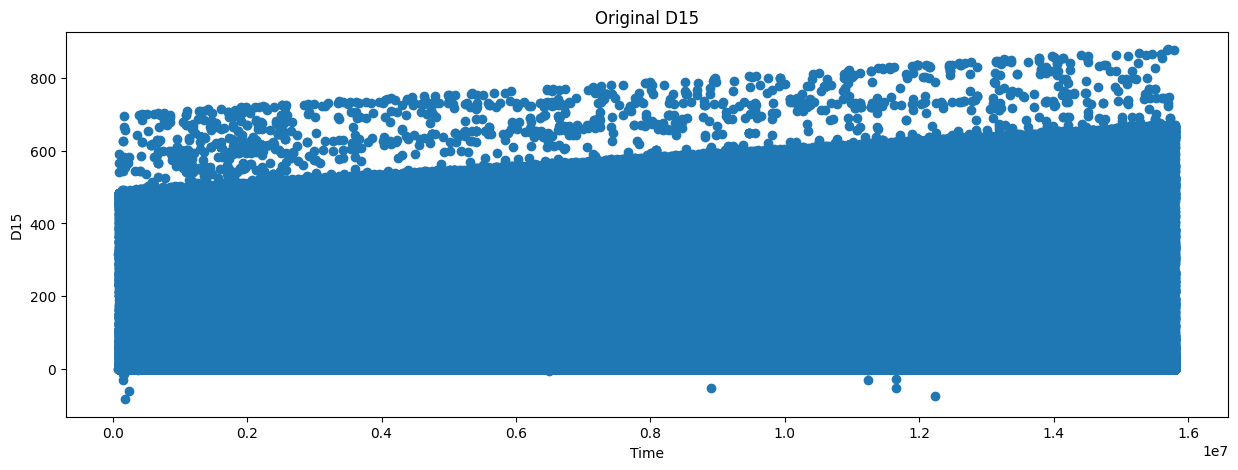

In [88]:
# PLOT ORIGINAL D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Original D15')
plt.xlabel('Time')
plt.ylabel('D15')
plt.show()

In [89]:
# NORMALIZE D COLUMNS
for i in range(1,16):
    if i in [1,2,3,5,9]: continue
    X_train['D'+str(i)] =  X_train['D'+str(i)] - X_train.TransactionDT/np.float32(24*60*60)
    X_test['D'+str(i)] = X_test['D'+str(i)] - X_test.TransactionDT/np.float32(24*60*60)

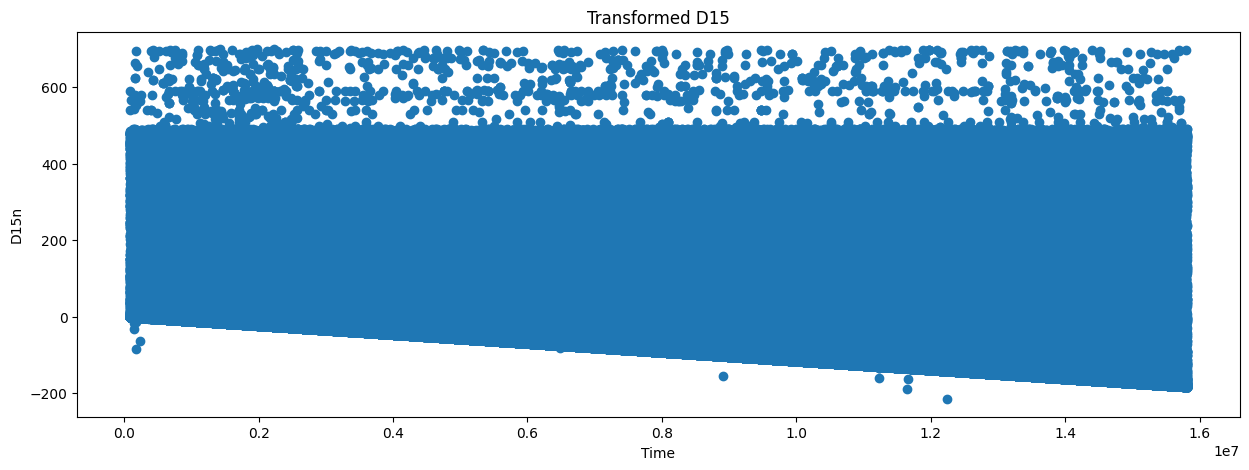

In [90]:
# PLOT TRANSFORMED D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Transformed D15')
plt.xlabel('Time')
plt.ylabel('D15n')
plt.show()

# Encoding Functions

In [91]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')
        
# LABEL ENCODE
def encode_LE(col,train=X_train,test=X_test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')
        
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)
                
                print("'"+new_col_name+"'",', ',end='')
                
# COMBINE FEATURES
def encode_CB(col1,col2,df1=X_train,df2=X_test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
    for main_column in main_columns:  
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

# Feature Engineering

In [92]:
%%time
# TRANSACTION AMT CENTS
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
encode_FE(X_train,X_test,['addr1','card1','card2','card3','P_emaildomain'])
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
# FREQUENCY ENOCDE
encode_FE(X_train,X_test,['card1_addr1','card1_addr1_P_emaildomain'])
# GROUP AGGREGATE
encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

cents, addr1_FE , card1_FE , card2_FE , card3_FE , P_emaildomain_FE , card1_addr1 , card1_addr1_P_emaildomain , card1_addr1_FE , card1_addr1_P_emaildomain_FE , 'TransactionAmt_card1_mean' , 'TransactionAmt_card1_std' , 'TransactionAmt_card1_addr1_mean' , 'TransactionAmt_card1_addr1_std' , 'TransactionAmt_card1_addr1_P_emaildomain_mean' , 'TransactionAmt_card1_addr1_P_emaildomain_std' , 'D9_card1_mean' , 'D9_card1_std' , 'D9_card1_addr1_mean' , 'D9_card1_addr1_std' , 'D9_card1_addr1_P_emaildomain_mean' , 'D9_card1_addr1_P_emaildomain_std' , 'D11_card1_mean' , 'D11_card1_std' , 'D11_card1_addr1_mean' , 'D11_card1_addr1_std' , 'D11_card1_addr1_P_emaildomain_mean' , 'D11_card1_addr1_P_emaildomain_std' , CPU times: total: 7.09 s
Wall time: 7.92 s


# Feature Selection - Time Consistency

In [93]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
    
# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [94]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

NOW USING THE FOLLOWING 216 FEATURES.


array(['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card5',
       'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain',
       'R_emaildomain', 'C1', 'C2', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9',
       'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5',
       'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'M7', 'M8',
       'M9', 'V1', 'V3', 'V4', 'V6', 'V8', 'V11', 'V13', 'V14', 'V17',
       'V20', 'V23', 'V26', 'V27', 'V30', 'V36', 'V37', 'V40', 'V41',
       'V44', 'V47', 'V48', 'V54', 'V56', 'V59', 'V62', 'V65', 'V67',
       'V68', 'V70', 'V76', 'V78', 'V80', 'V82', 'V86', 'V88', 'V89',
       'V91', 'V107', 'V108', 'V111', 'V115', 'V117', 'V120', 'V121',
       'V123', 'V124', 'V127', 'V129', 'V130', 'V136', 'V138', 'V139',
       'V142', 'V147', 'V156', 'V160', 'V162', 'V165', 'V166', 'V169',
       'V171', 'V173', 'V175', 'V176', 'V178', 'V180', 'V182', 'V185',
       'V187', 'V188', 'V198', 'V203', 'V205', 'V207', 'V209', 'V210',
       '

# Local Validation

In [ ]:
#  TRAIN 75% PREDICT 25%
idxT = X_train.index[:3*len(X_train)//4]
idxV = X_train.index[3*len(X_train)//4:]

# TRAIN 4 SKIP 1 PREDICT 1 MONTH
#idxT = X_train.index[:417559]
#idxV = X_train.index[-89326:]

In [88]:
pip install xgboost-gpu

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement xgboost-gpu (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for xgboost-gpu


## The Magic Feature - UID

In [99]:
X_train['day'] = X_train.TransactionDT / (24*60*60)
X_train['uid'] = X_train.card1_addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)

X_test['day'] = X_test.TransactionDT / (24*60*60)
X_test['uid'] = X_test.card1_addr1.astype(str)+'_'+np.floor(X_test.day-X_test.D1).astype(str)

## Group Aggregation Features

In [ ]:
%%time

# FREQUENCY ENCODE UID
encode_FE(X_train,X_test,['uid'])
# AGGREGATE 
encode_AG(['TransactionAmt','D4','D9','D10','D15'],['uid'],['mean','std'],fillna=True,usena=True)
# AGGREGATE
encode_AG(['C'+str(x) for x in range(1,15) if x!=3],['uid'],['mean'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE
encode_AG(['M'+str(x) for x in range(1,10)],['uid'],['mean'],fillna=True,usena=True)
# AGGREGATE
encode_AG2(['P_emaildomain','dist1','DT_M','id_02','cents'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREGATE
encode_AG(['C14'],['uid'],['std'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE 
encode_AG2(['C13','V314'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREATE 
encode_AG2(['V127','V136','V309','V307','V320'], ['uid'], train_df=X_train, test_df=X_test)
# NEW FEATURE
X_train['outsider15'] = (np.abs(X_train.D1-X_train.D15)>3).astype('int8')
X_test['outsider15'] = (np.abs(X_test.D1-X_test.D15)>3).astype('int8')
print('outsider15')

In [ ]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
for c in ['oof','DT_M','day','uid']:
    cols.remove(c)
    
# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [ ]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

## Local Validation

In [ ]:
# CHRIS - TRAIN 75% PREDICT 25%
idxT = X_train.index[:3*len(X_train)//4]
idxV = X_train.index[3*len(X_train)//4:]

# KONSTANTIN - TRAIN 4 SKIP 1 PREDICT 1 MONTH
#idxT = X_train.index[:417559]
#idxV = X_train.index[-89326:]

In [ ]:
if BUILD96:
    clf = xgb.XGBClassifier( 
        n_estimators=2000,
        max_depth=12, 
        learning_rate=0.02, 
        subsample=0.8,
        colsample_bytree=0.4, 
        missing=-1, 
        eval_metric='auc',
        #nthread=4,
        #tree_method='hist' 
        tree_method='gpu_hist' 
    )
    h = clf.fit(X_train.loc[idxT,cols], y_train[idxT], 
        eval_set=[(X_train.loc[idxV,cols],y_train[idxV])],
        verbose=50, early_stopping_rounds=100)

In [ ]:
if BUILD96:

    feature_imp = pd.DataFrame(sorted(zip(clf.feature_importances_,cols)), columns=['Value','Feature'])

    plt.figure(figsize=(20, 10))
    sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).iloc[:50])
    plt.title('XGB96 Most Important')
    plt.tight_layout()
    plt.show()
        
    del clf, h; x=gc.collect()

## NN Model

In [ ]:
import numpy as np 
import pandas as pd 

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import precision_score, recall_score, confusion_matrix, accuracy_score, roc_auc_score, f1_score, roc_curve, auc, precision_recall_curve, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

import itertools
from numpy import interp
from copy import deepcopy

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib import rcParams

from keras.layers import Concatenate, Input, Dense, Embedding, Flatten, Dropout, BatchNormalization, SpatialDropout1D
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras.models import Model
from keras.optimizers import Adam
import keras.backend as k

In [ ]:
%%time
# CONFIGURE PATHS
train_transaction = pd.read_csv('datasets/ieee dataset/train_transaction.csv', index_col='TransactionID')
test_transaction = pd.read_csv('datasets/ieee dataset/test_transaction.csv', index_col='TransactionID')
train_identity = pd.read_csv('datasets/ieee dataset/train_identity.csv', index_col='TransactionID')
test_identity = pd.read_csv('datasets/ieee dataset/test_identity.csv', index_col='TransactionID')

In [ ]:
train_df = train_transaction.merge(train_identity, how='left', left_index=True, right_index=True)
test_df = test_transaction.merge(test_identity, how='left', left_index=True, right_index=True)

print("Train shape : " + str(train_df.shape))
print("Test shape  : " + str(test_df.shape))

In [ ]:
train_df = train_df.drop(["TransactionDT"], axis=1)
test_df = test_df.drop(["TransactionDT"], axis=1)

train_df = train_df.reset_index()
test_df = test_df.reset_index()

train_df['nulls1'] = train_df.isna().sum(axis=1)
test_df['nulls1'] = test_df.isna().sum(axis=1)

train_df = train_df.iloc[:, :55]
test_df = test_df.iloc[:, :54]

del train_transaction, train_identity, test_transaction, test_identity

In [ ]:
emails = {'gmail': 'google', 'att.net': 'att', 'twc.com': 'spectrum', 'scranton.edu': 'other', 'optonline.net': 'other', 'hotmail.co.uk': 'microsoft', 'comcast.net': 'other', 'yahoo.com.mx': 'yahoo', 'yahoo.fr': 'yahoo', 'yahoo.es': 'yahoo', 'charter.net': 'spectrum', 'live.com': 'microsoft', 'aim.com': 'aol', 'hotmail.de': 'microsoft', 'centurylink.net': 'centurylink', 'gmail.com': 'google', 'me.com': 'apple', 'earthlink.net': 'other', 'gmx.de': 'other', 'web.de': 'other', 'cfl.rr.com': 'other', 'hotmail.com': 'microsoft', 'protonmail.com': 'other', 'hotmail.fr': 'microsoft', 'windstream.net': 'other', 'outlook.es': 'microsoft', 'yahoo.co.jp': 'yahoo', 'yahoo.de': 'yahoo', 'servicios-ta.com': 'other', 'netzero.net': 'other', 'suddenlink.net': 'other', 'roadrunner.com': 'other', 'sc.rr.com': 'other', 'live.fr': 'microsoft', 'verizon.net': 'yahoo', 'msn.com': 'microsoft', 'q.com': 'centurylink', 'prodigy.net.mx': 'att', 'frontier.com': 'yahoo', 'anonymous.com': 'other', 'rocketmail.com': 'yahoo', 'sbcglobal.net': 'att', 'frontiernet.net': 'yahoo', 'ymail.com': 'yahoo', 'outlook.com': 'microsoft', 'mail.com': 'other', 'bellsouth.net': 'other', 'embarqmail.com': 'centurylink', 'cableone.net': 'other', 'hotmail.es': 'microsoft', 'mac.com': 'apple', 'yahoo.co.uk': 'yahoo', 'netzero.com': 'other', 'yahoo.com': 'yahoo', 'live.com.mx': 'microsoft', 'ptd.net': 'other', 'cox.net': 'other', 'aol.com': 'aol', 'juno.com': 'other', 'icloud.com': 'apple'}

us_emails = ['gmail', 'net', 'edu']

for c in ['P_emaildomain', 'R_emaildomain']:
    train_df[c + '_bin'] = train_df[c].map(emails)
    test_df[c + '_bin'] = test_df[c].map(emails)
    
    train_df[c + '_suffix'] = train_df[c].map(lambda x: str(x).split('.')[-1])
    test_df[c + '_suffix'] = test_df[c].map(lambda x: str(x).split('.')[-1])
    
    train_df[c + '_suffix'] = train_df[c + '_suffix'].map(lambda x: x if str(x) not in us_emails else 'us')
    test_df[c + '_suffix'] = test_df[c + '_suffix'].map(lambda x: x if str(x) not in us_emails else 'us')

In [ ]:
for c1, c2 in train_df.dtypes.reset_index().values:
    if c2 == 'O':
        train_df[c1] = train_df[c1].map(lambda x: str(x).lower())
        test_df[c1] = test_df[c1].map(lambda x: str(x).lower())

In [ ]:
numerical = ["TransactionAmt", "nulls1", "dist1", "dist2"] + ["C" + str(i) for i in range(1, 15)] + \
            ["D" + str(i) for i in range(1, 16)] + \
            ["V" + str(i) for i in range(1, 340)]

categorical = ["ProductCD", "card1", "card2", "card3", "card4", "card5", "card6", "addr1", "addr2",
               "P_emaildomain_bin", "P_emaildomain_suffix", "R_emaildomain_bin", "R_emaildomain_suffix",
               "P_emaildomain", "R_emaildomain",
              "DeviceInfo", "DeviceType"] + ["id_0" + str(i) for i in range(1, 10)] +\
                ["id_" + str(i) for i in range(10, 39)] + \
                 ["M" + str(i) for i in range(1, 10)]

numerical = [col for col in numerical if col in train_df.columns]
categorical = [col for col in categorical if col in train_df.columns]

categorical_save = deepcopy(categorical)
numerical_save = deepcopy(numerical)

In [ ]:
def nan2mean(df):
    for x in list(df.columns.values):
        if x in numerical:
            df[x] = df[x].fillna(0)
    return df

train_df = nan2mean(train_df)
test_df = nan2mean(test_df)

In [ ]:
category_counts = {}
for f in categorical:
    train_df[f] = train_df[f].replace("nan", "other")
    train_df[f] = train_df[f].replace(np.nan, "other")
    test_df[f] = test_df[f].replace("nan", "other")
    test_df[f] = test_df[f].replace(np.nan, "other")
    
    lbl = preprocessing.LabelEncoder()
    lbl.fit(list(train_df[f].values) + list(test_df[f].values))
    train_df[f] = lbl.transform(list(train_df[f].values))
    test_df[f] = lbl.transform(list(test_df[f].values))
    category_counts[f] = len(list(lbl.classes_)) + 1

In [ ]:
for column in numerical:
    scaler = StandardScaler()
    if train_df[column].max() > 100 and train_df[column].min() >= 0:
        train_df[column] = np.log1p(train_df[column])
        test_df[column] = np.log1p(test_df[column])
    scaler.fit(np.concatenate([train_df[column].values.reshape(-1,1), test_df[column].values.reshape(-1,1)]))
    train_df[column] = scaler.transform(train_df[column].values.reshape(-1,1))
    test_df[column] = scaler.transform(test_df[column].values.reshape(-1,1))

In [ ]:
target = 'isFraud'

# Split train data into train and validation
tr_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, shuffle=False)

print(f"Training set shape: {tr_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"\nClass distribution in training:")
print(f"  Class 0: {(tr_df[target] == 0).sum()}")
print(f"  Class 1: {(tr_df[target] == 1).sum()}")
print(f"  Ratio: {(tr_df[target] == 0).sum() / (tr_df[target] == 1).sum():.1f}:1")

In [ ]:
def get_input_features(df):
    X = {'numerical': np.array(df[numerical])}
    for cat in categorical:
        X[cat] = np.array(df[cat])
    return X

In [ ]:
def make_model():
    k.clear_session()

    categorical_inputs = []
    for cat in categorical:
        categorical_inputs.append(Input(shape=[1], name=cat))

    categorical_embeddings = []
    for i, cat in enumerate(categorical):
        categorical_embeddings.append(
            Embedding(category_counts[cat], int(np.log1p(category_counts[cat]) + 1), name=cat + "_embed")(categorical_inputs[i]))

    categorical_logits = Concatenate(name="categorical_conc")([Flatten()(SpatialDropout1D(.1)(cat_emb)) for cat_emb in categorical_embeddings])

    numerical_inputs = Input(shape=[len(numerical)], name='numerical')
    numerical_logits = Dropout(.1)(numerical_inputs)
  
    x = Concatenate()([
        categorical_logits, 
        numerical_logits,
    ])
    
    x = Dense(200, activation='relu')(x)
    x = Dropout(.2)(x)
    x = Dense(100, activation='relu')(x)
    x = Dropout(.2)(x)
    out = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=categorical_inputs + [numerical_inputs], outputs=out)
    loss = "binary_crossentropy"
    model.compile(optimizer=Adam(learning_rate=0.01), loss=loss)
    
    return model

# Print category counts for reference
print("Category counts:")
for cat, count in list(category_counts.items())[:10]:  # Show first 10
    print(f"  {cat}: {count}")

In [ ]:
print("Calculating class weights to handle imbalance...")
X_train_temp = get_input_features(tr_df)
y_train_temp = tr_df[target]

# Convert classes to numpy array
classes = np.unique(y_train_temp)  # Get unique classes automatically
# Or if you know the classes are [0, 1], use: classes = np.array([0, 1])

class_weights = compute_class_weight('balanced', classes=classes, y=y_train_temp)
class_weight_dict = {classes[0]: class_weights[0], classes[1]: class_weights[1]}

print(f"Class weights: {class_weight_dict}")
print(f"\nTraining set class distribution:")
print(f"  Class 0: {np.sum(y_train_temp == 0)}")
print(f"  Class 1: {np.sum(y_train_temp == 1)}")
print(f"  Ratio: {np.sum(y_train_temp == 0) / np.sum(y_train_temp == 1):.1f}:1")

In [ ]:
print("="*60)
print("STARTING GREEDY FEATURE SELECTION (CATEGORICAL)")
print("="*60)

best_score = 0
drop_cats = []

# Reset to original categorical features
categorical = deepcopy(categorical_save)

for category_test in categorical_save:
    categorical = [cat for cat in categorical_save if cat not in drop_cats]
    if category_test in categorical:
        categorical.remove(category_test)
    
    print(f"\nTesting without: {category_test}")
    print(f"Remaining features: {len(categorical)}")
    
    # Get input features with current feature set
    X_train = get_input_features(tr_df)
    X_valid = get_input_features(val_df)
    y_train = tr_df[target]
    y_valid = val_df[target]
    
    model = make_model()
    local_score = 0
    patience = 0
    
    # Train for a few epochs
    for i in range(10):  # Reduced from 100 for speed
        if patience < 3:
            hist = model.fit(X_train, y_train, 
                           validation_data=(X_valid, y_valid), 
                           batch_size=8000, 
                           epochs=1, 
                           verbose=0,
                           class_weight=class_weight_dict)
            
            valid_preds = model.predict(X_valid, batch_size=8000, verbose=False)
            score = roc_auc_score(y_valid, valid_preds)
            
            if score > local_score:
                model.save_weights("temp_model.weights.h5")
                local_score = score
                patience = 0
            else:
                patience += 1
        else:
            break
    
    # Compare with best score
    if local_score > best_score:
        drop_cats.append(category_test)
        print(f"✓ Performance INCREASED to {local_score:.4f} from {best_score:.4f}")
        print(f"  Dropping {category_test}")
        best_score = local_score
    else:
        print(f"✗ Performance DECREASED to {local_score:.4f} from {best_score:.4f}")
        print(f"  Keeping {category_test}")

print(f"\nFinal dropped categorical features: {drop_cats}")
print(f"Best ROC AUC during selection: {best_score:.4f}")

In [ ]:
print("="*60)
print("STARTING GREEDY FEATURE SELECTION (NUMERICAL)")
print("="*60)

# Update categorical with selected features
categorical = [cat for cat in categorical_save if cat not in drop_cats]

# Reset numerical to original
numerical = deepcopy(numerical_save)
drop_nums = []

for numerical_test in numerical_save:
    numerical = [num for num in numerical_save if num not in drop_nums]
    if numerical_test in numerical:
        numerical.remove(numerical_test)
    
    print(f"\nTesting without: {numerical_test}")
    print(f"Remaining features: {len(numerical)}")
    
    # Get input features with current feature set
    X_train = get_input_features(tr_df)
    X_valid = get_input_features(val_df)
    y_train = tr_df[target]
    y_valid = val_df[target]
    
    model = make_model()
    local_score = 0
    patience = 0
    
    # Train for a few epochs
    for i in range(10):  # Reduced from 100 for speed
        if patience < 3:
            hist = model.fit(X_train, y_train, 
                           validation_data=(X_valid, y_valid), 
                           batch_size=8000, 
                           epochs=1, 
                           verbose=0,
                           class_weight=class_weight_dict)
            
            valid_preds = model.predict(X_valid, batch_size=8000, verbose=False)
            score = roc_auc_score(y_valid, valid_preds)
            
            if score > local_score:
                model.save_weights("temp_model.weights.h5")
                local_score = score
                patience = 0
            else:
                patience += 1
        else:
            break
    
    # Compare with best score
    if local_score > best_score:
        drop_nums.append(numerical_test)
        print(f"✓ Performance INCREASED to {local_score:.4f} from {best_score:.4f}")
        print(f"  Dropping {numerical_test}")
        best_score = local_score
    else:
        print(f"✗ Performance DECREASED to {local_score:.4f} from {best_score:.4f}")
        print(f"  Keeping {numerical_test}")

print(f"\nFinal dropped numerical features: {drop_nums}")
print(f"Best ROC AUC during selection: {best_score:.4f}")

In [ ]:
print("="*60)
print("FINAL FEATURE SETS")
print("="*60)

categorical = [cat for cat in categorical_save if cat not in drop_cats]
numerical = [num for num in numerical_save if num not in drop_nums]

print(f"Selected categorical features ({len(categorical)}):")
for i, cat in enumerate(categorical[:20]):  # Show first 20
    print(f"  {cat}")
if len(categorical) > 20:
    print(f"  ... and {len(categorical) - 20} more")

print(f"\nSelected numerical features ({len(numerical)}):")
for i, num in enumerate(numerical[:20]):  # Show first 20
    print(f"  {num}")
if len(numerical) > 20:
    print(f"  ... and {len(numerical) - 20} more")

print(f"\nTotal features: {len(categorical) + len(numerical)}")
print(f"Dropped {len(drop_cats)} categorical and {len(drop_nums)} numerical features")

In [ ]:
print("="*60)
print("FINAL MODEL TRAINING")
print("="*60)

# Prepare final training data
X_train = get_input_features(tr_df)
X_valid = get_input_features(val_df)
y_train = tr_df[target]
y_valid = val_df[target]

# Create and train final model
model = make_model()

best_score = 0
patience = 0

# Lists to track metrics
train_losses = []
val_losses = []
roc_scores = []

print("\nStarting training...")

for i in range(50):  # Train for up to 50 epochs
    if patience < 5:
        # Train with class weights
        hist = model.fit(
            X_train, y_train, 
            validation_data=(X_valid, y_valid), 
            batch_size=8000, 
            epochs=1, 
            verbose=1,
            class_weight=class_weight_dict
        )
        
        # Track losses
        train_losses.append(hist.history['loss'][0])
        val_losses.append(hist.history['val_loss'][0])
        
        # Get predictions and calculate ROC AUC
        valid_preds = model.predict(X_valid, batch_size=8000, verbose=False)
        score = roc_auc_score(y_valid, valid_preds)
        roc_scores.append(score)
        
        print(f"Epoch {i+1}: Train Loss={hist.history['loss'][0]:.4f}, "
              f"Val Loss={hist.history['val_loss'][0]:.4f}, ROC AUC={score:.4f}")
        
        if score > best_score:
            model.save_weights("best_model.weights.h5")
            best_score = score
            patience = 0
            print(f"  ✓ New best model saved! ROC AUC: {score:.4f}")
        else:
            patience += 1
            print(f"  Patience counter: {patience}/5")
    else:
        print(f"\nEarly stopping triggered after {i+1} epochs")
        break

# Load the best model
model.load_weights("best_model.weights.h5")
print(f"\nBest ROC AUC achieved: {best_score:.4f}")

# Get final predictions
valid_preds = model.predict(X_valid, batch_size=8000, verbose=False)

In [ ]:
print("="*60)
print("MODEL EVALUATION ON VALIDATION SET")
print("="*60)

# Evaluate with threshold 0.5 (default)
print("\n--- Evaluation with threshold 0.5 ---")
valid_preds_binary_05 = (valid_preds > 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_valid, valid_preds_binary_05))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, valid_preds_binary_05))

# Evaluate with threshold 0.3
print("\n--- Evaluation with threshold 0.3 ---")
valid_preds_binary_03 = (valid_preds > 0.3).astype(int)
print("Classification Report:")
print(classification_report(y_valid, valid_preds_binary_03))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, valid_preds_binary_03))

# Find optimal threshold using Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_valid, valid_preds)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx]

print(f"\n--- Optimal threshold (Youden's J): {optimal_threshold:.4f} ---")
valid_preds_binary_optimal = (valid_preds > optimal_threshold).astype(int)
print("Classification Report:")
print(classification_report(y_valid, valid_preds_binary_optimal))
print("\nConfusion Matrix:")
print(confusion_matrix(y_valid, valid_preds_binary_optimal))

# Calculate comprehensive metrics
print("\n" + "="*60)
print("COMPREHENSIVE METRICS")
print("="*60)

for threshold_name, preds_binary in [("0.5", valid_preds_binary_05), 
                                     ("0.3", valid_preds_binary_03),
                                     ("Optimal", valid_preds_binary_optimal)]:
    accuracy = accuracy_score(y_valid, preds_binary)
    precision = precision_score(y_valid, preds_binary)
    recall = recall_score(y_valid, preds_binary)
    f1 = f1_score(y_valid, preds_binary)
    
    print(f"\nThreshold {threshold_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")

# Calculate PR AUC
precision_vals, recall_vals, _ = precision_recall_curve(y_valid, valid_preds)
pr_auc = auc(recall_vals, precision_vals)
print(f"\nPrecision-Recall AUC: {pr_auc:.4f}")

# ROC AUC
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

In [ ]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1: Training and Validation Loss
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0, 0].set_title('Training History - Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: ROC AUC Score over epochs
if roc_scores:
    axes[0, 1].plot(roc_scores, label='ROC AUC', color='green', linewidth=2)
    axes[0, 1].axhline(y=best_score, color='r', linestyle='--', alpha=0.7, label=f'Best: {best_score:.4f}')
    axes[0, 1].set_title('Validation ROC AUC', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('ROC AUC')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    if len(roc_scores) > 1:
        axes[0, 1].set_ylim([min(roc_scores)-0.02, max(max(roc_scores)+0.02, 0.98)])

# Plot 3: ROC Curve
axes[0, 2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('False Positive Rate')
axes[0, 2].set_ylabel('True Positive Rate')
axes[0, 2].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 2].legend(loc="lower right")
axes[0, 2].grid(True, alpha=0.3)

# Plot 4: Precision-Recall Curve
axes[1, 0].plot(recall_vals, precision_vals, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[1, 0].legend(loc="upper right")
axes[1, 0].grid(True, alpha=0.3)

# Plot 5: Confusion Matrix (with optimal threshold)
cm = confusion_matrix(y_valid, valid_preds_binary_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
axes[1, 1].set_title(f'Confusion Matrix (Threshold={optimal_threshold:.2f})', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('True Label')
axes[1, 1].set_xlabel('Predicted Label')

# Plot 6: Prediction Distribution
axes[1, 2].hist(valid_preds[y_valid == 0], bins=50, alpha=0.7, label='Non-Fraud', density=True)
axes[1, 2].hist(valid_preds[y_valid == 1], bins=50, alpha=0.7, label='Fraud', density=True)
axes[1, 2].axvline(x=optimal_threshold, color='r', linestyle='--', label=f'Optimal Threshold={optimal_threshold:.2f}')
axes[1, 2].axvline(x=0.3, color='g', linestyle=':', label='Threshold=0.3')
axes[1, 2].axvline(x=0.5, color='orange', linestyle=':', label='Threshold=0.5')
axes[1, 2].set_title('Prediction Score Distribution', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Prediction Score')
axes[1, 2].set_ylabel('Density')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("="*60)
print("GENERATING TEST SET PREDICTIONS")
print("="*60)

# Get test predictions
X_test = get_input_features(test_df)
test_preds = model.predict(X_test, batch_size=8000, verbose=True)

# Save predictions
test_df['isFraud_pred'] = test_preds
test_df[['isFraud_pred']].to_csv('test_predictions.csv')
print("Test predictions saved to 'test_predictions.csv'")

# Summary statistics
print("\nPrediction Statistics:")
print(f"Mean prediction: {test_preds.mean():.4f}")
print(f"Std prediction: {test_preds.std():.4f}")
print(f"Min prediction: {test_preds.min():.4f}")
print(f"Max prediction: {test_preds.max():.4f}")
print(f"Predictions > 0.5: {np.sum(test_preds > 0.5)} / {len(test_preds)} ({np.sum(test_preds > 0.5)/len(test_preds)*100:.2f}%)")
print(f"Predictions > 0.3: {np.sum(test_preds > 0.3)} / {len(test_preds)} ({np.sum(test_preds > 0.3)/len(test_preds)*100:.2f}%)")
print(f"Predictions > 0.1: {np.sum(test_preds > 0.1)} / {len(test_preds)} ({np.sum(test_preds > 0.1)/len(test_preds)*100:.2f}%)")

print("\n" + "="*60)
print("TRAINING AND EVALUATION COMPLETE")
print("="*60)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                           precision_recall_curve, roc_curve, auc,
                           average_precision_score, classification_report,
                           confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
def train_optimized_model(X_train, y_train, X_val, y_val, 
                          model_func=make_model,
                          threshold_search_range=np.arange(0.1, 0.9, 0.05),
                          target_recall=None,
                          n_epochs=50,
                          patience=5,
                          batch_size=8000):
    """
    Train model with class weights and optimize for PR AUC/recall
    """
    
    # ====================
    # A. Handle Class Imbalance
    # ====================
    print("="*70)
    print("HANDLING CLASS IMBALANCE")
    print("="*70)
    
    # Calculate class weights
    class_counts = np.bincount(y_train.astype(int))
    total_samples = len(y_train)
    n_classes = len(class_counts)
    
    # Method 1: Inverse of class frequency
    ##class_weights = total_samples / (n_classes * class_counts)
    ##class_weight_dict = dict(enumerate(class_weights))
    
    # Method 2: 'balanced' weights from sklearn
    sklearn_weights = compute_class_weight('balanced', classes=[0, 1], y=y_train)
    sklearn_weight_dict = {0: sklearn_weights[0], 1: sklearn_weights[1]}
    
    print(f"Original class distribution: {class_counts}")
    print(f"Class ratio (0:1): {class_counts[0]/class_counts[1]:.1f}:1")
    print(f"Custom class weights: {class_weight_dict}")
    print(f"Sklearn balanced weights: {sklearn_weight_dict}")
    
    # Use the more aggressive weighting
    final_class_weight = sklearn_weight_dict
    print(f"Using weights: {final_class_weight}")
    
    # ====================
    # B. Create and Train Model with Callbacks
    # ====================
    print("\n" + "="*70)
    print("TRAINING MODEL WITH CALLBACKS")
    print("="*70)
    
    model = model_func()
    
    # Add callbacks for better training
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience//2,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    # Track metrics during training
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=final_class_weight,
        verbose=1
    )
    
    # ====================
    # C. Optimize Decision Threshold
    # ====================
    print("\n" + "="*70)
    print("OPTIMIZING DECISION THRESHOLD")
    print("="*70)
    
    # Get predictions on validation set
    y_pred_proba = model.predict(X_val, batch_size=batch_size, verbose=0).flatten()
    
    # Try different thresholds and evaluate
    threshold_results = []
    for threshold in threshold_search_range:
        y_pred = (y_pred_proba >= threshold).astype(int)
        
        # Calculate metrics
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        
        # F-beta score (emphasizing recall)
        beta = 2  # Beta > 1 gives more weight to recall
        if precision + recall > 0:
            f_beta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)
        else:
            f_beta = 0
        
        # Business cost metric (example: cost of missing fraud is 10x cost of false alarm)
        false_negatives = np.sum((y_val == 1) & (y_pred == 0))
        false_positives = np.sum((y_val == 0) & (y_pred == 1))
        business_cost = false_negatives * 10 + false_positives * 1
        
        threshold_results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'f_beta': f_beta,
            'business_cost': business_cost,
            'false_positives': false_positives,
            'false_negatives': false_negatives
        })
    
    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(threshold_results)
    
    # Find optimal thresholds for different objectives
    optimal_thresholds = {
        'max_f1': results_df.loc[results_df['f1'].idxmax()],
        'max_recall': results_df.loc[results_df['recall'].idxmax()],
        'max_f_beta': results_df.loc[results_df['f_beta'].idxmax()],
        'min_business_cost': results_df.loc[results_df['business_cost'].idxmin()],
    }
    
    # If target recall is specified, find threshold that achieves it
    if target_recall is not None:
        # Find threshold that gives at least target recall with best precision
        valid_results = results_df[results_df['recall'] >= target_recall]
        if len(valid_results) > 0:
            optimal_target_recall = valid_results.loc[valid_results['precision'].idxmax()]
            optimal_thresholds['target_recall'] = optimal_target_recall
            print(f"\nThreshold for target recall {target_recall}: {optimal_target_recall['threshold']:.3f}")
            print(f"  → Precision: {optimal_target_recall['precision']:.3f}, Recall: {optimal_target_recall['recall']:.3f}")
    
    # ====================
    # D. Comprehensive Evaluation
    # ====================
    print("\n" + "="*70)
    print("COMPREHENSIVE EVALUATION")
    print("="*70)
    
    # Calculate PR AUC and ROC AUC
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_val, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    average_precision = average_precision_score(y_val, y_pred_proba)
    
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    print(f"PR AUC: {pr_auc:.4f}")
    print(f"Average Precision: {average_precision:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    
    # Evaluate with default threshold (0.5)
    print("\n--- Default Threshold (0.5) ---")
    y_pred_default = (y_pred_proba >= 0.5).astype(int)
    print(classification_report(y_val, y_pred_default))
    
    # Let user choose threshold strategy
    print("\n" + "="*70)
    print("THRESHOLD SELECTION OPTIONS")
    print("="*70)
    for strategy, result in optimal_thresholds.items():
        if isinstance(result, pd.Series):
            print(f"\n{strategy.replace('_', ' ').title()}:")
            print(f"  Threshold: {result['threshold']:.3f}")
            print(f"  Precision: {result['precision']:.3f}")
            print(f"  Recall:    {result['recall']:.3f}")
            print(f"  F1-Score:  {result['f1']:.3f}")
            print(f"  F-Beta:    {result['f_beta']:.3f}")
            print(f"  Business Cost: {result['business_cost']:.0f}")
    
    # ====================
    # E. Visualization
    # ====================
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)
    
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Training History
    ax1 = plt.subplot(3, 4, 1)
    ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_title('Training History - Loss', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curve
    ax2 = plt.subplot(3, 4, 2)
    ax2.plot(recall_curve, precision_curve, 'b-', linewidth=2, 
             label=f'PR Curve (AUC = {pr_auc:.3f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best')
    
    # 3. ROC Curve
    ax3 = plt.subplot(3, 4, 3)
    ax3.plot(fpr, tpr, 'b-', linewidth=2, 
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'r--', alpha=0.5)
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='best')
    
    # 4. Threshold Analysis
    ax4 = plt.subplot(3, 4, 4)
    ax4.plot(results_df['threshold'], results_df['precision'], 
             'b-', label='Precision', linewidth=2)
    ax4.plot(results_df['threshold'], results_df['recall'], 
             'g-', label='Recall', linewidth=2)
    ax4.plot(results_df['threshold'], results_df['f1'], 
             'r-', label='F1-Score', linewidth=2)
    ax4.plot(results_df['threshold'], results_df['f_beta'], 
             'm-', label='F-Beta (β=2)', linewidth=2)
    
    # Mark optimal points
    for strategy, result in optimal_thresholds.items():
        if isinstance(result, pd.Series):
            color_map = {
                'max_f1': 'red',
                'max_recall': 'green',
                'max_f_beta': 'magenta',
                'min_business_cost': 'orange',
                'target_recall': 'blue'
            }
            color = color_map.get(strategy, 'black')
            ax4.scatter(result['threshold'], result['f1'], 
                       color=color, s=100, zorder=5,
                       label=f'{strategy.replace("_", " ").title()}')
    
    ax4.set_xlabel('Threshold')
    ax4.set_ylabel('Score')
    ax4.set_title('Threshold Analysis', fontsize=12, fontweight='bold')
    ax4.legend(loc='best')
    ax4.grid(True, alpha=0.3)
    
    # 5. Business Cost Analysis
    ax5 = plt.subplot(3, 4, 5)
    ax5.plot(results_df['threshold'], results_df['business_cost'], 
             'b-', linewidth=2)
    ax5.set_xlabel('Threshold')
    ax5.set_ylabel('Business Cost')
    ax5.set_title('Business Cost vs Threshold', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # Mark minimum cost
    min_cost_idx = results_df['business_cost'].idxmin()
    ax5.scatter(results_df.loc[min_cost_idx, 'threshold'],
               results_df.loc[min_cost_idx, 'business_cost'],
               color='red', s=100, zorder=5,
               label=f'Min Cost (Threshold={results_df.loc[min_cost_idx, "threshold"]:.3f})')
    ax5.legend()
    
    # 6. Confusion Matrix for Best F-Beta
    ax6 = plt.subplot(3, 4, 6)
    best_f_beta_threshold = optimal_thresholds['max_f_beta']['threshold']
    y_pred_best = (y_pred_proba >= best_f_beta_threshold).astype(int)
    cm = confusion_matrix(y_val, y_pred_best)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
                cbar_kws={'label': 'Count'})
    ax6.set_title(f'Confusion Matrix (Threshold={best_f_beta_threshold:.3f})', 
                  fontsize=12, fontweight='bold')
    ax6.set_ylabel('True Label')
    ax6.set_xlabel('Predicted Label')
    
    # 7. Prediction Distribution
    ax7 = plt.subplot(3, 4, 7)
    bins = np.linspace(0, 1, 50)
    ax7.hist(y_pred_proba[y_val == 0], bins=bins, alpha=0.7, 
             label='Non-Fraud', density=True, color='blue')
    ax7.hist(y_pred_proba[y_val == 1], bins=bins, alpha=0.7, 
             label='Fraud', density=True, color='red')
    
    # Add threshold lines
    for strategy, result in optimal_thresholds.items():
        if isinstance(result, pd.Series):
            colors = {'max_f1': 'red', 'max_recall': 'green', 
                     'max_f_beta': 'magenta', 'min_business_cost': 'orange'}
            color = colors.get(strategy, 'black')
            ax7.axvline(x=result['threshold'], color=color, linestyle='--', 
                       alpha=0.7, label=f'{strategy} ({result["threshold"]:.3f})')
    
    ax7.set_xlabel('Prediction Probability')
    ax7.set_ylabel('Density')
    ax7.set_title('Prediction Distribution by True Class', fontsize=12, fontweight='bold')
    ax7.legend(loc='best')
    ax7.grid(True, alpha=0.3)
    
    # 8. Precision/Recall Tradeoff
    ax8 = plt.subplot(3, 4, 8)
    precision_values = results_df['precision'].values
    recall_values = results_df['recall'].values
    thresholds = results_df['threshold'].values
    
    scatter = ax8.scatter(recall_values, precision_values, c=thresholds, 
                         cmap='viridis', s=50, alpha=0.8)
    ax8.set_xlabel('Recall')
    ax8.set_ylabel('Precision')
    ax8.set_title('Precision-Recall Tradeoff', fontsize=12, fontweight='bold')
    ax8.grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax8, label='Threshold')
    
    # 9. F1-Score vs Threshold
    ax9 = plt.subplot(3, 4, 9)
    ax9.plot(thresholds, results_df['f1'], 'b-', linewidth=2, label='F1-Score')
    ax9.plot(thresholds, results_df['f_beta'], 'r-', linewidth=2, label='F-Beta (β=2)')
    ax9.set_xlabel('Threshold')
    ax9.set_ylabel('Score')
    ax9.set_title('F1 and F-Beta Scores', fontsize=12, fontweight='bold')
    ax9.legend()
    ax9.grid(True, alpha=0.3)
    
    # 10. Error Analysis
    ax10 = plt.subplot(3, 4, 10)
    ax10.plot(thresholds, results_df['false_positives'], 
             'r-', label='False Positives', linewidth=2)
    ax10.plot(thresholds, results_df['false_negatives'], 
             'b-', label='False Negatives', linewidth=2)
    ax10.set_xlabel('Threshold')
    ax10.set_ylabel('Count')
    ax10.set_title('Error Analysis', fontsize=12, fontweight='bold')
    ax10.legend()
    ax10.grid(True, alpha=0.3)
    
    # 11. Class Balance Visualization
    ax11 = plt.subplot(3, 4, 11)
    labels = ['Non-Fraud', 'Fraud']
    counts = [class_counts[0], class_counts[1]]
    colors = ['#66b3ff', '#ff6666']
    
    ax11.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, shadow=True)
    ax11.set_title('Training Class Distribution', fontsize=12, fontweight='bold')
    
    # 12. Threshold Selection Guide
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    # Create a text guide for threshold selection
    guide_text = "Threshold Selection Guide:\n\n"
    guide_text += "• High Recall (≥0.8):\n"
    guide_text += "  Use when missing fraud is very costly\n"
    guide_text += f"  Threshold: ~{optimal_thresholds['max_recall']['threshold']:.3f}\n\n"
    
    guide_text += "• Balanced (F-Beta):\n"
    guide_text += "  Best tradeoff (emphasizes recall)\n"
    guide_text += f"  Threshold: ~{optimal_thresholds['max_f_beta']['threshold']:.3f}\n\n"
    
    guide_text += "• High Precision (≥0.9):\n"
    high_precision = results_df[results_df['precision'] >= 0.9]
    if len(high_precision) > 0:
        best_high_precision = high_precision.loc[high_precision['recall'].idxmax()]
        guide_text += f"  Threshold: ~{best_high_precision['threshold']:.3f}\n"
        guide_text += f"  Recall at this threshold: {best_high_precision['recall']:.3f}\n"
    
    ax12.text(0.1, 0.5, guide_text, fontsize=10, 
              verticalalignment='center', 
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Fraud Detection Model - Comprehensive Analysis', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('fraud_detection_comprehensive_analysis.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    # ====================
    # F. Return Results
    # ====================
    results = {
        'model': model,
        'history': history,
        'threshold_results': results_df,
        'optimal_thresholds': optimal_thresholds,
        'y_pred_proba': y_pred_proba,
        'metrics': {
            'pr_auc': pr_auc,
            'average_precision': average_precision,
            'roc_auc': roc_auc,
        }
    }
    
    return results

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (precision_score, recall_score, f1_score, 
                           precision_recall_curve, roc_curve, auc,
                           average_precision_score, classification_report,
                           confusion_matrix, accuracy_score)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Set better plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ====================
# OPTIMAL CLASS WEIGHTS FOR FRAUD DETECTION
# ====================
def get_fraud_class_weights(y_train, method='sqrt'):
    """
    Get class weights optimized for fraud detection
    methods: 'balanced', 'sqrt', 'log', 'focal'
    """
    # Ensure y_train is numpy array of integers
    y_train_int = y_train.astype(int)
    class_counts = np.bincount(y_train_int)
    
    if len(class_counts) < 2:
        raise ValueError("Need at least 2 classes in y_train")
    
    imbalance_ratio = class_counts[0] / class_counts[1] if class_counts[1] > 0 else 1
    
    if method == 'balanced':
        # Standard sklearn balanced
        weights = compute_class_weight('balanced', classes=[0, 1], y=y_train)
        return {0: weights[0], 1: weights[1]}
    
    elif method == 'sqrt':
        # Square root - less aggressive than balanced
        # Gives weight proportional to sqrt of imbalance
        weight_0 = 1.0  # Majority class gets normal weight
        weight_1 = np.sqrt(imbalance_ratio)  # Minority class gets sqrt(imbalance) weight
        print(f"√ Method: imbalance ratio = {imbalance_ratio:.1f}:1")
        print(f"  Class 0 (non-fraud) weight: {weight_0:.2f}")
        print(f"  Class 1 (fraud) weight: {weight_1:.2f}")
        print(f"  Fraud class gets {weight_1:.1f}x more weight")
        return {0: weight_0, 1: weight_1}
    
    elif method == 'log':
        # Logarithmic - moderate weighting
        weight_0 = 1.0
        weight_1 = np.log1p(imbalance_ratio)  # log(1 + imbalance)
        print(f"Log Method: imbalance ratio = {imbalance_ratio:.1f}:1")
        print(f"  Class 0 (non-fraud) weight: {weight_0:.2f}")
        print(f"  Class 1 (fraud) weight: {weight_1:.2f}")
        print(f"  Fraud class gets {weight_1:.1f}x more weight")
        return {0: weight_0, 1: weight_1}
    
    elif method == 'focal':
        # Focal loss inspired (alpha-balanced)
        alpha = 0.75  # Give more focus to positive class
        weight_0 = (1 - alpha) * (class_counts[1] / len(y_train))
        weight_1 = alpha * (class_counts[0] / len(y_train))
        print(f"Focal Method: alpha = {alpha}")
        print(f"  Class 0 (non-fraud) weight: {weight_0:.2f}")
        print(f"  Class 1 (fraud) weight: {weight_1:.2f}")
        return {0: weight_0, 1: weight_1}
    
    else:
        # Default: balanced but capped at reasonable maximum
        weights = compute_class_weight('balanced', classes=[0, 1], y=y_train)
        # Cap the minority class weight at 10x
        if weights[1] / weights[0] > 10:
            weights[1] = weights[0] * 10
        return {0: weights[0], 1: weights[1]}

# ====================
# TRAIN OPTIMIZED MODEL FUNCTION
# ====================
def train_optimized_model(X_train, y_train, X_val, y_val, 
                          model_func=make_model,
                          threshold_search_range=np.arange(0.1, 0.9, 0.05),
                          target_recall=None,
                          n_epochs=50,
                          patience=5,
                          batch_size=8000,
                          class_weight_method='sqrt'):
    """
    Train model with class weights and optimize for PR AUC/recall
    Uses sqrt class weighting by default (optimal for fraud detection)
    """
    
    # ====================
    # A. Handle Class Imbalance with sqrt method
    # ====================
    print("="*70)
    print("HANDLING CLASS IMBALANCE WITH SQRT WEIGHTING")
    print("="*70)
    
    # Calculate class distribution
    class_counts = np.bincount(y_train.astype(int))
    total_samples = len(y_train)
    n_classes = len(class_counts)
    
    print(f"Training samples: {total_samples}")
    print(f"Class distribution: {class_counts}")
    print(f"Non-fraud (0): {class_counts[0]} samples ({class_counts[0]/total_samples*100:.1f}%)")
    print(f"Fraud (1): {class_counts[1]} samples ({class_counts[1]/total_samples*100:.1f}%)")
    print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1")
    
    # Get class weights using sqrt method
    final_class_weight = get_fraud_class_weights(y_train, method=class_weight_method)
    
    # ====================
    # B. Create and Train Model with Callbacks
    # ====================
    print("\n" + "="*70)
    print("TRAINING MODEL WITH CALLBACKS")
    print("="*70)
    
    model = model_func()
    
    # Add callbacks for better training
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience//2,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    print(f"Training for {n_epochs} epochs with batch size {batch_size}")
    print(f"Using early stopping with patience {patience}")
    print(f"Using class weights: {final_class_weight}")
    
    # Track metrics during training
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=n_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        class_weight=final_class_weight,
        verbose=1
    )
    
    # ====================
    # C. Optimize Decision Threshold
    # ====================
    print("\n" + "="*70)
    print("OPTIMIZING DECISION THRESHOLD")
    print("="*70)
    
    # Get predictions on validation set
    y_pred_proba = model.predict(X_val, batch_size=batch_size, verbose=0).flatten()
    
    # Try different thresholds and evaluate
    threshold_results = []
    print(f"Testing thresholds from {threshold_search_range[0]:.2f} to {threshold_search_range[-1]:.2f}")
    
    for threshold in threshold_search_range:
        y_pred = (y_pred_proba >= threshold).astype(int)
        
        # Calculate metrics
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        
        # F-beta score (emphasizing recall for fraud detection)
        beta = 2  # Beta > 1 gives more weight to recall
        if precision + recall > 0:
            f_beta = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall)
        else:
            f_beta = 0
        
        # Business cost metric for fraud detection
        # Typically: missing fraud (false negative) is more costly than false alarm
        false_negatives = np.sum((y_val == 1) & (y_pred == 0))
        false_positives = np.sum((y_val == 0) & (y_pred == 1))
        business_cost = false_negatives * 10 + false_positives * 1  # FN costs 10x more than FP
        
        threshold_results.append({
            'threshold': threshold,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'f_beta': f_beta,
            'business_cost': business_cost,
            'false_positives': false_positives,
            'false_negatives': false_negatives
        })
    
    # Convert to DataFrame for analysis
    results_df = pd.DataFrame(threshold_results)
    
    # Find optimal thresholds for different objectives
    optimal_thresholds = {}
    
    # Max F1
    if not results_df['f1'].isnull().all():
        optimal_thresholds['max_f1'] = results_df.loc[results_df['f1'].idxmax()]
    
    # Max Recall (catch as many frauds as possible)
    if not results_df['recall'].isnull().all():
        optimal_thresholds['max_recall'] = results_df.loc[results_df['recall'].idxmax()]
    
    # Max F-Beta (emphasizes recall)
    if not results_df['f_beta'].isnull().all():
        optimal_thresholds['max_f_beta'] = results_df.loc[results_df['f_beta'].idxmax()]
    
    # Min Business Cost
    if not results_df['business_cost'].isnull().all():
        optimal_thresholds['min_business_cost'] = results_df.loc[results_df['business_cost'].idxmin()]
    
    # If target recall is specified, find threshold that achieves it
    if target_recall is not None:
        # Find threshold that gives at least target recall with best precision
        valid_results = results_df[results_df['recall'] >= target_recall]
        if len(valid_results) > 0:
            optimal_target_recall = valid_results.loc[valid_results['precision'].idxmax()]
            optimal_thresholds['target_recall'] = optimal_target_recall
            print(f"\nThreshold for target recall {target_recall}: {optimal_target_recall['threshold']:.3f}")
            print(f"  → Precision: {optimal_target_recall['precision']:.3f}, Recall: {optimal_target_recall['recall']:.3f}")
    
    # ====================
    # D. Comprehensive Evaluation
    # ====================
    print("\n" + "="*70)
    print("COMPREHENSIVE EVALUATION")
    print("="*70)
    
    # Calculate PR AUC and ROC AUC
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_val, y_pred_proba)
    pr_auc = auc(recall_curve, precision_curve)
    average_precision = average_precision_score(y_val, y_pred_proba)
    
    fpr, tpr, roc_thresholds = roc_curve(y_val, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    print(f"PR AUC: {pr_auc:.4f} (Higher is better for imbalanced data)")
    print(f"Average Precision: {average_precision:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    
    # Evaluate with default threshold (0.5)
    print("\n--- Default Threshold (0.5) ---")
    y_pred_default = (y_pred_proba >= 0.5).astype(int)
    print("Classification Report:")
    print(classification_report(y_val, y_pred_default))
    
    # Let user choose threshold strategy
    print("\n" + "="*70)
    print("THRESHOLD SELECTION OPTIONS")
    print("="*70)
    for strategy, result in optimal_thresholds.items():
        if isinstance(result, pd.Series):
            print(f"\n{strategy.replace('_', ' ').title()}:")
            print(f"  Threshold: {result['threshold']:.3f}")
            print(f"  Precision: {result['precision']:.3f}")
            print(f"  Recall:    {result['recall']:.3f}")
            print(f"  F1-Score:  {result['f1']:.3f}")
            print(f"  F-Beta:    {result['f_beta']:.3f}")
            print(f"  Business Cost: {result['business_cost']:.0f}")
            print(f"  False Positives: {result['false_positives']}")
            print(f"  False Negatives: {result['false_negatives']}")
    
    # ====================
    # E. Visualization
    # ====================
    print("\n" + "="*70)
    print("GENERATING VISUALIZATIONS")
    print("="*70)
    
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Training History
    ax1 = plt.subplot(3, 4, 1)
    ax1.plot(history.history['loss'], label='Train Loss', linewidth=2)
    if 'val_loss' in history.history:
        ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax1.set_title('Training History - Loss', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curve
    ax2 = plt.subplot(3, 4, 2)
    ax2.plot(recall_curve, precision_curve, 'b-', linewidth=2, 
             label=f'PR Curve (AUC = {pr_auc:.3f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best')
    
    # 3. ROC Curve
    ax3 = plt.subplot(3, 4, 3)
    ax3.plot(fpr, tpr, 'b-', linewidth=2, 
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax3.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Random')
    ax3.set_xlabel('False Positive Rate')
    ax3.set_ylabel('True Positive Rate')
    ax3.set_title('ROC Curve', fontsize=12, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='best')
    
    # 4. Threshold Analysis
    ax4 = plt.subplot(3, 4, 4)
    ax4.plot(results_df['threshold'], results_df['precision'], 
             'b-', label='Precision', linewidth=2)
    ax4.plot(results_df['threshold'], results_df['recall'], 
             'g-', label='Recall', linewidth=2)
    ax4.plot(results_df['threshold'], results_df['f1'], 
             'r-', label='F1-Score', linewidth=2)
    ax4.plot(results_df['threshold'], results_df['f_beta'], 
             'm-', label='F-Beta (β=2)', linewidth=2, alpha=0.8)
    
    # Mark optimal points
    color_map = {
        'max_f1': 'red',
        'max_recall': 'green',
        'max_f_beta': 'magenta',
        'min_business_cost': 'orange',
        'target_recall': 'blue'
    }
    
    for strategy, result in optimal_thresholds.items():
        if isinstance(result, pd.Series):
            color = color_map.get(strategy, 'black')
            ax4.scatter(result['threshold'], result['f1'], 
                       color=color, s=100, zorder=5,
                       label=f'{strategy.replace("_", " ").title()}')
    
    ax4.set_xlabel('Threshold')
    ax4.set_ylabel('Score')
    ax4.set_title('Threshold Analysis', fontsize=12, fontweight='bold')
    ax4.legend(loc='best')
    ax4.grid(True, alpha=0.3)
    
    # 5. Business Cost Analysis
    ax5 = plt.subplot(3, 4, 5)
    ax5.plot(results_df['threshold'], results_df['business_cost'], 
             'b-', linewidth=2)
    ax5.set_xlabel('Threshold')
    ax5.set_ylabel('Business Cost')
    ax5.set_title('Business Cost vs Threshold', fontsize=12, fontweight='bold')
    ax5.grid(True, alpha=0.3)
    
    # Mark minimum cost
    if 'min_business_cost' in optimal_thresholds:
        result = optimal_thresholds['min_business_cost']
        ax5.scatter(result['threshold'], result['business_cost'],
                   color='red', s=100, zorder=5,
                   label=f'Min Cost (Threshold={result["threshold"]:.3f})')
        ax5.legend()
    
    # 6. Confusion Matrix for Best F-Beta (usually best for fraud detection)
    ax6 = plt.subplot(3, 4, 6)
    if 'max_f_beta' in optimal_thresholds:
        best_f_beta_threshold = optimal_thresholds['max_f_beta']['threshold']
        y_pred_best = (y_pred_proba >= best_f_beta_threshold).astype(int)
        cm = confusion_matrix(y_val, y_pred_best)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax6,
                    cbar_kws={'label': 'Count'})
        ax6.set_title(f'Confusion Matrix (Threshold={best_f_beta_threshold:.3f})', 
                      fontsize=12, fontweight='bold')
        ax6.set_ylabel('True Label')
        ax6.set_xlabel('Predicted Label')
    
    # 7. Prediction Distribution
    ax7 = plt.subplot(3, 4, 7)
    bins = np.linspace(0, 1, 50)
    ax7.hist(y_pred_proba[y_val == 0], bins=bins, alpha=0.7, 
             label='Non-Fraud', density=True, color='blue')
    ax7.hist(y_pred_proba[y_val == 1], bins=bins, alpha=0.7, 
             label='Fraud', density=True, color='red')
    
    # Add threshold lines
    for strategy, result in optimal_thresholds.items():
        if isinstance(result, pd.Series):
            colors = {'max_f1': 'red', 'max_recall': 'green', 
                     'max_f_beta': 'magenta', 'min_business_cost': 'orange'}
            color = colors.get(strategy, 'black')
            ax7.axvline(x=result['threshold'], color=color, linestyle='--', 
                       alpha=0.7, label=f'{strategy} ({result["threshold"]:.3f})')
    
    ax7.set_xlabel('Prediction Probability')
    ax7.set_ylabel('Density')
    ax7.set_title('Prediction Distribution by True Class', fontsize=12, fontweight='bold')
    ax7.legend(loc='best')
    ax7.grid(True, alpha=0.3)
    
    # 8. Precision/Recall Tradeoff
    ax8 = plt.subplot(3, 4, 8)
    precision_values = results_df['precision'].values
    recall_values = results_df['recall'].values
    thresholds = results_df['threshold'].values
    
    scatter = ax8.scatter(recall_values, precision_values, c=thresholds, 
                         cmap='viridis', s=50, alpha=0.8)
    ax8.set_xlabel('Recall')
    ax8.set_ylabel('Precision')
    ax8.set_title('Precision-Recall Tradeoff', fontsize=12, fontweight='bold')
    ax8.grid(True, alpha=0.3)
    
    # Add colorbar
    plt.colorbar(scatter, ax=ax8, label='Threshold')
    
    # 9. F1-Score vs Threshold
    ax9 = plt.subplot(3, 4, 9)
    ax9.plot(thresholds, results_df['f1'], 'b-', linewidth=2, label='F1-Score')
    ax9.plot(thresholds, results_df['f_beta'], 'r-', linewidth=2, label='F-Beta (β=2)')
    ax9.set_xlabel('Threshold')
    ax9.set_ylabel('Score')
    ax9.set_title('F1 and F-Beta Scores', fontsize=12, fontweight='bold')
    ax9.legend()
    ax9.grid(True, alpha=0.3)
    
    # 10. Error Analysis
    ax10 = plt.subplot(3, 4, 10)
    ax10.plot(thresholds, results_df['false_positives'], 
             'r-', label='False Positives', linewidth=2)
    ax10.plot(thresholds, results_df['false_negatives'], 
             'b-', label='False Negatives', linewidth=2)
    ax10.set_xlabel('Threshold')
    ax10.set_ylabel('Count')
    ax10.set_title('Error Analysis', fontsize=12, fontweight='bold')
    ax10.legend()
    ax10.grid(True, alpha=0.3)
    
    # 11. Class Balance Visualization
    ax11 = plt.subplot(3, 4, 11)
    labels = ['Non-Fraud', 'Fraud']
    counts = [class_counts[0], class_counts[1]]
    colors = ['#66b3ff', '#ff6666']
    
    ax11.pie(counts, labels=labels, colors=colors, autopct='%1.1f%%', 
            startangle=90, shadow=True, explode=(0.05, 0))
    ax11.set_title('Training Class Distribution', fontsize=12, fontweight='bold')
    
    # 12. Threshold Selection Guide
    ax12 = plt.subplot(3, 4, 12)
    ax12.axis('off')
    
    # Create a text guide for threshold selection
    guide_text = "Threshold Selection Guide:\n\n"
    
    if 'max_recall' in optimal_thresholds:
        guide_text += "• High Recall (≥0.8):\n"
        guide_text += "  Use when missing fraud is very costly\n"
        guide_text += f"  Threshold: ~{optimal_thresholds['max_recall']['threshold']:.3f}\n"
        guide_text += f"  Recall: {optimal_thresholds['max_recall']['recall']:.3f}\n\n"
    
    if 'max_f_beta' in optimal_thresholds:
        guide_text += "• Balanced (F-Beta):\n"
        guide_text += "  Best tradeoff for fraud detection\n"
        guide_text += f"  Threshold: ~{optimal_thresholds['max_f_beta']['threshold']:.3f}\n"
        guide_text += f"  Recall: {optimal_thresholds['max_f_beta']['recall']:.3f}\n"
        guide_text += f"  Precision: {optimal_thresholds['max_f_beta']['precision']:.3f}\n\n"
    
    guide_text += "Recommendation for fraud detection:\n"
    guide_text += "Use F-Beta threshold (emphasizes recall)"
    
    ax12.text(0.1, 0.5, guide_text, fontsize=10, 
              verticalalignment='center', 
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'Fraud Detection Model - {class_weight_method.upper()} Class Weighting', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'fraud_detection_{class_weight_method}_analysis.png', 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualizations saved to 'fraud_detection_{class_weight_method}_analysis.png'")
    
    # ====================
    # F. Return Results
    # ====================
    results = {
        'model': model,
        'history': history,
        'threshold_results': results_df,
        'optimal_thresholds': optimal_thresholds,
        'y_pred_proba': y_pred_proba,
        'metrics': {
            'pr_auc': pr_auc,
            'average_precision': average_precision,
            'roc_auc': roc_auc,
        },
        'class_weights': final_class_weight,
        'class_distribution': class_counts
    }
    
    return results

# ====================
# HOW TO USE THE FUNCTION
# ====================
print("="*70)
print("HOW TO USE THE OPTIMIZED TRAINING FUNCTION")
print("="*70)

# Example usage:
"""
# 1. First prepare your data
X_train = get_input_features(tr_df)
X_valid = get_input_features(val_df)
y_train = tr_df[target]
y_valid = val_df[target]

# 2. Call the optimized training function
results = train_optimized_model(
    X_train=X_train,
    y_train=y_train,
    X_val=X_valid,
    y_val=y_valid,
    model_func=make_model,
    target_recall=0.7,  # Aim for 70% recall
    n_epochs=30,        # Can adjust based on your needs
    patience=5,
    batch_size=8000,
    class_weight_method='sqrt'  # Using sqrt method (optimal for fraud)
)

# 3. Access results
model = results['model']
optimal_thresholds = results['optimal_thresholds']
metrics = results['metrics']

# 4. Use the optimal threshold for predictions
best_threshold = optimal_thresholds['max_f_beta']['threshold']  # Usually best for fraud
"""

In [ ]:
# ====================
# 2. CALL THE FUNCTION
# ====================

print("Preparing data for training...")
X_train = get_input_features(tr_df)
X_valid = get_input_features(val_df)
y_train = tr_df[target]
y_valid = val_df[target]

print(f"X_train shape: {X_train['numerical'].shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Class distribution in training: {np.bincount(y_train.astype(int))}")

print("\n" + "="*70)
print("CALLING TRAIN_OPTIMIZED_MODEL FUNCTION")
print("="*70)

results = train_optimized_model(
    X_train=X_train,
    y_train=y_train,
    X_val=X_valid,
    y_val=y_valid,
    model_func=make_model,
    target_recall=0.7,  # Aim for 70% recall (catches 70% of fraud cases)
    n_epochs=30,        # Reduced for testing
    patience=5,
    batch_size=8000
)

print("\nFunction execution completed!")
print(f"Best model saved with metrics:")
print(f"  PR AUC: {results['metrics']['pr_auc']:.4f}")
print(f"  ROC AUC: {results['metrics']['roc_auc']:.4f}")

trained_model = results['model']

In [ ]:
def optimize_feature_selection(feature_list, drop_list, feature_type='categorical',
                               target_recall=0.7, n_iterations=5):
    """
    Optimized feature selection with focus on recall and PR AUC
    """
    
    all_results = []
    best_score = -np.inf
    best_features = None
    best_model = None
    
    for iteration in range(n_iterations):
        print(f"\n{'='*60}")
        print(f"FEATURE SELECTION ITERATION {iteration + 1}/{n_iterations}")
        print(f"{'='*60}")
        
        current_features = [f for f in feature_list if f not in drop_list]
        
        if len(current_features) <= 1:
            print("Only one feature left, stopping selection.")
            break
        
        # Evaluate each feature's contribution
        feature_scores = []
        
        for test_feature in current_features:
            # Create feature set without this feature
            temp_features = [f for f in current_features if f != test_feature]
            
            # Update global feature list temporarily
            if feature_type == 'categorical':
                global categorical
                categorical = temp_features
            else:
                global numerical
                numerical = temp_features
            
            # Train and evaluate model
            X_train = get_input_features(tr_df)
            X_val = get_input_features(val_df)
            y_train = tr_df[target]
            y_val = val_df[target]
            
            model = make_model()
            
            # Train with early stopping
            early_stop = EarlyStopping(monitor='val_loss', patience=3, 
                                      restore_best_weights=True)
            
            model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=20,
                     batch_size=8000,
                     callbacks=[early_stop],
                     verbose=0)
            
            # Get predictions
            y_pred_proba = model.predict(X_val, batch_size=8000, verbose=0).flatten()
            
            # Calculate multiple metrics
            pr_auc = average_precision_score(y_val, y_pred_proba)
            
            # Find threshold that gives target recall
            precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_pred_proba)
            target_idx = np.argmax(recall_vals >= target_recall)
            if target_idx < len(thresholds):
                threshold = thresholds[target_idx]
                y_pred = (y_pred_proba >= threshold).astype(int)
                precision = precision_score(y_val, y_pred, zero_division=0)
                recall = recall_score(y_val, y_pred, zero_division=0)
                f1 = f1_score(y_val, y_pred, zero_division=0)
            else:
                precision = recall = f1 = 0
            
            # Calculate weighted score (emphasizing recall and PR AUC)
            score = 0.4 * pr_auc + 0.3 * recall + 0.2 * precision + 0.1 * f1
            
            feature_scores.append({
                'feature': test_feature,
                'score': score,
                'pr_auc': pr_auc,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'num_features': len(temp_features)
            })
            
            print(f"  Without {test_feature}: PR AUC={pr_auc:.4f}, Recall={recall:.4f}, Score={score:.4f}")
        
        # Sort features by score
        feature_scores_df = pd.DataFrame(feature_scores)
        feature_scores_df = feature_scores_df.sort_values('score', ascending=False)
        
        # Remove worst features (those with highest scores when removed)
        n_to_remove = max(1, len(current_features) // 10)  # Remove 10% each iteration
        worst_features = feature_scores_df.head(n_to_remove)['feature'].tolist()
        
        print(f"\nRemoving {n_to_remove} worst feature(s): {worst_features}")
        drop_list.extend(worst_features)
        
        # Keep best overall model
        best_iteration_score = feature_scores_df.iloc[0]['score']
        if best_iteration_score > best_score:
            best_score = best_iteration_score
            best_features = [f for f in current_features if f not in worst_features]
            
            # Train best model one more time
            if feature_type == 'categorical':
                categorical = best_features
            else:
                numerical = best_features
            
            X_train = get_input_features(tr_df)
            X_val = get_input_features(val_df)
            best_model = make_model()
            
            best_model.fit(X_train, y_train,
                          validation_data=(X_val, y_val),
                          epochs=30,
                          batch_size=8000,
                          verbose=0)
        
        all_results.append({
            'iteration': iteration,
            'features_removed': worst_features,
            'remaining_features': len([f for f in feature_list if f not in drop_list]),
            'best_score': best_iteration_score
        })
    
    print(f"\n{'='*60}")
    print("FEATURE SELECTION COMPLETE")
    print(f"{'='*60}")
    print(f"Best score achieved: {best_score:.4f}")
    print(f"Number of features removed: {len(drop_list)}")
    print(f"Final features ({len(best_features)}): {best_features[:5]}..." if len(best_features) > 5 else f"Final features: {best_features}")
    
    return drop_list, best_features, best_model, all_results

In [ ]:
def run_complete_pipeline(drop_cats=None, drop_nums=None):
    """
    Complete pipeline with all improvements
    """
    print("FRAUD DETECTION - COMPLETE PIPELINE")
    print("="*70)
    
    # Initialize if not provided
    if drop_cats is None:
        drop_cats = []
    if drop_nums is None:
        drop_nums = []
    
    # 1. Prepare data
    print("1. Preparing data...")
    X_train = get_input_features(tr_df)
    X_val = get_input_features(val_df)
    X_test = get_input_features(test_df)
    y_train = tr_df[target]
    y_val = val_df[target]
    
    # Make sure categorical and numerical are defined
    global categorical, numerical
    
    if 'categorical' not in globals():
        categorical = categorical_save.copy()
    if 'numerical' not in globals():
        numerical = numerical_save.copy()
    
    print(f"   Using {len(categorical)} categorical and {len(numerical)} numerical features")
    
    # 2. Run optimized training
    print("\n2. Running optimized training...")
    try:
        results = train_optimized_model(
            X_train, y_train, X_val, y_val,
            model_func=make_model,
            target_recall=0.7,
            n_epochs=20,  # Reduced for testing
            patience=5,
            batch_size=8000
        )
        
        model = results['model']
        optimal_thresholds = results['optimal_thresholds']
        
    except Exception as e:
        print(f"Error in optimized training: {e}")
        print("Falling back to simple training...")
        
        # Simple training as fallback
        class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
        class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
        
        model = make_model()
        model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=20,
            batch_size=8000,
            class_weight=class_weight_dict,
            verbose=1
        )
        
        # Create dummy optimal_thresholds
        optimal_thresholds = {'max_f_beta': {'threshold': 0.5, 'precision': 0, 'recall': 0, 'f_beta': 0}}
    
    # 3. Feature selection (optional - skip if taking too long)
    print("\n3. Skipping feature selection for now (time constraints)...")
    print("   Using all original features")
    
    # Keep original features
    best_cat_features = categorical_save.copy()
    best_num_features = numerical_save.copy()
    
    # 4. Final model
    print("\n4. Training final model...")
    final_model = make_model()
    
    # Calculate final class weights
    final_class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
    final_class_weight_dict = {0: final_class_weights[0], 1: final_class_weights[1]}
    
    # Train final model
    final_history = final_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=8000,
        class_weight=final_class_weight_dict,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
        ],
        verbose=1
    )
    
    # 5. Find optimal threshold
    print("\n5. Finding optimal threshold...")
    y_pred_proba = final_model.predict(X_val, batch_size=8000, verbose=0).flatten()
    
    # Simple threshold optimization
    thresholds = np.arange(0.1, 0.9, 0.05)
    best_f2 = -1
    best_threshold = 0.5
    
    for threshold in thresholds:
        y_pred = (y_pred_proba >= threshold).astype(int)
        precision = precision_score(y_val, y_pred, zero_division=0)
        recall = recall_score(y_val, y_pred, zero_division=0)
        
        if precision + recall > 0:
            f2 = (5 * precision * recall) / (4 * precision + recall)  # F2 score
            if f2 > best_f2:
                best_f2 = f2
                best_threshold = threshold
    
    business_threshold = best_threshold
    print(f"   Optimal threshold: {business_threshold:.3f} (F2 score: {best_f2:.3f})")
    
    # 6. Test set predictions
    print("\n6. Generating test set predictions...")
    test_preds = final_model.predict(X_test, batch_size=8000, verbose=1).flatten()
    test_preds_binary = (test_preds >= business_threshold).astype(int)
    
    # Save results
    results_df = pd.DataFrame({
        'TransactionID': test_df['TransactionID'],
        'isFraud_probability': test_preds,
        'isFraud_prediction': test_preds_binary
    })
    
    results_df.to_csv('fraud_detection_predictions.csv', index=False)
    
    print(f"\n   Predictions saved to 'fraud_detection_predictions.csv'")
    print(f"   Fraud rate in predictions: {test_preds_binary.mean():.4%}")
    
    # 7. Summary
    print("\n7. Generating summary...")
    summary = {
        'Initial Features': {
            'Categorical': len(categorical_save),
            'Numerical': len(numerical_save),
            'Total': len(categorical_save) + len(numerical_save)
        },
        'Final Features': {
            'Categorical': len(best_cat_features),
            'Numerical': len(best_num_features),
            'Total': len(best_cat_features) + len(best_num_features)
        },
        'Optimal Threshold': business_threshold,
        'Test Set': {
            'Samples': len(test_preds),
            'Predicted Fraud Rate': test_preds_binary.mean(),
            'Average Probability': test_preds.mean()
        }
    }
    
    print("\n" + "="*70)
    print("PIPELINE SUMMARY")
    print("="*70)
    
    for category, data in summary.items():
        print(f"\n{category}:")
        if isinstance(data, dict):
            for key, value in data.items():
                if isinstance(value, float):
                    print(f"  {key}: {value:.4f}")
                else:
                    print(f"  {key}: {value}")
    
    return {
        'model': final_model,
        'predictions': results_df,
        'summary': summary
    }

In [ ]:
def optimize_feature_selection(feature_list, drop_list, feature_type='categorical',
                               target_recall=0.7, n_iterations=3):
    """
    Optimized feature selection with focus on recall and PR AUC
    
    Parameters:
    -----------
    feature_list : list
        List of features to select from
    drop_list : list
        List of already dropped features
    feature_type : str
        'categorical' or 'numerical'
    target_recall : float
        Target recall value (default 0.7)
    n_iterations : int
        Number of iterations for feature selection
        
    Returns:
    --------
    drop_list : list
        Updated list of dropped features
    best_features : list
        List of best features after selection
    best_model : keras Model or None
        Best model found (or None if not keeping)
    all_results : list
        List of iteration results
    """
    
    from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score, roc_auc_score
    from sklearn.utils.class_weight import compute_class_weight
    import numpy as np
    
    print(f"\nStarting {feature_type} feature selection with {len(feature_list)} features...")
    
    all_results = []
    best_score = -np.inf
    best_features = []
    best_model = None
    
    # Get class weights (FIXED: use np.array for classes)
    class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
    class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
    
    for iteration in range(n_iterations):
        print(f"\n{'='*60}")
        print(f"{feature_type.upper()} FEATURE SELECTION - ITERATION {iteration + 1}/{n_iterations}")
        print(f"{'='*60}")
        
        current_features = [f for f in feature_list if f not in drop_list]
        
        if len(current_features) <= 2:  # Stop if we have too few features
            print("Too few features left, stopping selection.")
            best_features = current_features
            break
        
        print(f"Testing {len(current_features)} features...")
        
        # Evaluate each feature's contribution
        feature_scores = []
        
        for i, test_feature in enumerate(current_features):
            # Create feature set without this feature
            temp_features = [f for f in current_features if f != test_feature]
            
            # Update global feature list temporarily
            if feature_type == 'categorical':
                original_features = categorical.copy()
                categorical = temp_features
            else:
                original_features = numerical.copy()
                numerical = temp_features
            
            try:
                # Get updated input features
                X_temp = get_input_features(tr_df)
                X_val_temp = get_input_features(val_df)
                
                # Create and train model
                model_temp = make_model()
                
                # Quick training with early stopping
                history = model_temp.fit(
                    X_temp, y_train,
                    validation_data=(X_val_temp, y_val),
                    epochs=10,  # Reduced for speed
                    batch_size=8000,
                    class_weight=class_weight_dict,
                    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)],
                    verbose=0
                )
                
                # Get predictions
                y_pred_proba = model_temp.predict(X_val_temp, batch_size=8000, verbose=0).flatten()
                
                # Calculate metrics
                pr_auc = average_precision_score(y_val, y_pred_proba)
                roc_auc = roc_auc_score(y_val, y_pred_proba)
                
                # Find threshold for target recall
                from sklearn.metrics import precision_recall_curve
                precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_pred_proba)
                
                # Get threshold closest to target recall
                if len(thresholds) > 0:
                    recall_diff = np.abs(recall_vals[:-1] - target_recall)  # thresholds length is len(recall_vals)-1
                    closest_idx = np.argmin(recall_diff)
                    threshold = thresholds[closest_idx]
                    y_pred = (y_pred_proba >= threshold).astype(int)
                    
                    precision = precision_score(y_val, y_pred, zero_division=0)
                    recall = recall_score(y_val, y_pred, zero_division=0)
                    f1 = f1_score(y_val, y_pred, zero_division=0)
                else:
                    precision = recall = f1 = 0.0
                
                # Combined score (weighted)
                score = 0.4 * pr_auc + 0.3 * recall + 0.2 * roc_auc + 0.1 * f1
                
                feature_scores.append({
                    'feature': test_feature,
                    'score': score,
                    'pr_auc': pr_auc,
                    'roc_auc': roc_auc,
                    'precision': precision,
                    'recall': recall,
                    'f1': f1,
                    'num_features': len(temp_features)
                })
                
                print(f"  {i+1:3d}/{len(current_features)}: Without '{test_feature}' - Score: {score:.4f}, Recall: {recall:.3f}, PR-AUC: {pr_auc:.3f}")
                
            except Exception as e:
                print(f"  Error testing without '{test_feature}': {str(e)[:50]}...")
                # Restore original features
                if feature_type == 'categorical':
                    categorical = original_features
                else:
                    numerical = original_features
                continue
            
            # Restore original features
            if feature_type == 'categorical':
                categorical = original_features
            else:
                numerical = original_features
        
        if not feature_scores:
            print("No features could be evaluated.")
            break
        
        # Sort features by score (higher score = worse feature, because we're testing removal)
        feature_scores_df = pd.DataFrame(feature_scores)
        feature_scores_df = feature_scores_df.sort_values('score', ascending=False)
        
        # Remove worst features (highest score when removed)
        n_to_remove = max(1, len(current_features) // 5)  # Remove 20% each iteration
        worst_features = feature_scores_df.head(n_to_remove)['feature'].tolist()
        
        print(f"\nRemoving {n_to_remove} worst feature(s): {worst_features}")
        drop_list.extend(worst_features)
        
        # Get best features (those remaining)
        current_best_features = [f for f in current_features if f not in worst_features]
        best_iteration_score = feature_scores_df.iloc[0]['score'] if len(feature_scores_df) > 0 else 0
        
        # Update best overall
        if best_iteration_score > best_score:
            best_score = best_iteration_score
            best_features = current_best_features.copy()
            
            print(f"  New best features found! Score: {best_score:.4f}")
            print(f"  Best features ({len(best_features)}): {best_features}")
        
        all_results.append({
            'iteration': iteration + 1,
            'features_removed': worst_features,
            'remaining_features': len(current_best_features),
            'best_score': best_iteration_score,
            'drop_list': drop_list.copy()
        })
    
    print(f"\n{'='*60}")
    print(f"{feature_type.upper()} FEATURE SELECTION COMPLETE")
    print(f"{'='*60}")
    print(f"Best score achieved: {best_score:.4f}")
    print(f"Initial features: {len(feature_list)}")
    print(f"Features removed: {len(drop_list)}")
    print(f"Final features kept: {len(best_features)}")
    
    if len(best_features) > 10:
        print(f"Final features (first 10): {best_features[:10]}...")
    else:
        print(f"Final features: {best_features}")
    
    return drop_list, best_features, best_model, all_results

In [ ]:
drop_cats = []
drop_nums = []

global drop_cats, drop_nums

print("Starting complete pipeline...")
pipeline_results = run_complete_pipeline()

final_model = pipeline_results['model']
predictions = pipeline_results['predictions']
summary = pipeline_results['summary']

print("\nPipeline completed successfully!")

In [ ]:
BUILD95 = True
BUILD96 = True

import numpy as np, pandas as pd, os, gc
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# COLUMNS WITH STRINGS
str_type = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain','M1', 'M2', 'M3', 'M4','M5',
            'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 
            'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
str_type += ['id-12', 'id-15', 'id-16', 'id-23', 'id-27', 'id-28', 'id-29', 'id-30', 
            'id-31', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38']

# FIRST 53 COLUMNS
cols = ['TransactionID', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain',
       'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11',
       'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8',
       'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4',
       'M5', 'M6', 'M7', 'M8', 'M9']

# V COLUMNS TO LOAD DECIDED BY CORRELATION EDA
# https://www.kaggle.com/cdeotte/eda-for-columns-v-and-id
v =  [1, 3, 4, 6, 8, 11]
v += [13, 14, 17, 20, 23, 26, 27, 30]
v += [36, 37, 40, 41, 44, 47, 48]
v += [54, 56, 59, 62, 65, 67, 68, 70]
v += [76, 78, 80, 82, 86, 88, 89, 91]

#v += [96, 98, 99, 104] #relates to groups, no NAN 
v += [107, 108, 111, 115, 117, 120, 121, 123] # maybe group, no NAN
v += [124, 127, 129, 130, 136] # relates to groups, no NAN

# LOTS OF NAN BELOW
v += [138, 139, 142, 147, 156, 162] #b1
v += [165, 160, 166] #b1
v += [178, 176, 173, 182] #b2
v += [187, 203, 205, 207, 215] #b2
v += [169, 171, 175, 180, 185, 188, 198, 210, 209] #b2
v += [218, 223, 224, 226, 228, 229, 235] #b3
v += [240, 258, 257, 253, 252, 260, 261] #b3
v += [264, 266, 267, 274, 277] #b3
v += [220, 221, 234, 238, 250, 271] #b3

v += [294, 284, 285, 286, 291, 297] # relates to grous, no NAN
v += [303, 305, 307, 309, 310, 320] # relates to groups, no NAN
v += [281, 283, 289, 296, 301, 314] # relates to groups, no NAN
#v += [332, 325, 335, 338] # b4 lots NAN

cols += ['V'+str(x) for x in v]
dtypes = {}
for c in cols+['id_0'+str(x) for x in range(1,10)]+['id_'+str(x) for x in range(10,34)]+\
    ['id-0'+str(x) for x in range(1,10)]+['id-'+str(x) for x in range(10,34)]:
        dtypes[c] = 'float32'
for c in str_type: dtypes[c] = 'category'

In [ ]:
%%time

# LOAD TRAIN
X_train = pd.read_csv(
    r'datasets/ieee dataset/train_transaction.csv',
    index_col='TransactionID',
    dtype=dtypes,
    usecols=cols + ['isFraud']
)

train_id = pd.read_csv(
    r'datasets/ieee dataset/train_identity.csv',
    index_col='TransactionID',
    dtype=dtypes
)

X_train = X_train.merge(train_id, how='left', left_index=True, right_index=True)

# LOAD TEST
X_test = pd.read_csv(
    r'datasets/ieee dataset/test_transaction.csv',
    index_col='TransactionID',
    dtype=dtypes,
    usecols=cols
)

test_id = pd.read_csv(
    r'datasets/ieee dataset/test_identity.csv',
    index_col='TransactionID',
    dtype=dtypes
)

fix = {o: n for o, n in zip(test_id.columns, train_id.columns)}
test_id.rename(columns=fix, inplace=True)

X_test = X_test.merge(test_id, how='left', left_index=True, right_index=True)

# TARGET
y_train = X_train['isFraud'].copy()
del train_id, test_id, X_train['isFraud']
gc.collect()

# PRINT STATUS
print('Train shape', X_train.shape, 'test shape', X_test.shape)


In [ ]:
# PLOT ORIGINAL D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Original D15')
plt.xlabel('Time')
plt.ylabel('D15')
plt.show()

In [ ]:
# NORMALIZE D COLUMNS
for i in range(1,16):
    if i in [1,2,3,5,9]: continue
    X_train['D'+str(i)] =  X_train['D'+str(i)] - X_train.TransactionDT/np.float32(24*60*60)
    X_test['D'+str(i)] = X_test['D'+str(i)] - X_test.TransactionDT/np.float32(24*60*60)

In [ ]:
# PLOT TRANSFORMED D
plt.figure(figsize=(15,5))
plt.scatter(X_train.TransactionDT,X_train.D15)
plt.title('Transformed D15')
plt.xlabel('Time')
plt.ylabel('D15n')
plt.show()

In [ ]:
# FREQUENCY ENCODE TOGETHER
def encode_FE(df1, df2, cols):
    for col in cols:
        df = pd.concat([df1[col],df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col+'_FE'
        df1[nm] = df1[col].map(vc)
        df1[nm] = df1[nm].astype('float32')
        df2[nm] = df2[col].map(vc)
        df2[nm] = df2[nm].astype('float32')
        print(nm,', ',end='')
        
# LABEL ENCODE
def encode_LE(col,train=X_train,test=X_test,verbose=True):
    df_comb = pd.concat([train[col],test[col]],axis=0)
    df_comb,_ = df_comb.factorize(sort=True)
    nm = col
    if df_comb.max()>32000: 
        train[nm] = df_comb[:len(train)].astype('int32')
        test[nm] = df_comb[len(train):].astype('int32')
    else:
        train[nm] = df_comb[:len(train)].astype('int16')
        test[nm] = df_comb[len(train):].astype('int16')
    del df_comb; x=gc.collect()
    if verbose: print(nm,', ',end='')
        
# GROUP AGGREGATION MEAN AND STD
# https://www.kaggle.com/kyakovlev/ieee-fe-with-some-eda
def encode_AG(main_columns, uids, aggregations=['mean'], train_df=X_train, test_df=X_test, 
              fillna=True, usena=False):
    # AGGREGATION OF MAIN WITH UID FOR GIVEN STATISTICS
    for main_column in main_columns:  
        for col in uids:
            for agg_type in aggregations:
                new_col_name = main_column+'_'+col+'_'+agg_type
                temp_df = pd.concat([train_df[[col, main_column]], test_df[[col,main_column]]])
                if usena: temp_df.loc[temp_df[main_column]==-1,main_column] = np.nan
                temp_df = temp_df.groupby([col])[main_column].agg([agg_type]).reset_index().rename(
                                                        columns={agg_type: new_col_name})

                temp_df.index = list(temp_df[col])
                temp_df = temp_df[new_col_name].to_dict()   

                train_df[new_col_name] = train_df[col].map(temp_df).astype('float32')
                test_df[new_col_name]  = test_df[col].map(temp_df).astype('float32')
                
                if fillna:
                    train_df[new_col_name].fillna(-1,inplace=True)
                    test_df[new_col_name].fillna(-1,inplace=True)
                
                print("'"+new_col_name+"'",', ',end='')
                
# COMBINE FEATURES
def encode_CB(col1,col2,df1=X_train,df2=X_test):
    nm = col1+'_'+col2
    df1[nm] = df1[col1].astype(str)+'_'+df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str)+'_'+df2[col2].astype(str) 
    encode_LE(nm,verbose=False)
    print(nm,', ',end='')
    
# GROUP AGGREGATION NUNIQUE
def encode_AG2(main_columns, uids, train_df=X_train, test_df=X_test):
    for main_column in main_columns:  
        for col in uids:
            comb = pd.concat([train_df[[col]+[main_column]],test_df[[col]+[main_column]]],axis=0)
            mp = comb.groupby(col)[main_column].agg(['nunique'])['nunique'].to_dict()
            train_df[col+'_'+main_column+'_ct'] = train_df[col].map(mp).astype('float32')
            test_df[col+'_'+main_column+'_ct'] = test_df[col].map(mp).astype('float32')
            print(col+'_'+main_column+'_ct, ',end='')

In [ ]:
%%time
# TRANSACTION AMT CENTS
X_train['cents'] = (X_train['TransactionAmt'] - np.floor(X_train['TransactionAmt'])).astype('float32')
X_test['cents'] = (X_test['TransactionAmt'] - np.floor(X_test['TransactionAmt'])).astype('float32')
print('cents, ', end='')
# FREQUENCY ENCODE: ADDR1, CARD1, CARD2, CARD3, P_EMAILDOMAIN
encode_FE(X_train,X_test,['addr1','card1','card2','card3','P_emaildomain'])
# COMBINE COLUMNS CARD1+ADDR1, CARD1+ADDR1+P_EMAILDOMAIN
encode_CB('card1','addr1')
encode_CB('card1_addr1','P_emaildomain')
# FREQUENCY ENOCDE
encode_FE(X_train,X_test,['card1_addr1','card1_addr1_P_emaildomain'])
# GROUP AGGREGATE
encode_AG(['TransactionAmt','D9','D11'],['card1','card1_addr1','card1_addr1_P_emaildomain'],['mean','std'],usena=True)

In [ ]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
    
# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [ ]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)

In [ ]:
# CHRIS - TRAIN 75% PREDICT 25%
idxT = X_train.index[:3*len(X_train)//4]
idxV = X_train.index[3*len(X_train)//4:]

# KONSTANTIN - TRAIN 4 SKIP 1 PREDICT 1 MONTH
#idxT = X_train.index[:417559]
#idxV = X_train.index[-89326:]

In [ ]:
X_train['day'] = X_train.TransactionDT / (24*60*60)
X_train['uid'] = X_train.card1_addr1.astype(str)+'_'+np.floor(X_train.day-X_train.D1).astype(str)

X_test['day'] = X_test.TransactionDT / (24*60*60)
X_test['uid'] = X_test.card1_addr1.astype(str)+'_'+np.floor(X_test.day-X_test.D1).astype(str)

In [ ]:
%%time

# FREQUENCY ENCODE UID
encode_FE(X_train,X_test,['uid'])
# AGGREGATE 
encode_AG(['TransactionAmt','D4','D9','D10','D15'],['uid'],['mean','std'],fillna=True,usena=True)
# AGGREGATE
encode_AG(['C'+str(x) for x in range(1,15) if x!=3],['uid'],['mean'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE
encode_AG(['M'+str(x) for x in range(1,10)],['uid'],['mean'],fillna=True,usena=True)
# AGGREGATE
encode_AG2(['P_emaildomain','dist1','DT_M','id_02','cents'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREGATE
encode_AG(['C14'],['uid'],['std'],X_train,X_test,fillna=True,usena=True)
# AGGREGATE 
encode_AG2(['C13','V314'], ['uid'], train_df=X_train, test_df=X_test)
# AGGREATE 
encode_AG2(['V127','V136','V309','V307','V320'], ['uid'], train_df=X_train, test_df=X_test)
# NEW FEATURE
X_train['outsider15'] = (np.abs(X_train.D1-X_train.D15)>3).astype('int8')
X_test['outsider15'] = (np.abs(X_test.D1-X_test.D15)>3).astype('int8')
print('outsider15')

In [ ]:
cols = list( X_train.columns )
cols.remove('TransactionDT')
for c in ['D6','D7','D8','D9','D12','D13','D14']:
    cols.remove(c)
for c in ['oof','DT_M','day','uid']:
    cols.remove(c)
    
# FAILED TIME CONSISTENCY TEST
for c in ['C3','M5','id_08','id_33']:
    cols.remove(c)
for c in ['card4','id_07','id_14','id_21','id_30','id_32','id_34']:
    cols.remove(c)
for c in ['id_'+str(x) for x in range(22,28)]:
    cols.remove(c)

In [ ]:
print('NOW USING THE FOLLOWING',len(cols),'FEATURES.')
np.array(cols)